In [2]:
%matplotlib inline 
'''
Указывает, что график необходимо построить
в оболочке Jupyter и вывести как обычную картинку
'''

import numpy as np
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import os

from matplotlib import rc, rcParams
from matplotlib.ticker import FormatStrFormatter, NullFormatter
from matplotlib.ticker import AutoMinorLocator, FixedLocator, MultipleLocator
from random import randint, choice

rcParams['font.family'] = 'fantasy'
rcParams['font.fantasy'] = 'Arial'

def save(name='', fmt='png'):
    pwd = os.getcwd()
    if not os.path.exists('d2_files'):
        os.mkdir('d2_files')
    os.chdir('d2_files')
    iPath = f'{fmt}'
    if not os.path.exists(iPath):
        os.mkdir(iPath)
    os.chdir(iPath)
    plt.savefig(f'{name}.{fmt}', fmt='png')
    os.chdir(pwd)

# Библиотека matplotlib

## 1. Pyplot интерфейс

**Библиотека matplotlib** - это бибилиотека двумерной графики для языка программирования python с помощью которой можно создавать высококачественные рисунки различных форматов. Matplotlib представляет собой модуль-пакет для python.

Скачать и установить matplotlib можно с официального сайта библиотеки. В некоторых python дистрибутивах matplotlib уже предустановлен. Например, в Anaconda от Continuum Analytics

### 1.1 Библиотека matplotlib

После установки библиотеки matplotlib вызывается в консоли или в скрипте как модуль:

In [3]:
import matplotlib as mpl

# Вывод на экран текущей версии библиотеки matplotlib
print(mpl.__version__)

3.2.2


Matplotlib cостоит из множества модулей. Модули наполнены различными классами и функциями, которые иерархически связаны между собой. 

Создание рисунка в matplotlib схоже с рисованием в реальной жизни. Так художнику нужно взять основу (холст или бумагу), инструменты (кисти или карандаши), иметь представление о будущем рисунке (что именно он будет рисовать) и, наконец, выполнить всё это и нарисовать рисунок деталь за деталью.

В matplotlib все эти этапы также существуют, и в качестве художника-исполнителя здесь выступает сама библиотека. От пользователя требуется управлять действиями художника-matplotlib, определяя что именно он должен нарисовать и какими инструментами. Обычно создание основы и процесс непросредственно отображения рисунка отдаёт полностью на откуп matplotlib. Таким образом, пользователь библиотеки matplotlib выступает в роли управленца. И чем проще ему управлять конечным результатом работы matplotlib, тем лучше.

Так как matplotlib организована иерархически, а наиболее простыми для понимания человеком являются самые высокоуровневые функции, то знакомство с matplotlib начинают с самого высокоуровневого интерфейса **matplotlib.pyplot**. Так, чтобы нарисовать гистограмму с помощью этого модуля, нужно вызывать всего одну команду: `matplotlib.pyplot.hist(arr)`.

Пользователю не нужно думать как именно библиотека нарисовала эту диаграмму. Если бы мы рисовали гистрограмму самостоятельно , то заметили бы, что она состоит из повоторяющихся по форме фигур - прямоугольников. А чтобы нарисовать прямоугольник, нужно знать хотя бы координату одного угла и ширину/длину. Рисовали же бы мы прямоугольник линиями, соединяя угловые точки прямоугольника. 

Этот пример отображает иерархичность рисунков, когда итоговая диаграмма (высокий уровень) состоит из простых геометрических фигур (более низкий, средний уровень), созданных несколькими универсальными методами рисования (низкий уровень). Если бы каждый рисунок нужно было бы создавать вот так, с нуля, это было бы очень долго и утомительно.

Интерфейс `matplotlib.pyplot` является набором команд и функций, которые делают синтаксис графических matploltib команд похожим на команды, используемые в среде MATLAB(с). Изначально matplotlib планировался как свободная альтернатива MATLAB(с), где в одной среде имелись бы средства как для рисования, так и для численного анализа. Именно так в Matplotlib появился pylab, который объединяет модули pyplot и numpy в одно пространство имён.

> N.B. По-видимому, pylab оказался не очень удачной идеей. Есть мнение, что использование pylab - это дурной тон. Обучение с помощью pylab может привести к неправильному пониманию работы matplotlib за счёт использования неявного импортирования. Так как у pylab нет существенных преимуществ, то далее будем работать только с pyplot или в объектно-ориентированном стиле (ООС).

В тоже время для более серьёзных задач (внедрение matplotlib в пользовательскую GUI) требуется больше контроля над процессом и больше гибкости, чем могут предоставить эти два модуля. Необходим доступ к более низкоуровневым возможностям библиотеки, которая реализована в объектно-ориентированном стиле. ООС заметно сложнее для новичков и требует знаний о работе конкретных классов и их методах, но предоставляет самые большие возможности по взаимодействию с библиотекой matplotlib.

Автор считает, что для продвинутого (advanced) пользователя необходимо понимать как работать с matplotlib не только через pytplot (начальный уровень), но и через ООС. При этом не стоит отказываться от использования pyplot там, где это удобно (например, при отображении созданных рисуноков на экран).

### 1.2 Иерархическая структура рисунка в matplotlib

Главной единицей (объектом самого высокого уровня) при работе с matplotlib является рисунок (Figure). Любой рисунок в matplotlib имеет вложенную структуру и чем-то напоминает матрёшку. Пользовательская работа подразумевает операции с разными уровнями этой матрёшки: 

> Figure(Рисунок) -> Axes(Область рисования) -> Axis(Координатная ось)

+ **Рисунок (Figure)**

Рисунок является объектом самого верхнего уровня, на котором располагаются одна или несколько областей рисования (Axes), элементы рисунка Artisits (заголовки, легенда и т.д.) и основа-холст (Canvas). На рисунке может быть несколько областей рисования Axes, но данная область рисования Axes может принадлежать только одному рисунку Figure.

+ **Область рисования (Axes)**

Область рисования является объектом среднего уровня, который является, наверное, главным объектом работы с графикой matplotlib в объектно-ориентированом стиле. Это то, что ассоциируется со словом "plot", это часть изображения с пространством данных. Каждая область рисования Axes содержит две (или три в случае трёхмерных данных) координатных оси (Axis объектов), которые упорядочивают отображение данных.

+ **Координатная ось (Axis)**

Координатная ось являются объектом среднего уровня, которые определяют область изменения данных, на них наносятся деления ticks и подписи к делениям ticklabels. Расположение делений определяется объектом Locator, а подписи делений обрабатывает объект Formatter. Конфигурация координатных осей заключается в комбинировании различных свойств объектов Locator и Formatter.

+ **Элементы рисунка (Artists)**

Элементы рисунка Artists являются как бы красной линией для всех иерархических уровней. Практически всё, что отображается на рисунке является элементом рисунка (Artist), даже объекты Figure, Axes и Axis. Элементы рисунка Artists включают в себя такие простые объекты как текст (Text), плоская линия (Line2D), фигура (Patch) и другие. 

Когда происходит отображение рисунка (figure rendering), все элементы рисунка Artists наносятся на основу-холст (Canvas). Большая часть из них связывается с областью рисования Axes. Также элемент рисунка не может совместно использоваться несколькими областями Axes или быть перемещён с одной на другую.

### 1.3 Интерфейс прикладного программирования matplotlib API

В matplotlib изобразительные функции логически разделены между несколькими объектами, причём каждый из них сам имеет довольно сложную структуру. Можно выделить три уровня интерфейса прикладного программирования(matplotlib API):

1. **[matplotlib.backend_bases.FigureCanvas](http://matplotlib.org/api/backend_bases_api.html)** - абстрактный базовый класс, который позволяет рисовать и визуализировать результаты команд.

2. **[matplotlib.backend_bases.Renderer](http://matplotlib.org/api/backend_bases_api.html)** - объект (абстрактный класс), который знает как рисовать на FigureCanvas;

3. **[matplotlib.artist.Artist](http://matplotlib.org/api/artist_api.html)** - объект, который знает, как использовать визуализатор (renderer), чтобы рисовать на холсте (canvas).

FigureCanvas и Renderer обрабатывают детали, необходимые для взаимодействия со средствами пользовательского интерфейса, так как это делает WxPython или язык рисования PostScript. А Artist обрабатывает все конструкции высокого уровня такие как представление и расположение рисунка, текста и линий.

> **Обычный пользователь будет тратить 95% своего времени, работая с Artists!**

В дальнейшем мы будем иметь дело исключительно с Artists. Именно этот объект даёт те высокоуровневые (проще говоря, более понятные человеку) возможности для создание рисунков. Детали как именно создаётся и отображается графика в matplotlib здесь рассматриваться не будут.

Существует два типа объектов-классов Artists: 

+ примитивы (primitives);

+ контейнеры (containers). 

Примитивы представляют собой стандартные графические объекты: плоскую линию (Line2D), прямоугольник (Rectangle), текст (Text), изображение (AxesImage) и т.д. А контейнеры - это объекты-хранилища, на которые можно наносить графические примитивы. К контейнерам относятся рисунок (Figure), область рисования (Axes), координатная ось (Axis), деления (Ticks). Рассмотрим контейнеры подробнее, так как именно с помощью обращений к различным контейнерам класса Artists, объединённых логически в единую структуру, будет осуществляться пользовательская настройка рисунков в matplotlib.

Всего существует 4 вида Artists контейнеров:

+ **Контейнеры рисунка (Figure containers)**

Figure - это контейнер самого высокого уровня. На нём располагаются все другие контейнеры и графические примитивы. 

+ **Контейнеры областей рисования (Axes containers)**

Axes - очень важный контейнер, так как именно с ним чаще всего работает пользователь. Экземпляры Axes - это области, располагающиеся в контейнере Figure, для которых можно задавать координатную систему (декартовая или полярная). На нём располагаются все другие контейнеры, кроме Figure, и графические примитивы. Это области на рисунке, на которых располагаются графики и диаграммы, в которые вставляются изображения и т.д. Мультиоконные рисунки состоят из набора областей Axes.

+ **Контейнеры осей (Axis containers)**

Axis похож на Axes по названию, но не стоит их путать. Этот контейнер обслуживает экземпляры Axes. Он отвечает за создание координатных осей, на которые будут наноситься деления осей, подписи делений и линий вспомогательной сетки. Его специализация (и отличие от контейнера Tick) - это расположение делений и линий, их позиционирование и форматирование подписей делений, их отображение.

+ **Контейнеры делений (Tick containers)**

Контейнер низшего уровня. Его специализация (и отличие от контейнера Axis) - задавать характеристики (цвет, толщина линий) линий сетки, делений и их подписей (размеры и типы шрифтов). 

При создании рисунка в matplotlib обычно поступают так: создают экземпляр класса Figure (Figure instance), на котором выделяют одну или нескольких областей Axes( или экземпляров Subplot), и используют вспомогательные методы экземпляра класса Axes (Axes instance) для создания графических примитивов (primitives). Если автоматически подобранные характеристики координатной сетки, делений и их подписей не устраивают пользователя, то они настраиваются с помощью экземпляров контейнеров Axis и Tick, которые всегда присутствуют на созданной области рисования Axes.

### 1.4 Pyplot

Интерфейс pyplot позволяет пользователю сосредоточиться на выборе готовых решений и настройке базовых параметров рисунка. Это его главное достоинство, поэтому изучение matplotlib лучше всего начинать именно с интерфейса pyplot.

Существует де-факто стандарт вызова pyplot в python:

In [4]:
# де-факто стандарт вызова pyplot в python
import matplotlib.pyplot as plt

Рисунки в matplotlib создаются путём последовательного вызова команд: либо в интерактивном режиме (в консоли), либо в скрипте (текстовый файл с python-кодом). Графические элементы (точки, линии, фигуры и т.д.) наслаиваются одна на другую последовательно. При этом последующие перекрывают предыдущие, если они занимают общее участки на рисунке (регулируется параметром **zorder**). 

В matplotlib работает правило *"текущей области" ("current axes")*, которое означает, что все графические элементы наносятся на текущую область рисования. Несмотря на то, что областей рисования может быть несколько, однa из них всегда является текущей.

Как было сказано выше самым главным объектом в matplotlib является рисунок Figure. Поэтому создание научной графики нужно начинать именно с создания рисунка. Создать рисунок в matplotlib означает задать форму, размеры и свойства основы-холста (canvas), на котором будет создаваться будущий график. 

Создать рисунок figure позволяет метод plt.figure(). После вызова любой графической команды, то есть функции, которая создаёт какой-либо графический объект, например, plt.scatter() или plt.plot(), всегда существует хотя бы одна область для рисования (по умолчанию прямоугольной формы). 

Чтобы результат рисования, то есть текущее состояние рисунка, отразилось на экране, можно воспользоваться командой `plt.show()`. Будут показаны все рисунки (figures), которые были созданы.

[]
<class 'matplotlib.figure.Figure'>


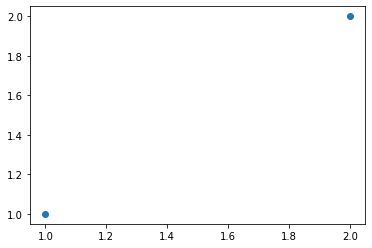

In [ ]:
fig = plt.figure()   # Создание объекта Figure
print (fig.axes)   # Список текущих областей рисования пуст
print (type(fig))   # тип объекта Figure
plt.scatter([1.0, 2.0], [1, 2])   # scatter - метод для нанесения маркера в точке (1.0, 1.0)

# После нанесения графического элемента в виде маркера
# список текущих областей состоит из одной области
print(fig.axes)

# смотри самую первую ячейку
save(name='pic_1_4_1', fmt='pdf')
save(name='pic_1_4_1', fmt='png')

plt.show()

Обычно рисунок в matplotlib представляет собой прямоугольную область, заданную в относительных координатах: от 0 до 1 включительно по обеим осям. Второй распространённый вариант типа рисунка - круглая область (polar plot).

Чтобы сохранить получившийся рисунок нужно воспользоваться методом `plt.savefig()`. Он сохраняет текущую конфигурацию текущего рисунка в графический файл с некоторым расширением (png, jpeg, pdf и др.), который можно задать через параметр fmt. Поэтому её нужно вызывать в конце исходного кода, после всех вызова всех других команд. Если в python-скрипте создать несколько рисунков figure и попытаться сохранить их одной командой `plt.savefig()`, то будет сохранён последний рисунок figure.

<class 'matplotlib.axes._axes.Axes'>


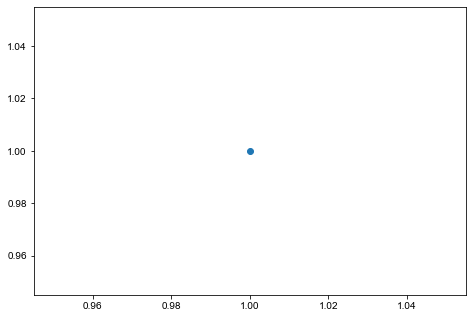

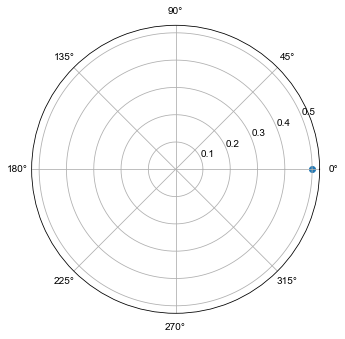

In [ ]:
#Различные по форме области рисования

fig = plt.figure()
# Добавление на рисунок прямоугольной (по умолчанию) области рисования
ax = fig.add_axes([0, 0, 1, 1])
print (type(ax))
plt.scatter(1.0, 1.0)


fig = plt.figure()
# Добавление на рисунок круговой области рисования
ax = fig.add_axes([0, 0, 1, 1], polar=True)
plt.scatter(0.0, 0.5)

# смотри преамбулу
save('pic_1_4_2', fmt='pdf')
save('pic_1_4_2', fmt='png')

plt.show()

### 1.5 Элементы рисунка Artists

Всё пространство рисунка Figure (прямоугольной или иной формы) можно использовать для нанесения других элементов рисунка, например, контейнеров Axes, графических примитивов в виде линий, фигур, текста и так далее. В любом случае каждый рисунок можно структурно представить следующим образом:

1. Область рисования Axes
    + Заголовок области рисования -> `plt.title()`;

2. Ось абсцисс Xaxis 
    + Подпись оси абсцисс OX -> `plt.xlabel()`;

3. Ось абсцисс Yaxis 
    + Подпись оси абсцисс OY -> `plt.ylabel()`;

4. Легенда -> `plt.legend()`

5. Цветовая шкала -> `plt.colorbar()`
    + Подпись горизонтальной оси абсцисс OY -> `cbar.ax.set_xlabel()`;
    
    + Подпись вертикальной оси абсцисс OY -> `cbar.ax.set_ylabel()`;

7. Деления на оси абсцисс OX -> `plt.xticks()`

8. Деления на оси ординат OY -> `plt.yticks()`

Для каждого из перечисленных уровней-контейнеров есть возможность нанести заголовок (title) или подпись (label). Подписи к рисунку облегчают понимание того, в каких единицах представлены данные на графике или диаграмме.

Также часто на рисунок наносятся линии вспомогательной сетки (grid). В pyplot она вызывается командой `plt.grid()`. Вспомогательная сетка связана с делениями координатных осей (ticks), которые определяются автоматически исходя из значений выборки. В дальнейшем будет показано как определять положение и задавать значения делений на координатных осях. Стоит сказать, что в matplotlib существуют главные деления (major ticks) и вспомогательные (minor ticks) для каждой координатной оси. По умолчанию рисуются только главные делений и связанные с ними линии сетки grid. В плане настройки главные деления ничем не отличаются от вспомогательных.

Если на рисунке присутствует так называемый "mappable object", то на рисунке может быть нарисована цветовая шкала (colorbar). К шкале также можно делать подписи вдоль разных сторон. При этом сама цветовая может быть расположена как на текущей области рисования axes, отбирая у неё некоторую долю, либо может быть размещена на самостоятельной области рисования. Подробнее о цветовой шкале Вы узнаете немного позже.

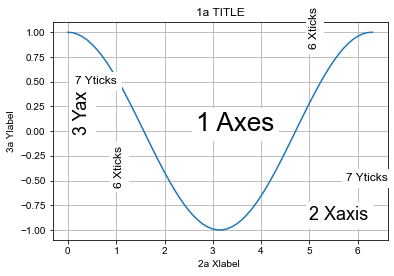

In [ ]:
# Элементы простого рисунка 

import matplotlib.pyplot as plt
import numpy as np

lag = 0.1
x = np.arange(0.0, 2*np.pi + lag, lag)
y = np.cos(x)

fig = plt.figure()
plt.plot(x, y)

plt.text(np.pi-0.5, 0,  '1 Axes', fontsize=26,
         bbox=dict(edgecolor='w', facecolor ='w'))
plt.text(0.1, 0, '3 Yaxis', fontsize=18,
         bbox=dict(edgecolor='w', facecolor ='w'), rotation=90)
plt.text(5, -0.9, '2 Xaxis', fontsize=18,
         bbox=dict(edgecolor='w', facecolor ='w'))

plt.title('1a TITLE')
plt.ylabel('3a Ylabel')
plt.xlabel('2a Xlabel ')

plt.text(5, 0.85, '6 Xticks', fontsize=12,
         bbox=dict(edgecolor='w', facecolor ='w'), rotation=90)
plt.text(0.95, -0.55, '6 Xticks', fontsize=12,
         bbox=dict(edgecolor='w', facecolor ='w'), rotation=90)

plt.text(5.75, -0.5, '7 Yticks', fontsize=12,
         bbox=dict(edgecolor='w', facecolor ='w'))
plt.text(0.15, 0.475, '7 Yticks', fontsize=12,
         bbox=dict(edgecolor='w', facecolor ='w'))

plt.grid(True)

# смотри преамбулу
save('pic_1_5_1', fmt='pdf')
save('pic_1_5_1', fmt='png')

plt.show()

findfont: Font family ['fantasy'] not found. Falling back to DejaVu Sans.
findfont: Font family ['fantasy'] not found. Falling back to DejaVu Sans.
findfont: Font family ['fantasy'] not found. Falling back to DejaVu Sans.
findfont: Font family ['fantasy'] not found. Falling back to DejaVu Sans.
findfont: Font family ['fantasy'] not found. Falling back to DejaVu Sans.
findfont: Font family ['fantasy'] not found. Falling back to DejaVu Sans.


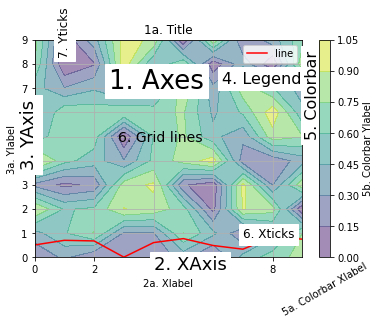

In [5]:
# Элементы более сложного рисунка

import matplotlib.pyplot as plt
import numpy as np

N = 100
n = int(np.sqrt(N))
x = np.arange(n)
# Задаём выборку из Гамма-распредления с параметрами формы=1. и масштаба=0.
z = np.random.random(N).reshape(n, n)
y = z[5,:]

fig = plt.figure()
cc = plt.contourf(z, alpha=0.5)   # трёхмерное поле
plt.plot(x, y, label='line', color='red') # красная линия

plt.title('1a. Title')   # заголовок
plt.xlabel('2a. Xlabel')   # подпись оси OX
plt.ylabel('3a. Ylabel')   # подпись оси OY
plt.legend()   # легенда
cbar = plt.colorbar(cc)   # цветовая шкала

plt.text(2.5, 7, '1. Axes',
         fontsize=26, bbox=dict(edgecolor='w', facecolor ='w'))
plt.text(4, -0.5, '2. XAxis',
         fontsize=18, bbox=dict(edgecolor='w', facecolor ='w'))
plt.text(-0.5, 3.8, '3. YAxis',
         fontsize=18, bbox=dict(edgecolor='w', facecolor ='w'), rotation=90)
plt.text(6.3, 7.2, '4. Legend',
         fontsize=16, bbox=dict(edgecolor='w', facecolor ='w'))
plt.text(9.1, 5., '5. Colorbar',
         fontsize=16, bbox=dict(edgecolor='w', facecolor ='w'), rotation=90)
plt.text(7., 0.8, '6. Xticks',
         fontsize=12, bbox=dict(edgecolor='w', facecolor ='w'))
plt.text(0.8, 8.4, '7. Yticks',
         fontsize=12, bbox=dict(edgecolor='w', facecolor ='w'), rotation=90)

# Подписи для цветовых шкал имеют отличный от остальных подписей синтаксис
cbar.ax.set_xlabel('5a. Colorbar Xlabel', color ='k', rotation=30)
cbar.ax.set_ylabel('5b. Colorbar Ylabel', color ='k')

plt.text(2.8, 4.8,'6. Grid lines', fontsize=14)
plt.grid(True)

# смотри преамбулу
save('pic_1_5_2', fmt='pdf')
save('pic_1_5_2', fmt='png')

plt.show()

### 1.6 Свойства графических элементов
 
Многообразие и удобство создания графики в matplotlib обеспечивается не только за счёт созданных графических команд, но и за счёт богатого арсенала по конфигурации типовых форм. Эта настройка включает в себя работу с цветом, формой, типом линии или маркера, толщиной линий, степенью прозрачности элементов, размером и типом шрифта и другими свойствами.

Параметры, которые определяют эти свойства в различных графических командах, обычно имеют одинаковый синтаксис, то есть называются одинаково. Стандартным способом задания свойств какого либо создаваемого объекта (или методу) является передача по ключу: ключ=значение. Наиболее часто встречаемые названия параметров изменения свойств графических объектов перечислены ниже:

+ *color/colors/c* - цвет;

+ *linewidth/linewidths* - толщина линии;

+ *linestyle* - тип линии;

+ *alpha* - степень прозрачности (от полностью прозрачного 0 до непрозрачного 1);

+ *fontsize* - размер шрифта;

+ *marker* - тип маркера;

+ *s* - размер маркера в методе plt.scatter(только цифры);

+ *rotation* - поворот строки на X градусов.

При создании функций или методов классов, особенно в случае наследования (см. Приложение 1), параметры часто передают в виде объединений последовательностей: кортежа или словаря. Для этого существуют специальные символы-приставки: "\*" или "\**" соответственно. Это особенно полезно в случаях, когда функция/метод может принимать переменное число параметров.

Принято, что для передачи кортежа используется переменная **args**, а в случае со словарём - **kwargs**. Если перед переменной args указан символ "\*", то все дополнительные аргументы, переданные функции/методу, сохранятся в
args в виде кортежа. Если перед args будет указан символ "\**", то все дополнительные параметры будут рассматриваться как пары "ключ - значение" в словаре.

В функциях/методах описывающие свойства таких графических объектов как линия, текст, прямоугольник, параметры часто объединяют в виде последовательностей \*args, либо словарей \*\*kwargs. Так удобнее при создании классов и их методов (смотри пример 1.6.1). 

Если в описании графического метода указано примерно так, как в,

> plt.plot(\*args, \*\*kwargs)

то это значит, что в качестве входных данных требуется сначала список/кортеж параметров(чаще всего нужна хотя бы одна последовательность типа значений функции Y), а после этого можно передавать значения параметров по ключевым именам этих параметров (color, linewidth и т.д.).

Словарь kwargs ДО вызова метода pop:
 {'solo': 1, 'wookie': 'green', 'friend': True}
Словарь kwargs ПОСЛЕ вызова метода pop:
 {'friend': True}
res1 <class 'list'> [45, 8.142545250971258, -416.25]
res2 <class 'str'> 1 loves green


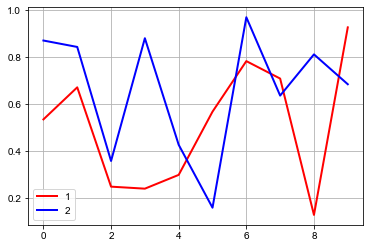

In [ ]:
# Пример функции с объединением в кортеж *args
def f_sums(*args):

    list1 = []
    for arg in args:
        a = 0
        for i in arg:
            a += i
        list1.append(a)

    return list1

# Пример функции с объединением в словарь **kwargs
def f_words(**kwargs):
    '''
    Функция pop возвращает значение для заданного ключа (если он есть в словаре)
    и удаляет из словаря пару "ключ - значение"
    '''
    
    print('Словарь kwargs ДО вызова метода pop:\n', kwargs)    
    per1 = kwargs.pop('solo', 'Han')
    per2 = kwargs.pop('wookie', 'Chubbaca')
    act = kwargs.pop('loves', 'loves')
    str1 = '%s %s %s' % (per1, act, per2)
    print('Словарь kwargs ПОСЛЕ вызова метода pop:\n', kwargs)
    
    return str1

# Пример функции с объединением и в кортеж args и в словарь **kwargs
def f_plot(*args, **kwargs):

    xlist = []
    ylist = []
    for i, arg in enumerate(args):
        if(i % 2 == 0):
            xlist.append(arg)
        else:
            ylist.append(arg) 
    
    colors = kwargs.pop('colors', 'k')
    linewidth = kwargs.pop('linewidth', 1.)
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    i = 0
    for x, y, color in zip(xlist, ylist, colors):
        i += 1
        ax.plot(x, y, color=color, linewidth=linewidth, label=str(i))
    
    ax.grid(True)
    ax.legend()
    save('ex_1_6_1', fmt='pdf')
    save('ex_1_6_1', fmt='png')

# ==================================
# MAIN SCRIPT BODY

x = np.arange(10)
y = np.random.random(20)
z = np.linspace(-15, -7.5, 37)
xyz = [x, y, z]

abc = {'solo': 1, 'wookie': 'green', 'friend': True}

res1 = f_sums(*xyz)
res2 = f_words(**abc)

print ('res1', type(res1), res1)
print ('res2', type(res2), res2)

"""
Т.к. в plt.plot нет обязательных параметров, то переданные 
в эту функцию через запятую последовательности или массивы будут обработаны
Здесь пример передачи двух линий - две последовательности из пары OX-OY
(x, y2) и (x, y3). Им в соответствие представлена последовательность цветов
colors.
"""
colors = ['red', 'blue']
N = 10
x = np.arange(N)
y2 = np.random.random(N)
y3 = np.random.random(N)

f_plot(x, y2, x , y3, colors=colors, linewidth=2.)

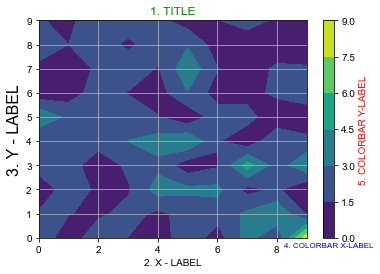

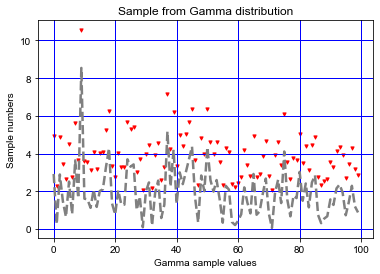

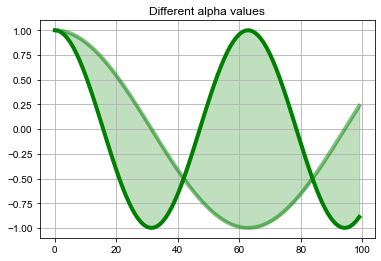

In [ ]:
# Свойства графических элементов

N = 100
x = np.arange(N)
# Задаём выборку из Гамма-распредления с параметрами формы=1. и масштаба=0.
z = np.random.gamma(2., 1., N)
z1 = np.cos(x/10.)
z2 = np.cos(x/20.)

y = z.reshape(10,10)
#y = np.cos(y)

fig = plt.figure()
cc = plt.contourf(y) 
cbar = plt.colorbar(cc)

plt.title('1. TITLE', color='green')
plt.xlabel('2. X - LABEL')
plt.ylabel('3. Y - LABEL', fontsize=16)

# Подписи для цветовых шкал имеют отличный от остальных подписей синтаксис
cbar.ax.set_xlabel('4. COLORBAR X-LABEL', color='b')
cbar.ax.set_ylabel('5. COLORBAR Y-LABEL', color='r')
plt.grid(True)

fig = plt.figure()

my_dict = {'color' : 'grey', 'linewidth' : 2.5, 'linestyle' : '--'}
xz = [x, z]

# передача параметров через список xz и словарь my_dict. Наличие знаков * и ** обязательно!
cc = plt.plot(*xz, **my_dict) 
# результат аналогичен такой записи
#cc = plt.plot(x, z, color='grey', linewidth=2.5, linestyle='--')

plt.scatter(x, y + 2.0, marker='v', s=10, color='red')

plt.title('Sample from Gamma distribution')
plt.xlabel('Gamma sample values')
plt.ylabel('Sample numbers')

# Подписи для цветовых шкал имеют отличный от остальных подписей синтаксис
cbar.ax.set_xlabel('4. COLORBAR X-LABEL', fontsize=8)
cbar.ax.set_ylabel('5. COLORBAR Y-LABEL', color='r')
plt.grid(True, color='blue', linewidth=1.0)

fig = plt.figure()

# создание словаря
my_dict = {'color' : 'green', 'linewidth' : 4.0, 'alpha' : 0.5} 

plt.fill_between(x, z2, z1, color='green', alpha=0.25) 
plt.plot(x, z1, color='green', linewidth=4.0)
plt.plot(x, z2, **my_dict)
plt.title('Different alpha values')
plt.grid(True)

save('pic_1_6_2', fmt='pdf')
save('pic_1_6_2', fmt='png')

plt.show()

## 2. Основные графические команды

Графические команды - это функции, которые, принимая некоторые параметры, возвращают какой-то графический результат. Это может быть текст, линия, график, диаграмма и др. В этой главе будут рассмотрены графические команды, которые создают графику высокого уровня: графики или диаграммы.

### 2.1 Графические команды

В Matplotlib заложены как простые графические команды, так и достаточно сложные. Доступ к ним через pyplot означает использование синтаксиса вида "`plt.название_команды()`".

Наиболее распространённые команды для создания научной графики в matplotlib это:

**I. Самые простые графические команды:**

+ `plt.scatter()` - маркер или точечное рисование;

+ `plt.plot()` - ломаная линия;

+ `plt.text()` - нанесение текста;

**II. Диаграммы:**

+ `plt.bar()`, `plt.barh()`, `plt.barbs()`, `broken_barh()` - столбчатая диаграмма;

+ `plt.hist()`, `plt.hist2d()`, `plt.hlines` - гистограмма;

+ `plt.pie()` - круговая диаграмма;

+ `plt.boxplot()` - "ящик с усами" (boxwhisker);

+ `plt.errorbar()` - оценка погрешности, "усы".

**III. Изображения в изолиниях:**

+ `plt.contour()`	- изолинии;

+ `plt.contourf()` - изолинии с послойной окраской;

**IV. Отображения:**

+ `plt.pcolor()`, `plt.pcolormesh()` - псевдоцветное изображение матрицы (2D массива);

+ `plt.imshow()` - вставка графики (пиксели + сглаживание);

+ `plt.matshow()` - отображение данных в виде квадратов.

**V. Заливка:**

+ `plt.fill()` - заливка многоугольника;

+ `plt.fill_between()`, `plt.fill_betweenx()` - заливка между двумя линиями;

**VI. Векторные диаграммы:**

+ `plt.streamplot()` - линии тока;

+ `plt.quiver()` - векторное поле.

[Полный список команд](http://matplotlib.org/api/pyplot_summary.html), доступный для pyplot, можно узнать на официальном сайте matplotlib. В списке нет команд для рисования различных геометрических фигур (круги, многоугольники и т.д.). Это связано с тем, что в matplotlib они вызываются через **matplotlib.patches**, который за них отвечает. Создание геометрически сложных фигур является достаточно специальной задачей, поэтому **matplotlib.patches** здесь не будут рассматриваться. 

Ознакомиться с примерами создания фигур с помощью matplotlib можно в электронных ресурсах к этой главе.

Ниже показаны примеры графики, которую matplotlib создаёт "по умолчанию" при вызове той или иной графической команды. В дальнейшем будет показано как задать ту или иную конфигурацию конкретного графика и как настроить сопутствующие рисунку элементы (подписи, линии вспомогательной сетки, шрифты и т.д.).

Scatter:  <class 'matplotlib.collections.PathCollection'>
Plot:  1 [<matplotlib.lines.Line2D object at 0x0000021FD56CCA08>]
Text:  <class 'matplotlib.text.Text'>


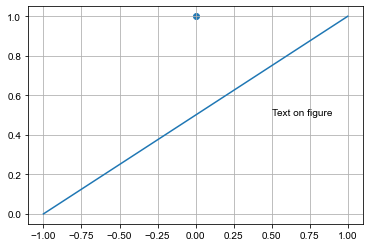

In [ ]:
fig = plt.figure()
# Добавление на рисунок прямоугольной (по умолчанию) области рисования
scatter1 = plt.scatter(0.0, 1.0)
print('Scatter: ', type(scatter1))

graph1 = plt.plot([-1.0, 1.0], [0.0, 1.0])
print('Plot: ', len(graph1), graph1)

text1 = plt.text(0.5, 0.5, 'Text on figure')
print('Text: ', type(text1))

grid1 = plt.grid(True)   # линии вспомогательной сетки

save(name='pic_2_1', fmt='pdf')
save(name='pic_2_1', fmt='png')

plt.show()

### 2.2 Диаграммы

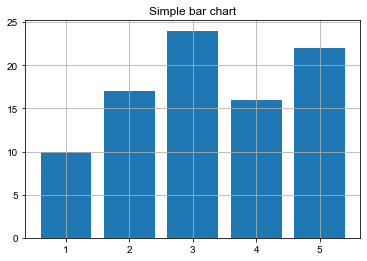

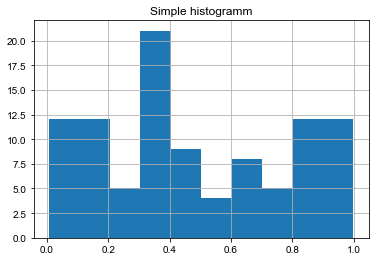

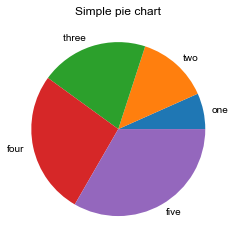

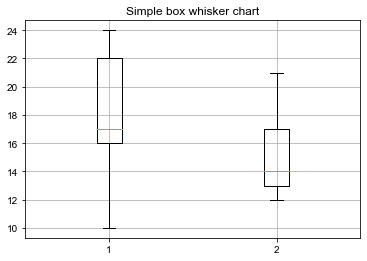

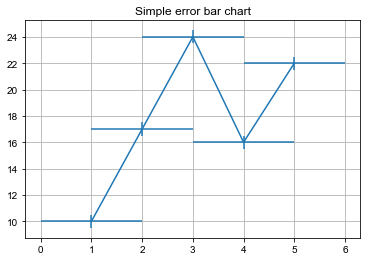

In [ ]:
s = ['one','two','three ','four' ,'five']
x = [1, 2, 3, 4, 5]
z = np.random.random(100)
z1 = [10, 17, 24, 16, 22]
z2 = [12, 14, 21, 13, 17]

# bar()
fig = plt.figure()
plt.bar(x, z1)
plt.title('Simple bar chart')
plt.grid(True)   # линии вспомогательной сетки

# hist()
fig = plt.figure()
plt.hist(z)
plt.title('Simple histogramm')
plt.grid(True)

# pie()
fig = plt.figure()
plt.pie(x, labels=s)
plt.title('Simple pie chart')

# boxplot()
fig = plt.figure()
plt.boxplot([z1, z2])
plt.title('Simple box whisker chart')
plt.grid(True)

# errorbar()
fig = plt.figure()
plt.errorbar(x, z1, xerr=1, yerr=0.5)
plt.title('Simple error bar chart')
plt.grid(True)

save(name='pic_2_2', fmt='pdf')
save(name='pic_2_2', fmt='png')

plt.show()

### 2.3 Методы изолиний

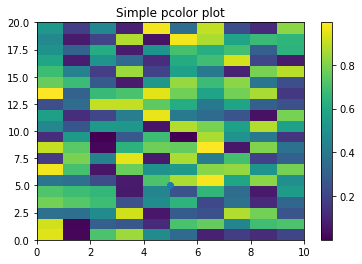

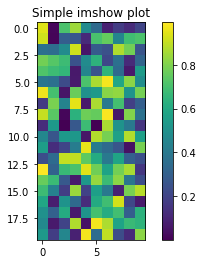

In [6]:
dat = np.random.random(200).reshape(20,10) # создаём матрицу значений

fig = plt.figure()
pc = plt.pcolor(dat) # метод псевдографики pcolor
plt.colorbar(pc)
plt.scatter([5], [5])
plt.title('Simple pcolor plot')

fig = plt.figure()
me = plt.imshow(dat) 
plt.colorbar(me)
plt.title('Simple imshow plot')

save(name='pic_2_3', fmt='pdf')
save(name='pic_2_3', fmt='png')

plt.show()

### 2.4 Методы отображений

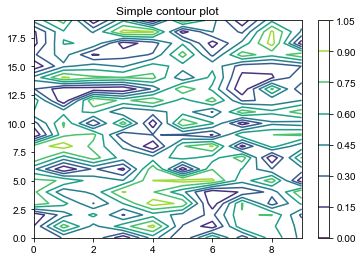

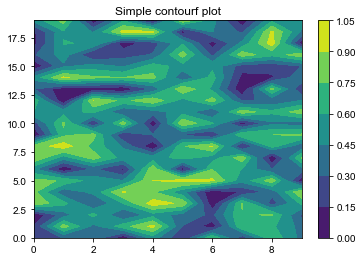

<Figure size 432x288 with 0 Axes>

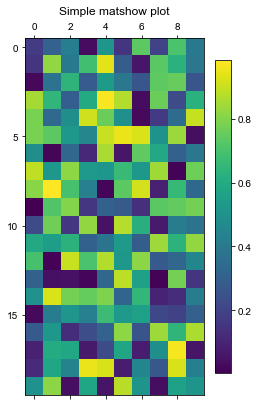

In [ ]:
dat = np.random.random(200).reshape(20,10) # создаём матрицу значений

fig = plt.figure()
cr = plt.contour(dat) 
plt.colorbar(cr)
plt.title('Simple contour plot')

fig = plt.figure()
cf = plt.contourf(dat) 
plt.colorbar(cf)
plt.title('Simple contourf plot')

fig = plt.figure()
cf = plt.matshow(dat) 
plt.colorbar(cf, shrink=0.7)
plt.title('Simple matshow plot')

save(name='pic_2_4', fmt='pdf')
save(name='pic_2_4', fmt='png')

plt.show()

### 2.5 Методы заливки

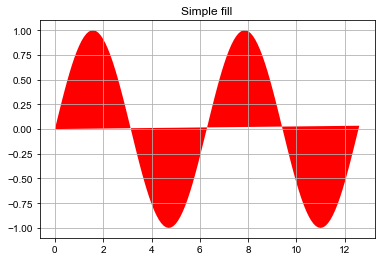

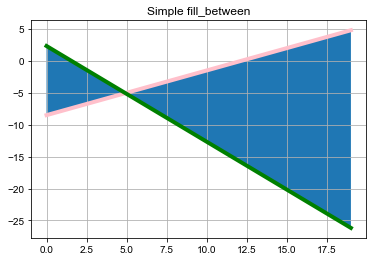

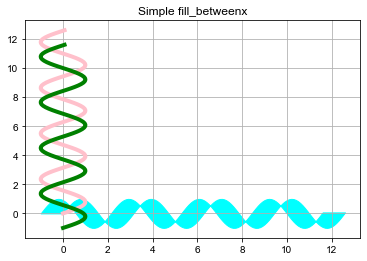

In [ ]:
x = np.arange(0, 4*np.pi+0.1, 0.1)
y = np.sin(x)
z = np.sin(2*x)

x2 = np.arange(20)
y2 = -1.5*x2 + 2.33
z2 = 0.7*x2 - 8.5 

# fill()
fig = plt.figure()
plt.fill(x, y, 'r') # метод псевдографики pcolor
plt.title('Simple fill')
plt.grid(True)

# fill_between()
fig = plt.figure()
plt.plot(x2, z2, color='pink', linewidth=4.0)
plt.plot(x2, y2, color='g', linewidth=4.0)
plt.fill_between(x2, y2, z2) 
plt.title('Simple fill_between')
plt.grid(True)

# fill_betweenx()
fig = plt.figure()
plt.plot(z, x, color='pink', linewidth=4.0)
plt.plot(z, x-1.0, color='g', linewidth=4.0)
plt.fill_betweenx(z, x, x-1.0, color='cyan')
plt.title('Simple fill_betweenx')
plt.grid(True)

save(name='pic_2_5', fmt='pdf')
save(name='pic_2_5', fmt='png')

plt.show()

### 2.6 Векторные диаграммы

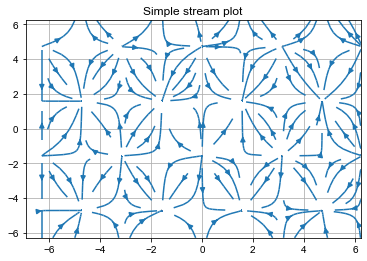

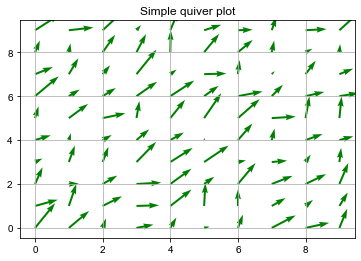

In [ ]:
x = np.arange(-2*np.pi, 2*np.pi, 0.1)
u = np.sin(x)*np.cos(x)
v = np.cos(x)
uu, vv = np.meshgrid(u,v)

N = 100
x1 = np.random.random(N).reshape((10, 10))
y1 = np.random.random(N).reshape((10, 10))

# streamplot()
fig = plt.figure()
plt.streamplot(x, x, uu, vv) 
plt.title('Simple stream plot')
plt.grid(True)

# quiver()
fig = plt.figure()
plt.quiver(x1, y1, color='green') 
plt.title('Simple quiver plot')
plt.grid(True)

save(name='pic_2_6', fmt='pdf')
save(name='pic_2_6', fmt='png')

plt.show()

## 3. Текст и шрифты

Текст является одним из базовых графических элементов рисунка в matplotlib. Подписи координатных осей и их делений, заголовки, пояснительные подписи на графиках и диаграммах - это всё текст. В Matplotlib возможна поддержка кириллицы для создания научной графики с подписями на русском языке.

### 3.1 Файл настройки `matplotlibrc`

В matplotlib существует файл настройки в котором хранятся значения по умолчанию для разных свойств графических элементов. Он называется `matplotlibrc`. Он инициализируется при каждой загрузке модуля matplotlib. Изменив содержание файла `matplotlibrc` можно сохранить пользовательские настройки для работы при следующих загрузках модуля matplotlib. Чтобы узнать какой именно файл настройки используется при инициализации, можно воспользоваться специальной функцией `matplotlib.matplotlib_fname()`.

Для работы с настройками в интерактивном режиме, то есть из консоли или в скрипте, существует `matplotlib.rcParams`. C помощью `matplotlib.rcParams` можно, во-первых, установить все параметры рисования (шрифты, толшина/тип линий, оформление рамок) на необходимые значения, а во-вторых, увидеть, собственно, список настроек, то есть список того, что можно изменить.

In [ ]:
import matplotlib as mpl

print(mpl.matplotlib_fname()) # показывает откуда был загружен текуший файл matplotlibrc

# показывает текущие настройки
# print(mpl.rcParams)

# показывает значения параметров,
# которые хранятся в файле matplotlibrc
# print(mpl.rcParamsDefault) 

# сбрасывает значения на те,
# которые хранятся в файле matplotlibrc
# mpl.rcdefaults()

C:\Users\Zexte\AppData\Roaming\Python\Python37\site-packages\matplotlib\mpl-data\matplotlibrc


### 3.2 Текст на рисунке

Одними из самых базовых графических команд являются команды, отображающие текст. Самой простой такой командой, не привязаной к какому-либо объекту вроде координатной оси или делений координатной оси, является команда `plt.text()`. 

В качестве входящих данных она принимает координаты положения будующей строки и сам текст в виде строки. По умолчанию координаты положения строки будут приурочены к области изменения данных. Можно задать положение текста в относительных координатах (см. пример ниже), когда вся область рисования изменяется по обеим координатным осям от 0 до 1 включительно. Таким образом, координата (0.5, 0.5) в относительных координатах означает центр области рисования. Текст можно выровнять с помощью параметров horizontalalignment и verticalalignment, а также заключать его в рамку с цветным фоном, передав параметр bbox. Bbox - это словарь, работающий со свойствами прямоугольника, то есть объектом Rectangle.

Помимо метода text() существуют и другие методы отображения текста в pyplot. Ниже представлен список текстовых команд в pyplot, в квадратных скобках указан альтернативный синтаксис вызова аналогичных команд в ООП стиле. Подробнее об ООП стиле будет рассказано позже.

+ `plt.xlabel()` - добавляет подпись оси абсции OX `[matplotlib.axes.Axes.set_xlabel()]`;

+ `plt.ylabel()` - добавляет подпись оси ординат OY `[matplotlib.axes.Axes.set_ylabel()]`;

+ `plt.title()` - добавляет заголовок для области рисования Axes `[matplotlib.axes.Axes.set_title()]`;

+ `plt.figtext()` - добавляет текст на рисунок Figure `[matplotlib.figure.Figure.text()]`;

+ `plt.suptitle()` - добавляет заголовок для рисунка Figure `[matplotlib.figure.Figure.suptitle()]`;

+ `plt.annotate()` - добавляет примечание, которое состоит из текста и необязательной стрелки в указанную область на рисунке `[matplotlib.axes.Axes.annotate()]`

Каждый текст на рисунке - это экземпляр либо исходного класса, либо дочернего класса для `matplotlib.text.Text`.

Text class: <class 'matplotlib.text.Text'>


C:\Anaconda3\lib\site-packages\ipykernel_launcher.py:22: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


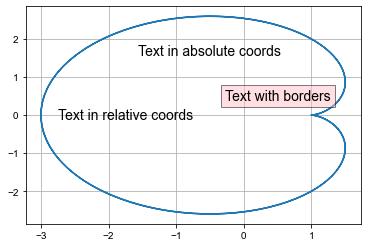

In [ ]:
a = 1.
x = np.arange(-2*np.pi, 2*np.pi, 0.05)
# Уравнение кардиоиды
xz = a*(2*np.cos(x) - np.cos(2*x))
yz = a*(2*np.sin(x) - np.sin(2*x))

fig = plt.figure()
plt.plot(xz, yz)

# Текст в координатах данных
str1 = plt.text(-np.pi/2., np.pi/2., 'Text in absolute coords', fontsize=14)  
# выравнивание по левому краю
print('Text class: %s' % str1.__class__)

# Текст в рамке
plt.text(0.5, 0.5, 'Text with borders', fontsize=14,
         # выравнивание по вертикали и по горизонтали по центру
         horizontalalignment='center', verticalalignment='center',
         bbox=dict(facecolor='pink', alpha=0.5))

# Текст в относительных координатах области рисования ax
ax2 = fig.add_subplot()   # создаём область рисования ax
plt.text(0.5, 0.5, 'Text in relative coords', fontsize=14,
         horizontalalignment='right', verticalalignment='center',
         transform=ax2.transAxes)
plt.grid()

save('pic_3_2', fmt='png')
save('pic_3_2', fmt='pdf')

plt.show()

### 3.3 Наборы шрифтов. Стили и форматы

Из настроек `matplotlibrc` или `rcParams` нас интересуют fonts, то есть шрифты. Есть 5 наборов шрифтов: 

+ cursive;

+ fantasy;

+ monospace;

+ sans-serif;

+ serif. 

Один из этих пяти наборов является текущим. За это отвечает параметр font.family. Каждый набор может состоять из одного или более шрифтов. Причём можно указывать шрифты, которые не установлены в ОС. Работать такие шрифты не будут, но формально указать их можно. Такая настройка определяет шрифт для всех подписей и текста на рисунке. Если конкретную подпись необходимо сделать другим шрифтом, можно указать шрифт из текущего стиля прямо в команде, передав в качестве соответствующего параметра словарь: `{'fontname':'название_шрифта'}`.

Помимо семейств, текст также может иметь стиль. Атрибут стиля style может быть либо 'italic', либо 'oblique', либо 'normal' (по умолчанию). Толщина или "жирность" шрифта, может быть задана через атрибут fontweight, который принимает значения 'bold', 'light' или 'normal' (по умолчанию). Стили и форматы можно комбинировать.

cfam fantasy
['Arial', 'Times New Roman', 'Tahoma', 'Comic Sans MS', 'Courier']


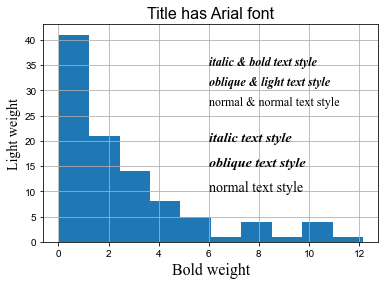

In [ ]:
mpl.rcParams['font.fantasy'] = 'Arial', 'Times New Roman', 'Tahoma', 'Comic Sans MS', 'Courier'
mpl.rcParams['font.family'] = 'fantasy'

# Текущий стиль-семейство шрифтов
cfam = mpl.rcParams.get('font.family')[0]
print('cfam %s' % cfam)
cfont = mpl.rcParams.get('font.fantasy')[0]

# Первый шрифт в текущем семействе
print(mpl.rcParams.get('font.%s' % cfam))


N = 100
x = np.arange(N)
# Задаём выборку из Гамма-распредления с параметрами формы=1. и масштаба=3.0
y = np.random.gamma(1.0, 3.0, N)

fig = plt.figure()
cc = plt.hist(y) 

text_style = ['italic', 'oblique', 'normal']
font_weights = ['bold', 'light', 'normal']
for i, ts in enumerate(text_style):
    plt.text(6, 20-5*i, '%s text style' % ts, {'fontname':'Times New Roman'}, style=ts, fontsize=14)
    plt.text(6, 35-4*i, '%s & %s text style' % (ts, font_weights[i]), {'fontname':'Times New Roman'}, 
             style=ts, fontweight=font_weights[i], fontsize=12)
    
plt.title('Title has %s font' % cfont, fontweight='normal', color='k', fontsize=16)
plt.xlabel('Bold weight', {'fontname':'Times New Roman'}, fontweight='bold', fontsize=16)
plt.ylabel('Light weight', {'fontname':'Times New Roman'}, fontweight='light', fontsize=14)
plt.grid(True)

save('pic_3_3', fmt='png')
save('pic_3_3', fmt='pdf')

plt.show()

### 3.4 Кириллица и matplotlib. Подписи по-русски

Кириллица "из коробки" не поддерживается в matplotlib. Однако настроить поддержку русского алфавита несложно. Основная проблема matplotlib для отображения кириллических символов состоит в том, что по умолчанию используются шрифты, которые не поддерживают кириллицу. Соответственно, решение проблемы отображения русского алфавита заключается в смене шрифта на тот, который поддерживает кириллицу. В ОС Windows это может быть, например, Arial, Times New Roman или Tahoma. Сделать это можно как в теле самой программы-скрипта, так и в профильных настройках.

У каждого стиля шрифта определены списки из реальных шрифтов, которыми пользуются в текстовых процессорах и редакторах. Чтобы поставить шрифт, который будет корректно отображать кириллицу, можно воспользоваться таким примером:

In [ ]:
mpl.rcParams['font.family'] = 'fantasy'
mpl.rcParams['font.fantasy'] = 'Arial', 'Times New Roman', 'Tahoma'

Таким образом, набор fantasy будет основным, и из него будет использован шрифт Arial. Если он не будет найден, то будет выбран второй по списку и так далее. Оба представленных шрифта корректно отображают кирилличекие символы.

Можно использовать и такой синтаксис:

Courier New
Arial


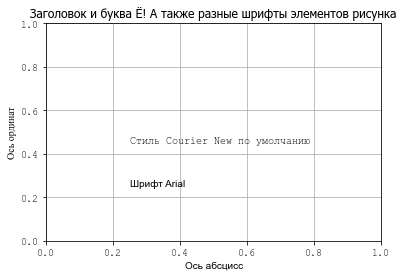

In [ ]:
font = {'family': 'Courier New',
        'weight': 'normal'}
rc('font', **font)

cfam = mpl.rcParams.get('font.family')[0]
print(cfam)
cfont = mpl.rcParams.get('font.fantasy')[0]
print(cfont)

plt.text(0.25, 0.45, u'Стиль %s по умолчанию' % cfam)
plt.text(0.25, 0.25, u'Шрифт Arial', {'fontname':'Arial'})

plt.xlabel(u'Ось абсцисс', {'fontname':'Arial'})
plt.ylabel(u'Ось ординат', {'fontname':'Times New Roman'})
plt.title(u'Заголовок и буква Ё! А также разные шрифты элементов рисунка',{'fontname':'Tahoma'})
plt.grid()

save('pic_3_4_1', fmt='png')
save('pic_3_4_1', fmt='pdf')

plt.show()

Список доступных в ОС шрифтов можно узнать, например, вот так:

In [ ]:
for i, font in enumerate(sorted(fm.findSystemFonts())):
    # Шрифтов в системе очень много. Полный список занимает не одну страницу A4
    if(i % 50 == 0):
        print(i, font)

0 C:\Program Files\AMD\RyzenMaster\bin\QtQuick\Dialogs\qml\icons.ttf
50 C:\Users\Zexte\AppData\Local\Microsoft\Windows\Fonts\SFCompactText-Regular.ttf
100 C:\Windows\Fonts\REFSAN.TTF
150 C:\Windows\Fonts\couri.ttf
200 C:\Windows\Fonts\segoeuii.ttf


Для поиска по названию известного вам шрифта в ОС можно воспользоваться функцией findfont:

In [ ]:
print('Courier New - %s' % fm.findfont('Courier New')) # Ищем Courier New
print('Times New Roman - %s' % fm.findfont('times new roman')) # Ищем times new roman строчными буквами
print('Comic Sans MS - %s' % fm.findfont('COMIC SANS MS')) # Ищем COMIC SANS MS прописными буквами

Courier New - C:\Windows\Fonts\cour.ttf
Times New Roman - C:\Windows\Fonts\times.ttf
Comic Sans MS - C:\Windows\Fonts\comic.ttf


**Вторым необходимым условием** для отображения на рисунках matplotlib русских букв является использование unicode-строк. В python3 все строки являются юникодовыми, там дополнительных примочек не нужно. В python2 необходимо преобразовывать обычную строку в юникод-строку: 

In [ ]:
str1 = 'строка 1' # обычная строка
print(str1,type(str1))
str2 = u'строка 1' # unicode-строка
print(str2,type(str2))

строка 1 <class 'str'>
строка 1 <class 'str'>


Также ставим в начале скрипта: # -*- coding: utf-8 -*- . В GUI Spyder такая запись вставляется в новый созданный скрипт по умолчанию.

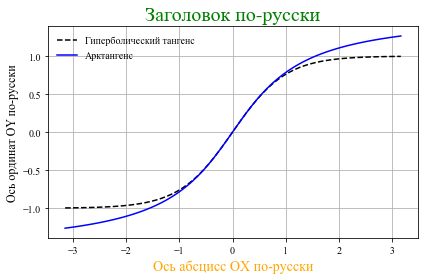

In [ ]:
# -*- coding: utf-8 -*-

#mpl.rcdefaults() # cбрасываем настройки на "по умолчанию"
mpl.rcParams['font.family'] = 'fantasy'
mpl.rcParams['font.fantasy'] = 'Times New Roman', 'Ubuntu','Arial','Tahoma','Calibri'

x = np.arange(-np.pi, np.pi+0.1, 0.1)

fig = plt.figure()
ax1 = fig.add_subplot(111)
y = np.tanh(x)
y2 = np.arctan(x)
ax1.plot(x,y,'k--',label=u'Гиперболический тангенс')
ax1.plot(x,y2,'b',label=u'Арктангенс')

st = u'Заголовок по-русски'
sy = u'Ось ординат OY по-русски'
sx = u'Ось абсцисс OX по-русски'

ax1.set_title(st,size=20,color='green')
ax1.set_xlabel(sx,size=14,color='orange')
ax1.set_ylabel(sy,size=12, color='black')
ax1.grid(True)
ax1.legend(loc='best',frameon=False)

plt.tight_layout() # автоматическое выравнивание элементов на холсте plt

save('pic_3_4_2', fmt='png')
save('pic_3_4_2', fmt='pdf')

plt.show()

## 4. Цвета и цветовая палитра

Цвет является одним из важнейших выразительных средств художника (а все мы являемся художниками, когда создаём рисунки). Чёрно-белая графика имеет свои эстетические достоинства и практическую выгоду (экономия краски при печати), но в ряде случаев без использования цвета не обойтись.

Цвет может быть задан либо через пропорции трёх базовых цветов: красного, зелёного и синего. Такой способ носит название RGB. Другим стандартным методом является использование шестнадцатиричной кодировки (HEX), которая широко применяется в HTML. В не зависимости от способа задания цвета нужно понимать, какой цвет получается при той или иной комбинации. В этом могут помочь специальные редакторы, ссылки на которые расположены ниже.

Многообразие сочетаний цветов порождает массу наборов цветов - цветовые палитры. Они нужны в качестве основы для отображения цветовых легенд или цветовых шкал, где каждому оттенку цвета шкалы сопоставляется какое-то значение. Также цветовые шкалы применяются там, где нужно динамически подбирать цвет, например, при создании цветных графиков временных рядов нескольких величин.

### 4.1 Цвет как декортивный элемент

Цвет - это один из самых распространённых способ отобразить информацию. Во многом презентабельность и читаемость рисунка зависит от подобранных цветов. В научной графике, как правило, уделяется достаточно мало внимания подборке сочетания цветов, важна однозначность идентификации по цвету.

Matplotlib предоставляет широкие возможности для работы с цветом. Существует ряд предустановленных цветов, которые имеют следующие аббревиатуры:

+ **Красный** - 'red', 'r', (1.0, 0.0, 0.0);

+ **Оранженвый** - 'orange';

+ **Жёлтый** - 'yellow', 'y', (0.75, 0.75, 0);

+ **Зелёный** - 'green', 'g', (0.0, 0.5, 0.0);

+ **Голубой** - 'cyan', 'c', (0.0, 0.75, 0.75);

+ **Синий** - 'blue', 'b', (0.0, 0.0, 1.0);

+ **Фиолетовый** - 'magenta', 'm', (0.75, 0, 0.75);

+ **Чёрный** - 'black', 'k', (0.0, 0.0, 0.0);

+ **Белый** -'white', 'w', (1.0, 1.0, 1.0).

Цветовую гамму можно разнообразить за счёт различной степени прозрачности параметра alpha. Но если нужно задать конкретно, скажем, алый цвет, то нужна пользовательская настройка. Matplotlib отображает цвет, заданный как в формате RGB, так и в HEX. Существуют [различные таблицы цветов](https://www.artlebedev.ru/tools/colors/), в которых представленным оттенкам соответствует код в RGB или HEX формате. Ими удобно пользоваться при составлении небольших пользовательских цветовых палитр.

### 4.2 Способы задания цветов. RGB и HEX

[Цвет в формате RGB](https://ru.wikipedia.org/wiki/RGB) представляет собой триплет или кортеж, состоящий из трёх целых значений от 0 до 255 для красного, зелёного и синего цветов. Различные сочетания этих трёх значений позволяет получить огромное количество оттенков и цветов.

В matplotlib цвета rgb значения задаются в относительных единицах, в диапазоне от [0, 1]. Если необходимый цвет задан в диапазоне [0, 255], то нужно просто поделить их на 255.

Цвет, представленный в формате HEX, передаётся в виде шестнадцатеричной html строки (символ # перед шестизначным значением обязателен).

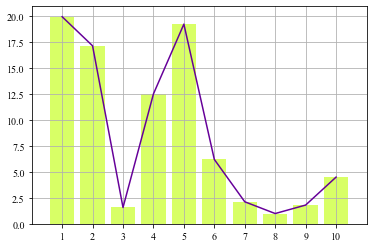

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)   # добавление области рисования ax

N = 10
x = np.arange(1, N+1, 1)
y = 20.*np.random.rand(N)

rgb = np.array([204,255,51])/255.
myhex = '#660099'

ax.plot(x, y, color=myhex)
ax.bar(x, y, color=rgb, alpha=0.75, align='center')

ax.set_xticks(x)   # установка делений на оси OX
ax.set_xlim(np.min(x)-1, np.max(x)+1)   # ограничение области изменения по оси OX
ax.grid(True)

save('pic_4_2', fmt='png')
save('pic_4_2', fmt='pdf')

plt.show()

### 4.3 Цветовая палитра colormap

Последовательность или набор цветов образует цветовую палитру colormap. Чаще всего она используется при отрисовке трёхмерных данных. Но и автоматический подбор цветов при добавлении каждого нового экземпляра plot также осуществляется из цветовой палитры по умолчанию.

Для получения текущей цветовой палитры можно воспользоваться методом `plt.get_cmap('название палитры')`. Список всех предустановленных палитр можно получить с помощью метода plt.cm.datad. В настройках matplotlibrc можно также изменить цветовую палитру с помощью параметра `image.cmap`. В интерактивном режиме её можно поменять через `plt.rcParams['image.cmap']='имя_палитры'` или через `plt.set_cmap('имя_палитры')`. Последний позволяет изменить палитру текущего рисунка уже после вызова графических команд.

Предустановленные цветовые палитры: ['Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c']


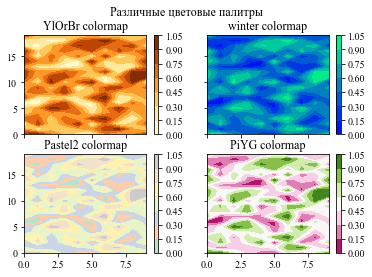

In [ ]:
dat = np.random.random(200).reshape(20,10) # создаём матрицу значений

# Создаём список цветовых палитр из словаря
maps = [m for m in plt.cm.datad]
# или так
maps = []

for i, m in enumerate(plt.cm.datad):
    maps.append(m)
#    print('%d - %s' % (i, m))

print(u'Предустановленные цветовые палитры:', maps)

fig, axes= plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True)

cmaplist = plt.cm.datad

for ax in fig.axes:
    random_cmap = np.random.choice(maps)
    cf = ax.contourf(dat, cmap=plt.get_cmap(random_cmap))
    ax.set_title('%s colormap' % random_cmap)
    fig.colorbar(cf, ax=ax)
    
plt.suptitle(u'Различные цветовые палитры')   # единый заголовок рисунка

save('pic_4_3', fmt='png')
save('pic_4_3', fmt='pdf')

plt.show()

Всё многообразие цветовых палитр можно разбить на два типа:

+ плавная палитра LinearSegmentedColormap 

+ дискретная палитра ListedColormap. 

Первая используется для создания всех встроенных экземпляров colormap, а также очень полезна при создании пользовательских цветовых шкал. Вторая используется для создания пользовательской цветовой палитры colormap из заданного списка цветов.

### 4.4 Плавная цветовая палитра

Плавная цветовая палитра представляет собой результат линейной интерполяции между последовательностью цветов, составляющих основу палитры. 

Различные методы отображения трёхмерных данных (разные графические команды) по умолчанию используют разные типы цветовых палитр. Так методы `plt.imshow()` и `plt.pcolor()` будут сопровождаться плавной цветовой палитрой:

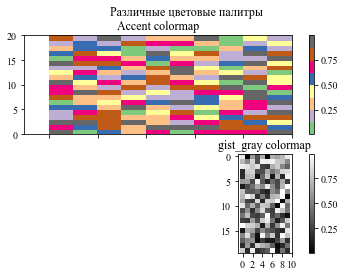

In [ ]:
dat = np.random.random(200).reshape(20,10) # создаём матрицу значений

# Создаём список цветовых палитр из словаря
maps = [m for m in plt.cm.datad]
# или так
maps = []
for m in plt.cm.datad:
    maps.append(m)

fig, axes= plt.subplots(nrows=2, ncols=1, sharex=True) 

cmaplist = plt.cm.datad

for i, ax in enumerate(fig.axes):
    random_cmap = np.random.choice(maps)
    if(i == 0):
        cf = ax.pcolor(dat, cmap=plt.get_cmap(random_cmap))
    else:
        cf = ax.imshow(dat, cmap=plt.get_cmap(random_cmap))        

    ax.set_title('%s colormap' % random_cmap)
    
    fig.colorbar(cf, ax=ax)

plt.suptitle(u'Различные цветовые палитры')

save('pic_5_4_1', fmt='png')
save('pic_5_4_1', fmt='pdf')

plt.show()

Чтобы создать пользовательскую плавную цветовую палитру нужно, во-первых, определиться с её основными цветами. Пусть мы выбрали следующее сочетание цветов: розовый, синий, зелёный, оранжевый и красный. В представлении RGB это означает спискок следующих значений:

+ розовый - rgb(150, 0, 0), ;

+ синий - rgb(0, 0, 255),

+ зелёный - rgb(0, 255, 0),

+ оранжевый - rgb(255, 150, 0),

+ красный - rgb(255, 0, 0),

Matplotlib работает с rgb в относительных единицах, поэтому классические значения rgb триплетов нужно поделить на 255.

После этого нужно создать "словарь палитры" cdict. Это словарь для каждого из оттенков RGB ('red', 'blue', 'green'), где каждому оттенку приписан список или кортеж (x, y0, y1):

+ x - определяет положение в палитре в диапазоне [0,1]. Проще представить будущую палитру в виде шкалы от 0 до 1;

+ y0 - значение цвета в относительных единицах ([0, 255] -> [0, 1]) с одной стороны (слева) от положения x;

+ y1 - значение цвета ([0, 255] -> [0, 1]) с другой стороны (справа) от положения x.

Между заданными позициями x метод LinearSegmentedColormap линейно интерполирует значения цветов между (x_i - y1_i) и (x_i+1 - y0_i). Обычно y0 и y1 совпадают, но, используя разные значения, можно добиваться более сложых эффектов, например разрывов в палитре. 

[127.5   0.   25.5]


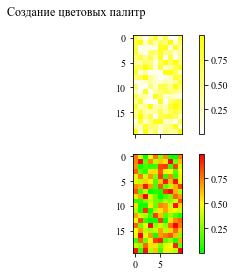

In [ ]:
dat = np.random.random(200).reshape(20,10) # создаём матрицу значений

xx = np.array([0.5, 0.0, 0.1])*255
print(xx)
# Создаём список цветовых палитр из словаря

# ---------------------------------------------------------
# Вариант 1 Ромашка (бело-жёлтый)

cdict1 = {'red':   ((0.0, 1.0, 1.0),
                   (1.0, 1.0, 1.0)),

         'green': ((0.0, 1.0, 1.0),
                   (1.0, 1.0, 1.0)),

         'blue':  ((0.0, 1.0, 1.0),
                   (1.0, 0.0, 0.0))
        }

cmap1 = mpl.colors.LinearSegmentedColormap('cmap1', cdict1)


# Вариант 2 Светофор(красный-жёлтый-зелёный)

cdict2 = {'red':   ((0.0, 0.0, 0.0),
                   (0.5, 1.0, 1.0),
                   (1.0, 1.0, 1.0)),

         'green': ((0.0, 1.0, 1.0),
                   (0.5, 1.0, 1.0),
                   (1.0, 0.0, 0.0)),

         'blue':  ((0.0, 0.0, 0.0),
                   (0.5, 0.0, 0.0),
                   (1.0, 0.0, 0.0))
        }

cmap2 = mpl.colors.LinearSegmentedColormap('cmap2', cdict2)
# ---------------------------------------------------------

fig, axes= plt.subplots(nrows=2, ncols=1, sharex=True)

cmaplist = plt.cm.datad

cmaps = [cmap1, cmap2]

for i, ax in enumerate(fig.axes):
    cf = ax.imshow(dat, cmap=cmaps[i])        
    fig.colorbar(cf, ax=ax)

plt.suptitle(u'Создание цветовых палитр')

save('pic_4_4_2', fmt='png')
save('pic_4_4_2', fmt='pdf')

plt.show()

Позиции цветов x на палитре могут быть неравномерными. Тогда на какие-то цвета будет приходиться большие участки цветовой палитры.

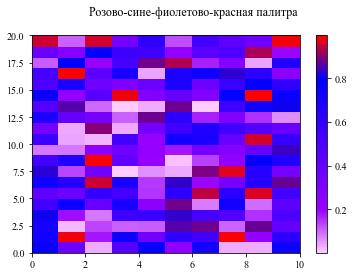

In [ ]:
# розовый [255, 204, 255] -> [1., 0.8, 1.]
# фиолетовый [153, 0, 255] -> [0.6, 0., 1.]
# синий [0, 0, 255] -> [0., 0., 1.]
# красный [255, 0, 0] -> [1., 0., 0.]

cdict1 = {'red':   ((0.0, 1.0, 1.0),  # розовый
                    (0.2, 0.6, 0.6),  # синий 
                    (0.8, 0.0, 0.0),  # фиолетовый 
                    (1.0, 1.0, 1.0)), # красный  

         'green':  ((0.0, 0.8, 0.8),  # розовый
                    (0.2, 0.0, 0.0),  # синий 
                    (0.8, 0.0, 0.0),  # фиолетовый 
                    (1.0, 0.0, 0.0)), # красный  

         'blue':  ((0.0, 1.0, 1.0), # розовый
                   (0.2, 1.0, 1.0), # синий 
                   (0.8, 1.0, 1.0), # фиолетовый
                   (1.0, 0.0, 0.0)) # красный  
          }

cmap1 = mpl.colors.LinearSegmentedColormap('cmap1', cdict1)
plt.register_cmap(cmap=cmap1)
# ---------------------------------------------------------

fig = plt.figure()

ax = fig.add_subplot(111)

cmaplist = plt.cm.datad

cf = ax.pcolor(dat, cmap=cmap1)        
cbar = fig.colorbar(cf, ax=ax)
plt.suptitle(u'Розово-сине-фиолетово-красная палитра')

save('pic_4_4_3', fmt='png')
save('pic_4_4_3', fmt='pdf')

plt.show()

Исследователь Крис Слокум из государственного университета Колорадо [на своём сайте](http://schubert.atmos.colostate.edu/~cslocum/custom_cmap.html) предложил код функции, которая перерабатывает заданный список цветов RGB в относительные единицы и создаёт как равномерную, так и не равномерную цветовую палитры. Это намного удобнее для создания собственной цветовой палитры, когда можно воспользоваться списками RGB из различных источников (см. список электронных ресурсов) и не задавть cdict вручную или писать собственную функцию. 

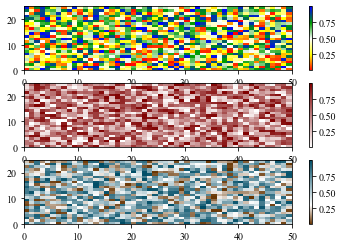

In [ ]:
# Пример взят с http://schubert.atmos.colostate.edu/~cslocum/custom_cmap.html

'''
NAME
    Custom Colormaps for Matplotlib
PURPOSE
    This program shows how to implement make_cmap which is a function that
    generates a colorbar.  If you want to look at different color schemes,
    check out https://kuler.adobe.com/create.
PROGRAMMER(S)
    Chris Slocum
REVISION HISTORY
    20130411 -- Initial version created
    20140313 -- Small changes made and code posted online
    20140320 -- Added the ability to set the position of each color
    20150503 -- Shabanov P.A.: added debug parameter
'''

def make_cmap(colors, position=None, bit=False, debug=False):
    '''
    make_cmap takes a list of tuples which contain RGB values. The RGB
    values may either be in 8-bit [0 to 255] (in which bit must be set to
    True when called) or arithmetic [0 to 1] (default). make_cmap returns
    a cmap with equally spaced colors.
    Arrange your tuples so that the first color is the lowest value for the
    colorbar and the last is the highest.
    position contains values from 0 to 1 to dictate the location of each color.
    '''
    import matplotlib as mpl
    import numpy as np
    bit_rgb = np.linspace(0,1,256)
    if position == None:
        position = np.linspace(0,1,len(colors))
    else:
        if len(position) != len(colors):
            sys.exit("position length must be the same as colors")
        elif position[0] != 0 or position[-1] != 1:
            sys.exit("position must start with 0 and end with 1")
    if(debug):
        print('position:', position)
        print('len colors', len(colors))
        
    if bit:
        for i in range(len(colors)):
            colors[i] = (bit_rgb[colors[i][0]],
                         bit_rgb[colors[i][1]],
                         bit_rgb[colors[i][2]])
    if(debug):
        print('colors', colors)
    cdict = {'red':[], 'green':[], 'blue':[]}
    for pos, color in zip(position, colors):
        cdict['red'].append((pos, color[0], color[0]))
        cdict['green'].append((pos, color[1], color[1]))
        cdict['blue'].append((pos, color[2], color[2]))

    if (debug): 
        print('red', cdict['red'])
        print('green', cdict['green'])
        print('blue', cdict['blue'])

        
    cmap = mpl.colors.LinearSegmentedColormap('my_colormap',cdict,256)
    return cmap

### An example of how to use make_cmap
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(311)
### Create a list of RGB tuples
# 'r', 'y', 'w', 'g', 'b'
colors = [(255,0,0), (255,255,0), (255,255,255), (0,157,0), (0,0,255)] # This example uses the 8-bit RGB
### Call the function make_cmap which returns your colormap
my_cmap = make_cmap(colors, bit=True)
### Use your colormap
plt.pcolor(np.random.rand(25,50), cmap=my_cmap)
plt.colorbar()

ax = fig.add_subplot(312)
colors = [(1,1,1), (0.5,0,0)] # This example uses the arithmetic RGB
### If you are only going to use your colormap once you can
### take out a step.
plt.pcolor(np.random.rand(25,50), cmap=make_cmap(colors))
plt.colorbar()

ax = fig.add_subplot(313)
colors = [(0.4,0.2,0.0), (1,1,1), (0,0.3,0.4)]
### Create an array or list of positions from 0 to 1.
position = [0, 0.3, 1]
plt.pcolor(np.random.rand(25,50), cmap=make_cmap(colors, position=position))
plt.colorbar()

save('pic_4_4_4', fmt='png')
save('pic_4_4_4', fmt='pdf')

plt.show()

### 4.5 Дискретная цветовая палитра

Плавная палитра, несомненно, лучше смотрятся при отображении трёхмерных поверхностей в виде плоских карт и 3D графиков. Однако в научной графике часто требуется не столько красота, сколько простота и однозначность рисунка. Чтобы избежать споров при определении оттенков и, соответственно, значений поля, следует использовать дискретные палитры там, где это критично.

Дискретная палитра представляет собой набор цветов с чёткой границей между соседними оттенками. Обычно этот набор берётся из одной из непрерывных шкал, но можно задать свою последовательность цветов либо в RGB, либо в HEX форматах. 

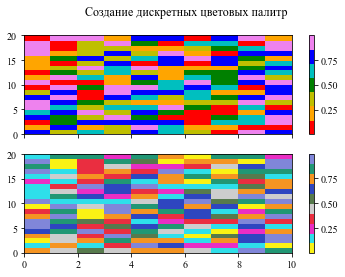

In [ ]:
dat = np.random.random(200).reshape(20,10) # создаём матрицу значений

N = 10
# Список цветов
cpool = [ '#bd2309', '#bbb12d', '#1480fa', '#14fa2f', '#000000',
          '#faf214', '#2edfea', '#ea2ec4', '#ea2e40', '#cdcdcd',
          '#577a4d', '#2e46c0', '#f59422', '#219774', '#8086d9' ]
# Создание дискретных colormap
cmap1 = mpl.colors.ListedColormap(['r','orange','y','g','c','b','violet'], 'indexed')
cmap2 = mpl.colors.ListedColormap(cpool[5:5+N], 'indexed')

#plt.register_cmap(cmap=cmap3)

fig, axes= plt.subplots(nrows=2, ncols=1, sharex=True)

cmaps = [cmap1, cmap2]

for i, ax in enumerate(fig.axes):
    cf = ax.pcolor(dat, cmap=cmaps[i])        
    fig.colorbar(cf, ax=ax)

fig.suptitle(u'Создание дискретных цветовых палитр')

save('pic_4_5_1', fmt='png')
save('pic_4_5_1', fmt='pdf')

plt.show()

При задании дискретной палитры необходимо обращать внимание на согласованность границ делений цветовой шкалы и границ цветов, иначе анализ рисунка будет серьёзно затруднён. На плавной цветовой шкале это не так заметно, как на дискретной.

Для задания положения делений в методе fig.colorbar() или plt.colorbar() необходимо указать параметр ticks. Число положений делений должно быть на 1 больше числа цветов в палитре (делений на отрезке на одну больше, чем промежутков между ними)!

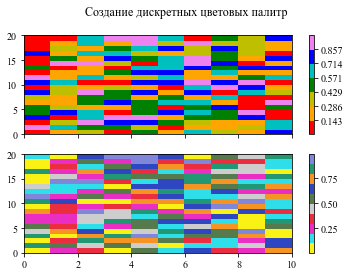

In [ ]:
dat = np.random.random(200).reshape(20,10) # создаём матрицу значений

N = 10
# Список цветов в HEX формате
cpool = [ '#bd2309', '#bbb12d', '#1480fa', '#14fa2f', '#000000',
          '#faf214', '#2edfea', '#ea2ec4', '#ea2e40', '#cdcdcd',
          '#577a4d', '#2e46c0', '#f59422', '#219774', '#8086d9' ]

# Создание дискретных colormap
cmap1 = mpl.colors.ListedColormap(['r','orange','y','g','c','b','violet'], 'indexed')   # 7 цветов
cmap2 = mpl.colors.ListedColormap(cpool[5:5+N], 'indexed')   # 10 цветов

fig, axes= plt.subplots(nrows=2, ncols=1, sharex=True)

cmaps = [cmap1, cmap2]

for i, ax in enumerate(fig.axes):
    cf = ax.pcolor(dat, cmap=cmaps[i])        
    if(i == 0):
        fig.colorbar(cf, ax=ax, ticks=np.linspace(0, 1, 7+1))
    else:
        fig.colorbar(cf, ax=ax)
        
plt.suptitle(u'Создание дискретных цветовых палитр')

save('pic_4_5_2', fmt='png')
save('pic_4_5_2', fmt='pdf')

plt.show()

## 5 Рисунок Figure

Рисунок **Figure** является основой каждого изображения, которые создаётся в matplotlib. Обычно после создания экземпляра рисунка (точнее - экземпляра класса matplotlib.figure.Figure) о нём можно забыть. Тем не менее, именно на основе экземпляра Figure вызываются экземпляры Axes, которые несут основную нагрузку при создании научной графики.

Стоит помнить, что пока идёт работа с одним единственным экземпляром типа Figure, то результат выполнения всех графических команд будут отображаться именно на нём. При работе со многими экземплярами Figure нельзя забывать об очищении "холста" от "красок" предыдущиего рисунка.

### 5.1 Контейнер Figure

Верхним логическим уровнем среди контейнеров Artists (см. Главу 1) является matplotlib.figure.Figure, который включает всё, что есть на рисунке (figure). Фоном (background) рисунка, который определяетя в Figure.patch, по умолчанию является прямоугольник (Rectangle). Когда на рисунке добавляются экземпляры subplots (например, с помощью метода add_subplot()) или axes (с помощью метода add_axes()), они автоматически добавляются в список Figure.axes. Так как matplotlib поддерживает концепцию "текущей области" ("current axes"; подробнее см. Figure.gca и Figure.sca) для работы с pylab/pyplot, то не рекомендуется добавлять или убирать axes из списка (axes list) вручную. Лучше использовать методы add_subplot()/add_axes() для добавления экземпляров Axes и delaxes() для их удаления. 

**Совет**

> Можно использовать список fig.axes() для работы с экземплярами Axes. Например, для добавления линий сетки с помощью метода grid() на все axes рисунка.

<class 'matplotlib.figure.Figure'>


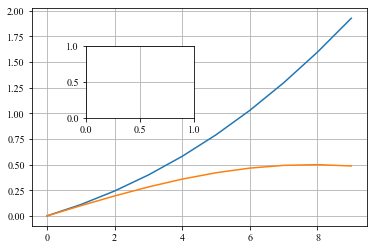

In [ ]:
fig = plt.figure()

print(type(fig))
# Создание экземпляра Axes c помощью Figure-метода add_subplot()
ax = fig.add_subplot(111)
# или так
box = [0.25, 0.5, 0.25, 0.25]
# Создание экземпляра Axes c помощью Figure-метода add_axes()
ax2 = fig.add_axes(box)

x = np.arange(0.0, 1.0, 0.1)
y = np.sin(x)*np.exp(x)
z = np.cos(x)*np.sin(x)

# Методы plot() вызываются через экземпляры ax, а не plt (интерфейс pyplot)
ax.plot(y)
ax.plot(z)

for ax in fig.axes:
    ax.grid(True)
    
save('pic_5_1', fmt='png')
save('pic_5_1', fmt='pdf')
    
plt.show()

Список элементов рисунка (Artists) для контейнера Figure:

1. **axes** - список экземпляров Axes (включая Subplot);

2. **images** - список FigureImages patches (эффективно для отображения пикселей);

3. **legends** - список экземпляров Figure Legend (отличается от Axes.legends);

4. **lines** - список экземпляров Figure Line2D (редко используется, см. Axes.lines);

5. **patch** - фон Rectangle;

6. **patches** - список Figure patches (редко используется, см. Axes.patches);

7. **texts** - список экземпляров Figure Text.

### 5.2 Конфигурация Figure

Одним из стандартных методов создания экземпляра Figure является следующий:

In [ ]:
fig = plt.figure()
print(u'Тип Figure %s' % type(fig))

Тип Figure <class 'matplotlib.figure.Figure'>


<Figure size 432x288 with 0 Axes>

Основные параметры созданного экземпляра Figure определяются в конфигурационном файле matplotlibrc. Атрибуты Figure можно изменить во время создания экземпляра:

+ **figsize** : кортеж из целых или действительных чисел, который определяет ширину и высоту в дюймах. По умолчанию равен значению figure.figsize из настроек rcParams;

+ **dpi** : разрешение рисунка. По умолчанию равен значению figure.dpi из настроек rcParams;

+ **facecolor** : цвет фона. По умолчанию равен значению figure.facecolor из настроек rcParams;

+ **edgecolor** : цвет границы. По умолчанию равен значению figure.edgecolor из настроек rcParams.

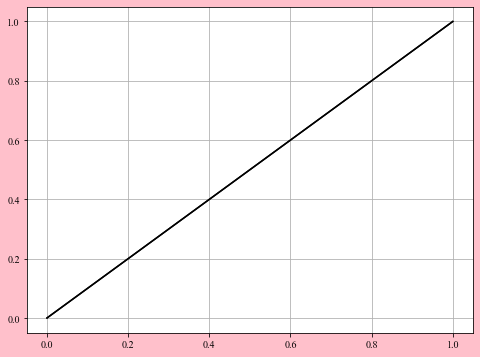

In [ ]:
figsize = (8,6)

fig = plt.figure(figsize=figsize, facecolor='pink', frameon=True)
plt.plot([[0.0,0.0],[1.,1.]],'k')
plt.grid(True)
rcParams['figure.edgecolor'] = 'blue'

save('pic_5_2_1', fmt='png')
save('pic_5_2_1', fmt='pdf')

plt.show()

По умолчанию цвета координатной координатных осей, линий вспомогательной сетки отрисовываются чёрным цветом, а цвет фона (основы рисунка) - белым. Заменив параметры, отвечающие за соответствующие цвета, можно создать, например, инвертированный бело-чёрный рисунок. Иногда такая графика смотрится очень наглядно, стильно и привлекает к вашему материалу повышенное внимание.

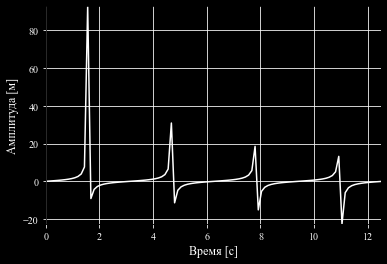

In [ ]:
rcParams['font.family'] = 'Times New Roman', 'Arial', 'Tahoma'
rcParams['font.fantasy'] = 'Times New Roman'

# Изменение параметров рисования (смена чёрного по белому на белое по чёрному)
facecolor = 'k'

rcParams['figure.edgecolor'] = facecolor
rcParams['figure.facecolor'] = facecolor
rcParams['axes.facecolor'] = facecolor
#rcParams['axes.edgecolor'] = 'k'
rcParams['grid.color'] = 'w'
rcParams['xtick.color'] = 'w'
rcParams['ytick.color'] = 'w'
rcParams['axes.labelcolor'] = 'w'

x = np.arange(0, 4*np.pi, 0.12)
y = np.tan(x)

fig = plt.figure()
plt.plot(x, y,'w')

plt.xlim(x[0], x[-1])
plt.ylim(np.min(y), np.max(y))

plt.xlabel(u'Время [c]', fontsize=12)
plt.ylabel(u'Амплитуда [м]', fontsize=12)
plt.grid(True, color='w')

save('pic_5_2_2', fmt='png')
save('pic_5_2_2', fmt='pdf')

plt.show()

### 5.3 Сохранение рисунка

Сохранить получившийся рисунок можно с помощью метода savefig, применённого либо к экземпляру Figure (fig.savefig()), либо через pyplot (plt.savefig()). 

Стоит помнить, что по умолчанию метод savefig имеет значения атрибутов типа facecolor отличные от значений figure.facecolor. В конфигурационном файле matplotlibrc можно настроить соответствующие параметры как для savefigure, так и для figure. Поэтому чтобы сохранить пользовательские настройки рисунка методом savefig, нужно изменить атрибуты savefig, а не соответствующие атрибуты figure (dpi, format, edgecolor, facecolor, frameon) или передать соответствующие значения атрибутов явно при вызове метод savefig:

In [ ]:
# Сохранение рисунка с параметрами цвета фона по умолчанию

rcParams['savefig.edgecolor'] = 'k'
rcParams['savefig.facecolor'] = 'k'
rcParams['grid.color'] = 'w'
rcParams['xtick.color'] = 'w'
rcParams['ytick.color'] = 'w'
rcParams['axes.labelcolor'] = 'w'

fig.savefig('pic_5_3_1.png', format='png')
fig.savefig('pic_5_3_1.pdf', format='pdf')

# Сохранение рисунка с пользовательскими параметрами цвета фона
rcParams['savefig.edgecolor'] = 'w'
rcParams['savefig.facecolor'] = 'w'
rcParams['grid.color'] = 'k'
rcParams['xtick.color'] = 'k'
rcParams['ytick.color'] = 'k'
rcParams['axes.labelcolor'] = 'k'

# Атрибут facecolor передаётся явно
fig.savefig('pic_5_3_2', format='png', facecolor='k')
fig.savefig('pic_5_3_2', format='pdf', facecolor='k')

Так как для сохранения рисунков методом savefig требуется явно задать некоторые атрибуты, то среди атрибутов при создании экземпляра Figure имеет смысл задавать те, которые не являются входящими для метода savefig, а именно figsize. Figsize позволяет сделать рисунок меньше или больше и определяет физический размер рисунка. Так можно подобрать нужный размер для печати. 

Для справки:

> 1 дюйм = 2.54 см<br>
> Лист А4 имеет размеры 210x297 мм

Разрешение рисунка можно получить умножив значения атрибутов figure.figsize и figure.dpi. DPI показывает сколько точек-пикселей приходится на один дюйм.

[2.7559055118110236, 0.984251968503937]


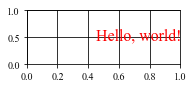

In [ ]:
import matplotlib as mpl

def cm2inch(a):
    '''
    Converts inches to santimeters
    '''
    b = []
    for i in a:
        b.append(i/2.54)
    return b

# Возвращаем обычные значения цветов для дальнейшей интерактивной работы

rcParams['figure.edgecolor'] = 'w'
rcParams['figure.facecolor'] = 'w'
rcParams['axes.facecolor'] = 'w'
rcParams['axes.edgecolor'] = 'k'
rcParams['grid.color'] = 'k'
rcParams['xtick.color'] = 'k'
rcParams['ytick.color'] = 'k'
rcParams['axes.labelcolor'] = 'k'

figsize = (7, 2.5) # см
figsize = cm2inch(figsize)
print(figsize)
fig2 = plt.figure(figsize=figsize, facecolor='w')
rcParams['figure.edgecolor'] = 'w'
plt.text(0.45, 0.45,'Hello, world!', color='red', fontsize=16)
plt.grid(True)

save('pic_5_3_3', fmt='png')
save('pic_5_3_3', fmt='pdf')

plt.show()

## 6. Область рисования Axes

Область рисования Axes - это центральный объект при создании научных графиков. Это тот объект, та область на которую наносятся координатные оси, линии графиков и столбцы диаграмм, легенды к ним и так далее. Взамен активного использования pyplot предлагается использовать более объектно-ориентированный подход для вызова графических команд и изменениях их свойств.


### 6.1 Контейнер Axes

Структурно область рисования Axes необходима как элемент более низкого иерархического уровня нежели Figure (весь рисунок), на котором непосредственно будут располагаться различные графические элементы. Axes похож на Frame в веб-дизайне, то есть это область, на которой можно размещать графические примитивы. При этом в matploltib непосредственно на Figure нельзя рисовать (изменение цвета фона не считается за полноценное рисование) и соответственно нужен хотя бы один экземпляр axes.

Область рисования Axes является второй "матрёшкой" (после Figure) или контейнером, на который можно наносить другие элементы рисунка (или контейнеры), в первую очередь координатные оси Axis. 

При создании области рисования создаётся экземпляр класса `matplotlib.axes._axes.Axes`. Этот класс является, пожалуй, центром вселенной matplotlib. Он включает большинство всех элементов рисунка Artists, которые используются при создании рисунка, а также большую часть вспомогательных методов для настройки этих методов. Также у данного класса есть родственный класс `matplotlib.axes._subplots.AxesSubplot`, который создаётся при создании мультиокон subplots. 

Список областей рисования после создания объекта fig [] 

Список областей рисования после вызова комманды scatter [<matplotlib.axes._subplots.AxesSubplot object at 0x0000021FD7235388>] 



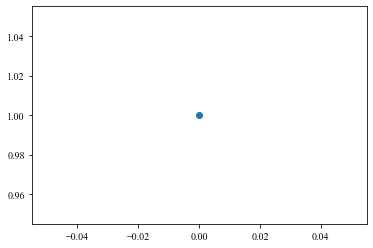

In [ ]:
fig = plt.figure()

print (u'Список областей рисования после создания объекта fig %s \n' % fig.axes)

plt.scatter(0.,1.)

print (u'Список областей рисования после вызова комманды scatter %s \n' % fig.axes)
    
save('pic_6_1_1', fmt='png')
save('pic_6_1_1', fmt='pdf')
    
plt.show()

После создания экземпляра fig типа Figure список областей рисования fig.axes пуст. Но стоит вызвать любую графическую команду, создающую графический примитв, и в нём появляется экземпляр типа AxesSubplot. Таким образом, при работе с интерфейсом pyplot область рисования создаётся неявно, но она существует и именно на ней располагаются многие графические элементы (линии, текст и т.д.).

Чтобы лучше понять сущность Axes как контейнера/хранилища графических примитивов (или других контейнеров подчинённого уровня), рассмотрим что происходит с экземпляром области рисования при вызове графической команды.

Lines on the axes: <class 'list'> [<matplotlib.lines.Line2D object at 0x0000021FD55589C8>]
Patches on the axes: 50 <a list of 50 Patch objects>


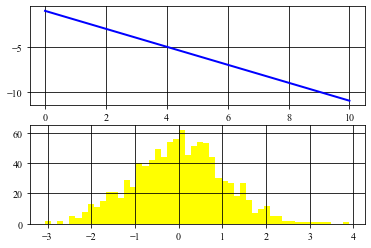

In [ ]:
x = [0,1,2,3,4,5,6,7,8,9,10]
y = [-1,-2,-3,-4,-5,-6,-7,-8,-9,-10,-11]

fig = plt.figure()

# Первая область рисования (мультиокно 1)
ax = fig.add_subplot(211)
line = ax.plot(x, y, '-', color='blue', linewidth=2)
print('Lines on the axes:', type(line), line)

# Вторая область рисования (мультиокно 2)
ax2 = fig.add_subplot(212)
n, bins, rectangles = ax2.hist(np.random.randn(1000), 50, facecolor='yellow')
print('Patches on the axes:', len(ax2.patches), rectangles)

for ax in fig.axes:
    ax.grid(True)

save('pic_6_1_2', fmt='png')
save('pic_6_1_2', fmt='pdf')

plt.show()

При вызове метода `ax.plot()` создаётся экземпляр `matplotlib.lines.Line2D()`, эта линия обновляется по всем свойствам Line2D, которые были переданы в виде ключевых слов (keyword arguments), добавляется в контейнер Axes.lines и возвращается пользователю в виде списка линий. Методы, которые создают геометрические фигуры patches (например, `plt.bar()` создаёт ряд прямоугольников rectangles), добавляют patches в список Axes.patches.

### 6.2 Создание областей рисования

Чтобы создать область рисования типа Axes или AxesSubplot, существует ряд способов (подробнее смотри в следующей главе). Одним из стандартных способов создания области рисования является метод `fig.add_axes()` экземпляра fig объекта Figure. В качестве обязательного параметра rect метод просит указать последовательность из координат начальной точки (x, y), а также ширины и высоты от неё до другого угла прямоугольника (в случае круговой области рисования - смотри главу "Графики в полярных координатах"). Значения должны быть выражены в относительных единицах от 0 до 1 включительно. 

Весь рисунок Figure по сути имеет начальную точку (0., 0.) и ширину/высоту (1., 1.). Поэтому относительно определения границ области рисования стоит помнить следующее: подписям координатных осей (axis labels), заголовкам (titles) и подписям делений координатных осей (tick labels) нужно место. Определив размер области рисования вплотную к границам рисунка и передав в качестве аргумента список [0, 0, 1, 1], можно столкнуться с ситуацией, когда подписи вылезли за пределы рисунка, и при сохранении рисунок окажется обрезанным. Это не всегда очевидно при работе в среде ipython, ipython notebook, поэтому лучше проверять результат рисования перед запуском поточного производства графиков.

Тип ax: <class 'matplotlib.axes._axes.Axes'>


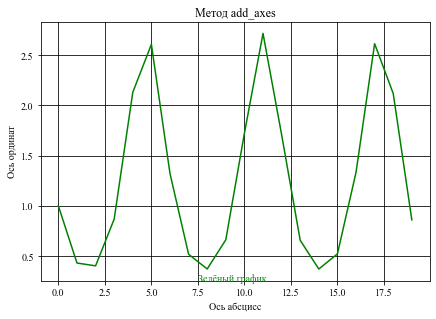

In [ ]:
fig = plt.figure()

x = np.arange(20)
y = np.exp(-np.sin(x))

x0 = 0.05
y0 = 0.05
dx = 0.9
dy = 0.9

rect = [x0, y0, dx, dy]
ax = fig.add_axes(rect)

ax.plot(x, y, 'g')
ax.text(7.5, 0.25, u'Зелёный график', color='g')
ax.grid(True)

# В отличие от интерфейса pyplot, команды для назначения подписей 
# нужно употреблять с приставкой set_

ax.set_title(u'Метод add_axes')
ax.set_xlabel(u'Ось абсцисс')
ax.set_ylabel(u'Ось ординат')

print ('Тип ax: %s' % type(ax))

save('pic_6_2_1', fmt='png')
save('pic_6_2_1', fmt='pdf')

plt.show()

Также можно создавать области рисования с помощью метода `fig.add_subplot()`, который позволяет создавать мультиокона (subplots) или мультиоконные рисунки. Создаваемая таким способом область рисования имеет другой, но родственный, класс - AxesSubplot. В качестве обязательного параметра subplot просит указать триплет (набор из 3 цифр), который определяет место области на рисунки. Подробнее о subplot будет рассказно в следующей главе. Для создания одной области рисования типа AxesSubplot или просто subplot, триплет равен 111.

Тип ax: <class 'matplotlib.axes._subplots.AxesSubplot'>


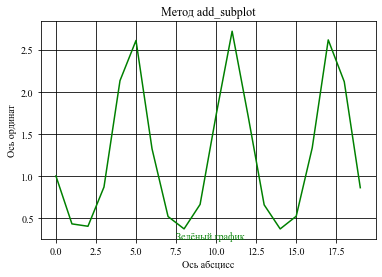

In [ ]:
fig = plt.figure()

x = np.arange(20)
y = np.exp(-np.sin(x))

ax = fig.add_subplot(111)
ax.plot(x, y, 'g')
ax.text(7.5, 0.25, u'Зелёный график', color='g')
ax.grid(True)

# В отличие от интерфейса pyplot, команды для назначения подписей 
# нужно употреблять с приставкой set_

ax.set_title(u'Метод add_subplot')
ax.set_xlabel(u'Ось абсцисс')
ax.set_ylabel(u'Ось ординат')

print ('Тип ax: %s' % type(ax))

save('pic_6_2_2', fmt='png')
save('pic_6_2_2', fmt='pdf')

plt.show()

Ничто не мешает комбинировать методы `add_subplot` и `add_axes` на одном рисунке Figure. Стоит, однако, помнить, что размещая явно область рисования методом `fig.add_axes()`, можно перекрыть другие созданные области рисования. Иногда это оказывается полезным (создание "окна в окне"), а иногда это может привести к неприятному эффекту.


**Правила хорошего кода**

> В дальнейшем мы всегда будем соблюдать следующие правила при создании научной графики:<br><br>
> **1. Явно создавать экземпляр Figure:**<br>
> `import matplotlib.pyplot as plt`<br>
> `fig = plt.figure()`<br><br>
> **2. Создавать хотя бы одну область рисования Axes:**<br>
> `ax = fig.add_subplot(111)`<br>
> или<br>
> `ax = fig.add_axes[0.05, 0.05, 0.9, 0.9]`<br><br>
> **3. Интерфейс pyplot далее мы будем использовать редко, за исключением следующих случаев:**<br>
> + `plt.figure()`<br>
> + `plt.tight_layout()`<br>
> + `plt.show()`

Считается хорошим тоном не использовать неявный импорт типа "`from matplotlib.pyplot import *`" или "`from pylab import *"`. Лучше использовать явный импорт: "`from matplotlib import rcParams as rc`". Также при создании достаточно сложных рисунков не стоит использовать интерфейс pyplot. Он хорош для ознакомления и быстрой визуализации черновиков. Но для создания high quality plots, которые требуются для полиграфии и при публикациях в научных журналах, лучше использовать методы axes, а не pyplot. 

### 6.3 Круговые и прямоугольные области рисования

Как и Figure, область рисования Axes имеет атрибут patch, который является прямоугольным (Rectangle) для декартовой системы координат и круговым (Circle) для полярной системы координат. Этот patch определяет форму, фон и границы создаваемой области рисования. Подробнее о графиках в полярных координатах и областях рисования в полярных координатах показано в соответствующей главе.

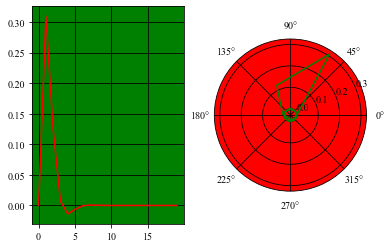

In [ ]:
x = np.arange(20)
y = np.exp(-x)*np.sin(x)

fig = plt.figure()

# Обычный график в декартовых координатах
ax = fig.add_subplot(121, polar=False)
ax.plot(x, y, 'r')
rect = ax.patch 
rect.set_facecolor('green')
ax.grid(True)

# График в полярных координатах
ax2 = fig.add_subplot(122, polar=True)
ax2.plot(x, y, 'g')
rect = ax2.patch  # Круговой
rect.set_facecolor('red')

save('pic_6_3', fmt='png')
save('pic_6_3', fmt='pdf')

plt.show()

### 6.4 Методы области рисования Axes

Все графические команды, применимые для интерфейса pyplot, применимы и для Axes. Разница заключается лишь в том, что вызывать их нужно не от plt (matplotlib.pyplot), а от экземпляра типа Axes или AxesSubplot. 

C методами настройки посложнее: почти все функции имеют аналоги, но бывают синтаксические различия. Например, чтобы сделать подпись оси ординат в интерфейсе pyplot мы использовали метод `plt.ylabel()`. Для экземпляра области рисования ax подобный метод вызывается через метод `ax.set_xlabel()`. 

**SET & GET**

Вообще говоря, в matplotlib при работе с различными свойствами элементов рисунка поддерживается система "set-get". Её суть состоит в том, что если нужно получить текущее значение атрибута или свойства объекта, то нужно вызвать его с помощью соответствующей команды-функции с приставкой "get_". Например, чтобы получить список, состоящий из положений главных делений на оси абсцисс из области рисования ax, то нужно указать

> `current_xticks = ax.get_xticks()`

А чтобы изменить этот список на пользовательский, нужно вызвать аналогичную команду, но с приставкой "set_". В случае с делениями оси абсцисс это выглядит так:

> `new_xticks = ax.set_xticks(custom_xticks)`

Существует множество вспомогательных методов Axes для создания и изменения свойств элементов рисунков и графических примитивов, то есть множество графических команд. Всё, что доступно для pyplot, доступно и для axes-экземпляров. Далее приводятся некоторые из них:

----------------------------------------------------------

Вспомогательный метод -> Описание -> Artist -> Контейнер

----------------------------------------------------------

1. ax.annotate -> текстовая подпись -> Annotate	-> ax.texts

2. ax.text -> текст -> Text -> ax.texts

3. ax.bar -> столбчатая диаграмма -> Rectangle -> ax.patches

4. ax.errorbar -> график погрешностей -> Line2D и Rectangle -> ax.lines и ax.patches

5. ax.fill -> заливка области -> Polygon -> ax.patches

6. ax.hist -> гистограмма -> Rectangle -> ax.patches

7. ax.imshow -> изображение -> AxesImage -> ax.images

8. ax.legend -> легенда -> Legend -> ax.legends

9. ax.plot -> XY график -> Line2D -> ax.lines

10. ax.scatter -> точечная диаграмма -> PolygonCollection -> ax.collections

----------------------------------------------------------

Lines: <class 'list'> [<matplotlib.lines.Line2D object at 0x0000021FD54F6F48>]
Patches: 50 <a list of 50 Patch objects>


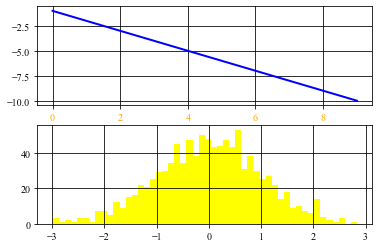

In [ ]:
x = np.arange(10)
y = np.arange(-1, -11, -1)

fig = plt.figure()

ax = fig.add_subplot(211)
line = ax.plot(x, y, '-', color='blue', linewidth=2)
print ('Lines:', type(line), line)

# Изменяем цвет подписей делений оси OX с помощью "set-get" технологии
for label in ax.get_xticklabels():
    label.set_color('orange')

ax2 = fig.add_subplot(212)
n, bins, rectangles = ax2.hist(np.random.randn(1000), bins=50, facecolor='yellow')
print ('Patches:', len(ax2.patches), rectangles)

for ax in fig.axes:
    ax.grid(True)

save('pic_6_4_1', fmt='png')
save('pic_6_4_1', fmt='pdf')

plt.show()

При создании того или иного графического объекта на текущей области рисования он добавляется в соответствующий его типу контейнер. Ниже представлен краткий список таких Artists-контейнеров, которые есть у Axes. 

----------------------------------------------------------

Axes атрибут - Описание

----------------------------------------------------------

1. patch - экземпляр Rectangle для фона (background) Axes;

2. artists - список экземпляров Artist;

3. collections - список экземпляров Collection;

4. images - список экземпляров AxesImage;

5. legends - список экземпляров Legend;

6. lines - список экземпляров Line2D;

7. patches - список экземпляров Patch;

8. texts - список экземпляров Text;

9. xaxis - экземпляр matplotlib.axis.XAxis;

10. yaxis - экземпляр matplotlib.axis.YAxis.

------------------------------------------------------

XAxis и YAxis являются очень важными Artist-контейнерами. Через обращение к ним можно изменять свойства отрисовки делений (ticks) и подписей (labels) координатных осей. Например, с их помощью можно изменить размер шрифта подписей делений оси абсцисс XAxis с помощью вспомогательных методов Axes. Подробнее о работе с контейнерами XAxis и YAxis будет рассказано в главе "Координатные оси".

Lines: <class 'list'> [<matplotlib.lines.Line2D object at 0x0000021FD7107208>]
Patches: 50 <a list of 50 Patch objects>


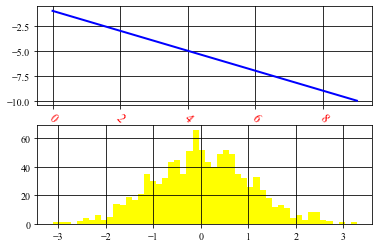

In [ ]:
x = np.arange(10)
y = np.arange(-1, -11, -1)

fig = plt.figure()

ax = fig.add_subplot(211)
line = ax.plot(x, y, '-', color='blue', linewidth=2)
print ('Lines:', type(line), line)

# Изменяем цвет подписей делений оси OX с помощью работы с контейнером XAxis
for label in ax.xaxis.get_ticklabels():
    label.set_color('red')
    label.set_rotation(-45)
    label.set_fontsize(12)

ax2 = fig.add_subplot(212)
n, bins, rectangles = ax2.hist(np.random.randn(1000), bins=50, facecolor='yellow')
print ('Patches:', len(ax2.patches), rectangles)

for axes in fig.axes:
    axes.grid(True)

save('pic_6_4_2', fmt='png')
save('pic_6_4_2', fmt='pdf')

plt.show()

В настройках matplotlib у области рисования Axes имеется несколько атрибутов, которые заданы по умолчанию. Именно эти параметры определяют свойства графических элементов (цвет линии, наличие вспомогательной сетки grid, цвет и размер шрифта подписей координатных осей) для каждого вновь созданного тем или иным способом экземпляра Axes.

----------------------------------------------------------

1. u'axes.edgecolor': u'k'

2. u'axes.facecolor': (1, 1, 1, 0)

3. u'axes.formatter.limits': [-7, 7]

4. u'axes.formatter.use_locale': False

5. u'axes.formatter.use_mathtext': False

6. u'axes.formatter.useoffset': True

7. u'axes.grid': False

8. u'axes.grid.which': u'major'

9. u'axes.hold': True

10. u'axes.labelcolor': u'k'

11. u'axes.labelsize': u'medium'

12. u'axes.labelweight': u'normal'

13. u'axes.linewidth': 1.0

14. u'axes.titlesize': u'large'

15. u'axes.titleweight': u'normal'

16. u'axes.unicode_minus': True

17. u'axes.xmargin': 0.0

18. u'axes.ymargin': 0.0

----------------------------------------------------------

Изменяя значения их непосредственно в файле matplotlibrc или по ходу программы с помощью rcParams, можно добиться пользовательской настройки шрифтов, цвета и других параметров области рисования axes. Описанные выше свойства применяются ко всем вновь созданным экземплярам типа Axes. Очевидно, что разные области рисования могут иметь разные параметры в рамках одного рисунка.

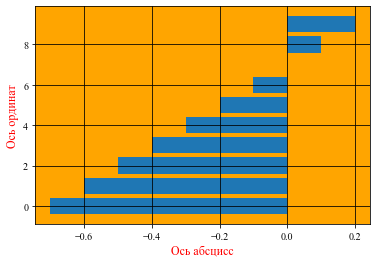

In [ ]:
rcParams['axes.grid'] = True
rcParams['axes.facecolor'] = 'orange'
rcParams['axes.labelcolor'] = 'red'
rcParams['axes.labelsize'] = 'large'
rcParams['axes.labelweight'] = 'bold'

k = 0.1
b = -0.7

x = np.arange(10)
y = k*x + b

fig = plt.figure()

ax = fig.add_subplot(111)
ax.barh(x, y)
ax.set_xlabel(u'Ось абсцисс')
ax.set_ylabel(u'Ось ординат')
ax.grid(True)

save('pic_6_4_3', fmt='png')
save('pic_6_4_3', fmt='pdf')

plt.show()

## 7. Мультиоконные рисунки

В прошлых главах мы рассмотривали в основном простые графики, где область рисования Axes была одна. В это параграфе мы поговорим о сложных рисунках, которые могут содержать не одну, а несколько областей рисования. Вместо слова "несколько" можно было бы употребить слово "много", но лучше никогда не рисовать много графиков на одном рисунке. 

**Золотое правило:** 

> Недопустимо, если не все части или элементы рисунка понятны или хорошо различаемы на фоне остальных. Рисунок должен быть читаемым, а не коробкой, в которую автор напихал от жадности (или жёстких требований журнала/издателя) всё, что смог создать. Нужно следовать python-заповеди (см. `import this`): "сложное лучше, чем запутанное". Как сделать так, чтобы запутанные рисунки стали сложными, сохранив при этом функциональность и привлекательный вид, показано в этой главе.

### 7.1 Методы создания мультиокон

В matplotlib реализовано несколько спобов создания рисунков с несколькими областями для диаграмм (multi-panel plots):

1. **`fig.add_axes()`** - базовый метод, удобен при создании диаграммы-врезки;

2. **`fig.add_subplot()`** - добавление одного subplot на рисунок. Удобно для отображения 2-3 диаграмм;

3. **`plt.subplot()`** - аналогичный предыдущему по результату метод для pyplot;

4. **`plt.subplots()`** - удобный метод для автоматизированного создания нескольких subplots;

5. **`plt.GridSpec()`** - метод для объединения ячеек subplots в более сложные конфигурации. Позволяет создавать разные по форме subplots на рисунке.

Первые два метода (с приставкой `add_`) являются более низкоуровнемыми, и для их вызова требуется объект Figure. Последние три метода реализованы в pyplot интерфейсе. Каждый из этих методов создаёт один или более экземпляров типа subplot (в примерах будет приведён точный тип этого объекта) или axes. Каждый такой объект - отдельная область рисования и к ней применимы все те приёмы, которые мы рассмотрели в предыдущей главе, когда работали с экземпляром-объектом типа axes. Хотя метод `fig.add_axes` создаёт объект типа Axes, а все остальные - типа AxesSubplot, то есть разные типы объектов, они являются родственными, и работать с ними можно одними и теми же методами.

Самым простым способом разбить, то есть поделить, рисунок на несколько частей является способ `fig.add_subplot()`. Смысл создания subplots состоит в том, что они наполняют рисунок ячейками (как в таблице) в каждой из которой теперь можно создавать свой собственный график или диаграмму (или карту-схему). 

Метод `fig.add_subplot()` всегда имеет три обязательных аргумента: число ячеек по вертикали (число строк), число ячеек по горизонтали (число столбцов) и номер ячейки (отсчёт ведётся от 1 слева направо, сверху вниз). Три числа перечисленные через запятую (3,2,5) или триплет в виде одного числа (325), переданные методу fig.add_subplot(), создают экземпляр (instance) "`matplotlib.axes._subplots.AxesSubplot`", что является подвидом более широкого класса "`matplotlib.axes`".

`fig.add_subplot()` оптимален, когда необходимо быстро изобразить несколько (обычно 2-3) графиков-диаграмм рядом. Желательно при этом, чтобы они не перекрывались, за исключением случаев, когда области рисунка "слипаются" и образуют общие границы (как по оси абсцисс, так и по оси ординат).

Область 1 AxesSubplot(0.125,0.536818;0.775x0.343182)
<class 'matplotlib.axes._subplots.AxesSubplot'>
Область 2 AxesSubplot(0.125,0.125;0.775x0.343182)


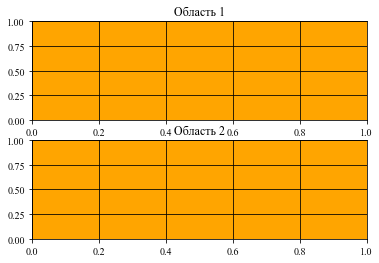

In [ ]:
# Создание двух областей на рисунке с помощью fig.add_subplot()

fig = plt.figure()

tri = 211
ax1 = fig.add_subplot(tri)
ax1.set_title(u'Область 1')
ax2 = fig.add_subplot(2, 1, 2)
ax2.set_title(u'Область 2')

# Узнаём координаты областей, которые занимают subplots
print (u'Область 1', ax1)
print (type(ax1))
print (u'Область 2',ax2)

# Нарисуем в каждом subplot линию сетки
for ax in fig.axes:
    ax.grid(True)
    
save('pic_7_1_1', fmt='png')
save('pic_7_1_1', fmt='pdf')
    
plt.show()

Аналогичного результата можно добиться и "в лоб", то есть самостоятельно задать границы нужных областей. Для прямого выделения положения областей на рисунке нужно использовать метод `fig.add_axes()`. На рисунке в относительных координатах (от 0 до 1) можно задать несколько (сколько угодно) областей, на каждой из которых можно будет рисовать графики и диаграммы (не забываем про карты и изображения-фотографии). Каждая область задаётся отдельно и требует указать параметры границы в виде списка [левая, нижняя, ширина, высота]. Стоит отметить, что этот метод позволяет задать многие важные настройки создаваемой области рисования и в частности тип области рисования (если параметр `polar=True` или `projection='polar'`, то область рисования будет не прямоугольной, а круговой).

Область 1 Axes(0.125,0.547727;0.775x0.352273)
<class 'matplotlib.axes._axes.Axes'>
Область 2 Axes(0.125,0.125;0.775x0.352273)


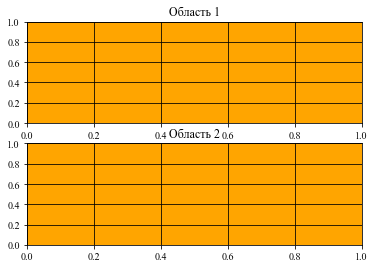

In [ ]:
fig = plt.figure()

# В примере для задания границ областей была использована информация
# о границах subplots из предыдущего примера

ax1 = fig.add_axes([0.125, 0.547727, 0.775, 0.352273]) 
ax1.set_title(u'Область 1')
ax2 = fig.add_axes([0.125, 0.125, 0.775, 0.352273]) 
ax2.set_title(u'Область 2')

# Узнаём координаты областей, которые занимают subplots
print (u'Область 1', ax1)
print (type(ax1))
print (u'Область 2',ax2)

# Нарисуем в каждом subplot линию сетки
for ax in fig.axes:
    ax.grid(True)
    
save('pic_7_1_2', fmt='png')
save('pic_7_1_2', fmt='pdf')
    
plt.show()

В примерах области ax1 - это экземпляры разных классов:
   
> ax1 axes -> `matplotlib.axes._axes.Axes`

> ax1 subplots -> `matplotlib.axes._subplots.AxesSubplot`

Если вы хотите изменить размер и размещение экземпляра subplot после того, как он был создан, то можно использовать метод `ax.set_position()`.

> Пример: `ax.set_position([0.1,0.1, 0.5, 0.5])`.

### 7.2 Близкое расположение областей рисования

Если создавать области рисования с помощью метода `fig.add_axes()`, то созданные области, которые имеют общее место на рисунке, будут перекрывать друг друга. Так как в matplotlib используется идеология рисования текущей области ("current axis"), то последнее нарисованное изображение одного уровня (области, линии и т.д.) будет перекрывать предыдущие.

Вновь создавамая область рисования типа subplot вписывается в рисунок в границах, определяемых соответствующими параметрами rcParams:

> `rcParams['figure.subplot.left'] = 0.125`    # левая граница

> `rcParams['figure.subplot.right'] = 0.9`    # правая граница

> `rcParams['figure.subplot.bottom'] = 0.125`  # нижняя граница

> `rcParams['figure.subplot.top'] = 0.9`    # верхняя граница

При использования методов `fig.add_subplot()` или `plt.subplots()` по умолчанию оставляется некоторое свободное пространство между создаваемыми областями. Изменяя размер этих "буферов" с помощью соответствующих параметров настройки rcParams, можно добиться эффекта соединения или склейки.

> `rcParams['figure.subplot.hspace'] = 0.2 `  # определяет совокупное вертикальное расстояние между subplots

> `rcParams['figure.subplot.wspace'] = 0.2`   # определяет совокупное горизонтальное расстояние между subplots

Для аналогичной настройки можно воспользоваться методом pyplot `plt.tight_layout()`. Данный метод позволяет "навести красоту" одной строчкой. Часто это очень экономит время от "вылизывания" пустяковых графиков до приличного вида. Метод имеет четыре параметра:

+ **pad** - расстояние между краями рисунка Figure и краями subplots, выраженное в виде доли fontsize (см. rcParams['font.size']) 

+ **h_pad** - совокупное расстояние по вертикали между subplots. По умолчанию имеет значения pad_inches (rcParams['savefig.pad_inches'])

+ **w_pad** - расстояние по горизонтали между краями соседних subplots. По умолчанию имеет значения pad_inches (rcParams['savefig.pad_inches'])

+ **rect** - если задан, то это прямоугольник (левый, низ, правый, верх) в относительных координатах figure, в который будут вписаны все области subplots (включая подписи). По умолчанию (0, 0, 1, 1).

В совокупности нижние четыре параметра - это те же самые параметры, которые используются в качестве входящих для параметра rect в методе `plt.tight_layout()`. Данным методом можно определять взаимное (не но отдельное) положение subplots и сдвигать их, как отдаляя их друг от друга, так и сближая (отрицательные значения h_pad и w_pad).

Область 1 AxesSubplot(0.125,0.536818;0.775x0.343182)
<class 'matplotlib.axes._subplots.AxesSubplot'>
Область 2 AxesSubplot(0.125,0.125;0.775x0.343182)


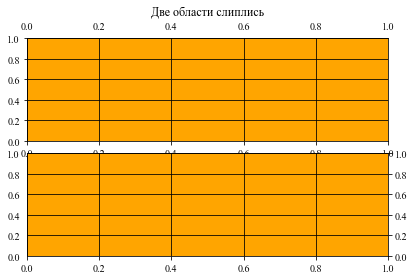

In [ ]:
fig = plt.figure()

ax1 = fig.add_subplot(211)
ax1.set_title(u'Две области слиплись')
ax2 = fig.add_subplot(212)

# Чтобы подписи осей координатных сеток не сливались разнесём их
# в разные стороны - одну оставим слева, а другую вынесем направо
ax1.tick_params(axis='x', labelbottom='off', labeltop='off') 
ax2.tick_params(axis='y', labelleft='off', labelright='on', left=False, right=True)
# Узнаём координаты областей, которые занимают subplots
print (u'Область 1', ax1)
print (type(ax1))
print (u'Область 2',ax2)

# Нарисуем в каждом subplot линию сетки

for ax in fig.axes:
    ax.grid(True)

# Параметр подобран эмпирически, на глаз. Это скверно

plt.tight_layout(h_pad = -0.88)

save('pic_7_2_1', fmt='png')
save('pic_7_2_1', fmt='pdf')

plt.show()

В примере ниже область ax2 создана позже, чем ax1. Значит именно ax2 будет перекрывать область ax1. Если поменять местами ax1 и ax2 (строчки кода, где они создаются, а не где на этих областях рисуются линии), то область с голубой линией будет перекрыта и мы её вообще не увидим.

Область 1 Axes(0,0;1x1)
<class 'matplotlib.axes._axes.Axes'>
Область 2 Axes(0.5,0.5;0.5x0.5)


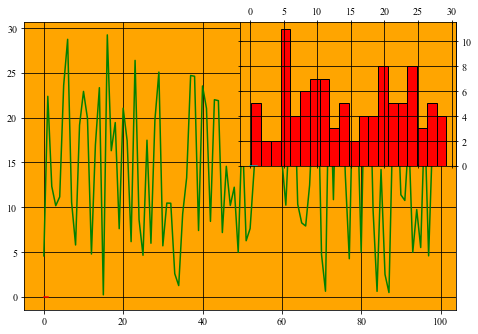

In [ ]:
fig = plt.figure()

N = 100
x = np.arange(N)
y = np.random.random(N)*30.

# Область ax1 нарисуется первой
ax1 = fig.add_axes([0.,0.,1.0,1.0]) 
# Область ax2 перекроет область ax1 и закроет её часть
ax2 = fig.add_axes([0.5,0.5,0.5,0.5])

rect0 = [0.0, 0.0]

ax1.plot(rect0, 'r')
ax1.plot(x, y, 'green')

ax2.plot(rect0, 'c')
ax2.hist(y, 20, edgecolor='k', facecolor='r')
ax2.tick_params(axis='y', which='major', direction='inout',
                left=True, right=True, labelleft=False, labelright=True)
ax2.tick_params(axis='x', which='major', direction='inout',
                bottom=True, top=True, labelbottom=False, labeltop=True)

print (u'Область 1', ax1)
print (type(ax1))
print (u'Область 2',ax2)

for ax in fig.axes:
    ax.grid(True)
    
save('pic_7_2_2', fmt='png')
save('pic_7_2_2', fmt='pdf')

plt.show()

### 7.3 Автоматизированное создание мультиокон

Для создания множества областей удобно не просто добавлять их на рисунок последовательно, по одному, а всего одной строчкой разбить рисунок на несколько областей рисования. Это позволяет сделать, например, метод `plt.subplots()`, который требует указать число строк и столбцов создаваемой таблицы каждая из ячеек которой и есть объект-экземпляр subplots. Метод возвращает объект типа figure и массив из созданных subplots. Их можно перебрать в цикле "в лоб", но лучше пользоваться перебором из списка fig.axes, куда автоматически добавляются все области рисования текущего рисунка fig. 

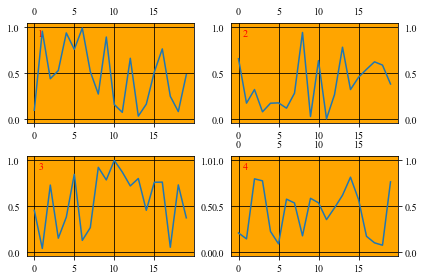

In [ ]:
fig, subplots = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True)

x = np.arange(20)

i = -1
for ax in fig.axes:
    i += 1
    y = np.random.rand(np.size(x))
    ax.grid(True)
    ax.text(0.5, 0.9, str(i+1), color='red')
    ax.plot(x, y)
    if((i+1)%2 == 0):
        ax.tick_params(axis='y', labelleft='off', labelright='on', left=False, right=True)
    if((i==0) or (i==1)):
        ax.tick_params(axis='x', labelbottom='off', labeltop='off', left=False, right=True)     
    if((i==1) or (i==2)):
        ax.tick_params(axis='y', labelleft='off', labelright='off', left=False, right=False)
    if(i==3):
        ax.tick_params(axis='x', labelbottom='off', labeltop='off')        
    if(i==1):
        ax.tick_params(axis='x', labelbottom='off', labeltop='on')
    if(i==0):
        ax.tick_params(axis='y', left=True, right=False)

# Параметры подобраны эмпирически, на глаз
plt.tight_layout(h_pad = -0.15, w_pad = -0.2)

save('pic_7_3', fmt='png')
save('pic_7_3', fmt='pdf')

plt.show()

### 7.4 Мультиокна разных размеров. Gridspec

Методы `fig.add_subplot()` и `plt.subplots()` позволяют разбить рисунок на равные по размерам области и в этом состоит одно из их основных преимуществ. Оъединить ячейки subplots в более сложные конструкции позволяет метод `plt.subplot2grid()`, который также именуется как метод Gridspec.

Этот метод позволяет настроить индивидуальные размеры создаваемых subplots. Основной принцип метода - объединения ячеек в более длинные или высокие плитки-области. Таким образом, экземпляры subplots могут быть разных форм и размеров.

Создание ячеек осуществляется при помощи метода `subplot2grid()`, которому необходимо задать число строк и столбцов в виде кортежа, а также расположение ячеек в виде кортежа номеров от 0 до максимального числа ячеек N-1. То есть для создания таблицы 2x2 нужно задать размер (2,2) и расположение в пределах от (0,0) до (1,1).

<class 'matplotlib.axes._subplots.AxesSubplot'>


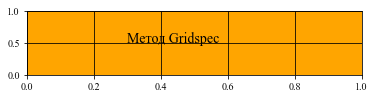

In [ ]:
# Пример 7.4.1

import matplotlib.pyplot as plt


# 3,3 - три столбца и три ячейки

ax = plt.subplot2grid((3, 1), (0, 0))

print( type(ax))

# это запись эквивалентна более детальной записи

gs = gridspec.GridSpec(3, 1)

ax = plt.subplot(gs[0, 0])
ax.grid(True)
# Положение текста задано в относительных координатах
ax.text(0.3, 0.5, u'Метод Gridspec', fontsize=14, transform=ax.transAxes)

save('pic_7_4_1', fmt='png')
save('pic_7_4_1', fmt='pdf')

plt.show()

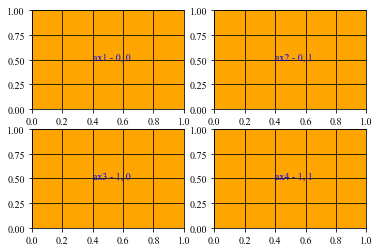

In [ ]:
# Создание нескольких областей. Пример задания сетки-таблицы (grid) и расположения (loc)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure()

ax1 = plt.subplot2grid((2,2), (0, 0))
ax2 = plt.subplot2grid((2,2), (0, 1))
ax3 = plt.subplot2grid((2,2), (1, 0))
ax4 = plt.subplot2grid((2,2), (1, 1))

i = -1
jj = [0, 0, 1, 1]
kk = [0, 1, 0, 1]
for ax in fig.axes:
    i += 1
    stext = 'ax%d - %d, %d' % (i+1, jj[i], kk[i])
    ax.text(0.4, 0.5, stext, color='b')
    ax.grid(True)
    
save('pic_7_4_1', fmt='png')
save('pic_7_4_1', fmt='pdf')

plt.show()

Главным преимуществом данного метода является то, что получаемые subplots могут быть разных форм и размеров. При этом конфигурация задаётся в виде объединения ячеек, а не через указание явных границ, как это можно было бы сделать с помощью метода `ax.add_axes()`.

Для объединения ячеек при создании таблицы-сетки нужно добавить следующие параметры в метод subplot2grid:

* **colspan** - объединить столбы;

* **rowspan** - объединить строки.

Значение соответствующих параметров показывает сколько ячеек сетки объединить. Причём отсчёт ведётся от точки локализации ячейки включая её. Если нужно объединить и столбцы и строки, то указываются оба параметра одновременно.

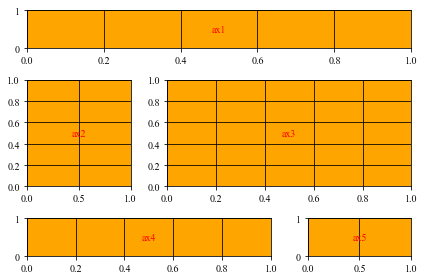

In [ ]:
fig = plt.figure()

# Сетка состоит из 4 строк и 3 столбцов. Первая ячейка имеет номер (0,0),
# а последняя - (3,2)
egrid = (4,3)
ax1 = plt.subplot2grid(egrid, (0, 0), colspan=3)
ax2 = plt.subplot2grid(egrid, (1, 0), rowspan=2)
ax3 = plt.subplot2grid(egrid, (1, 1), rowspan=2, colspan=2)
ax4 = plt.subplot2grid(egrid, (3, 0), colspan=2)
ax5 = plt.subplot2grid(egrid, (3, 2))

for i, ax in enumerate(fig.axes):
        ax.text(0.5, 0.5, "ax%d" % (i+1), va="center", ha="center", 
                color='red', transform=ax.transAxes)
        ax.grid(True)

# Настройка расстояний между границами созданных subplots
plt.tight_layout()

save('pic_7_4_3', fmt='png')
save('pic_7_4_3', fmt='pdf')

plt.show()

### 7.5 "Главное - чтобы костюмчик сидел!"

Создание мультиоконных рисунков - это всегда компромис между удобством представления информации (всё в одном месте) и читаемостью самого рисунка. Перегрузить рисунок используя вышеперечисленные методы проще простого, если общее число ячеек превысило число 4. Поэтому злоупотреблять мультиокнами не нужно. Разместить несколько графиков на рисунке - пожалуйста! Но если на каждой из 4 областей будет по 3-4 графика, то это уже перебор. Учитесь выделять главное, то, что вы точно хотите показать, что выгодно и беспроигрышно подтверждает ваши тезисы.

Немаловажным является также ясность подписей. При создании рисунка со множеством диаграмм подписи к осям становятся либо нечитаемыми, либо выглядят неопрятно. На слайде или лекции это куда ни шло, но в научный журнал такое не пошлёшь! Нужно следить за читаемостью легенд и размещать их так, чтобы они не мешали чтение рисунка. При этом не нужно дублировать информацию. Если графики расположены один под одним и у них единая шкала по оси абсцисс, то на некоторых областях можно убрать подписи оставив вспомогательную сетку.

Одним словом нужно уметь двигать созданные тем или иным способом области, если подписи к ним или к осям вылазят или перекрываются. Самым простым является метод **`plt.tight_layout()`**. Он самостоятельно подбирает параметры рисунка так, чтобы все объекты на нём выглядели хорошо. К сожалению, он плохо ладит одновременно с методом `fig.add_axes()`.

Метод **`fig.subplots_adjust()`** позволяет обновить SubplotParams (по умолчанию определяет их из rcParams, если ни один аргумент метода не был определён) и переопределить параметры местоположения subplots. Также можно напрямую определять параметры расположения subplots через **`matplotlib.rcParams`**.

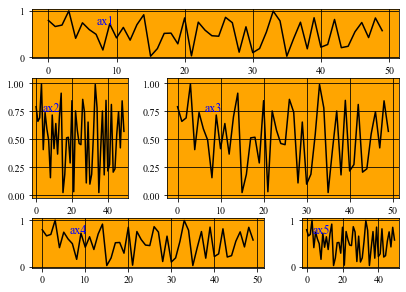

In [ ]:
# Левая граница subplots на рисунке
rcParams['figure.subplot.left'] = 0.1
# Правая граница subplots на рисунке
rcParams['figure.subplot.right'] = 0.95
# Нижняя граница subplots на рисунке
rcParams['figure.subplot.bottom'] = 0.05
# Верхняя граница subplots на рисунке
rcParams['figure.subplot.top'] = 0.95

# Изменение параметров wspace и hspace методом rcParams

# Общая высота (вертикаль), выделенная для свободного пространства между subplots
rcParams['figure.subplot.hspace'] = 0.2
# Общая ширина (горизонталь), выделенная для свободного пространства между subplots
rcParams['figure.subplot.wspace'] = 0.2

N = 50
x = np.arange(N)
y = np.random.rand(np.size(x))

fig = plt.figure()

# Сетка состоит из 4 строк и 3 столбцов. Первая ячейка имеет номер (0,0),
# а последняя - (3,2)
egrid = (4,3)
ax1 = plt.subplot2grid(egrid, (0, 0), colspan=3)
ax2 = plt.subplot2grid(egrid, (1, 0), rowspan=2)
ax3 = plt.subplot2grid(egrid, (1, 1), rowspan=2, colspan=2)
ax4 = plt.subplot2grid(egrid, (3, 0), colspan=2)
ax5 = plt.subplot2grid(egrid, (3, 2))

for i, ax in enumerate(fig.axes):
        ax.plot(x, y, 'k')
        ax.text(0.2, 0.75, "ax%d" % (i+1), va="center", ha="center", 
                color='blue', transform=ax.transAxes, fontsize='large')
        ax.grid(True)

# Изменение параметров wspace и hspace методом fig.subplots_adjust()
fig.subplots_adjust(wspace=0.4, hspace=0.4)

save('pic_7_5', fmt='png')
save('pic_7_5', fmt='pdf')

plt.show()

## 8. Координатные оси Axis

Данные, насённые тем или иным графическим способомна рисунок Figure и область рисования Axes, не представляют особого интереса для научного анализа, пока они не привязаны к какой-либо системе координат. При создании экземпляра axes на вновь созданной области рисования автоматически задаётся прямоугольная система координат, если не указаны атрибуты polar или projection. Подробнее про области рисования с другими системами координат смотри главу "Графики в полярных координатах".

Система координат определяет вид координатных осей. По умолчанию задаётся прямоугольная система координат: ось абсцисс (ось "OX") и ось ординат (ось "OY"). В полярной системе координат координатными осями являются радиус и угол наклона, что выражается в виде своеобразного тригонометрического круга.

Для хранения и форматирования каждой координатной оси и существует контейнер Axis.


### 8.1 Контейнер Axis

Axis (не путать с областями рисования Axes) - это третья "матрёшка" (после Figure и Axes) или контейнер в matplotlib, которая привязана к области рисования Axes и на которой располагаются деления осей (ticks), подписи делений (tick labels) и подписи осей (axis labels).

Координатные оси являются экземплярами класса matplotlib.axis.Axis.

Любая область рисования Axes содержит два особых Artist-контейнера: XAxis и YAxis. Они отвечают за отрисовку делений (ticks) и подписей (labels) координатных осей, которые хранятся как экземпляры в переменных xaxis и yaxis. Чтобы обратиться к экземпляру axis, отвечающему за ось ординат, нужно обратиться к контейнеру yaxis соответствующей области рисования ax. Причём запись "`yax=ax.get_yaxis()`" идентична записи "`yax=ax.yaxis`".

Каждый экземпляр axis содержит атрибут подписей (label) координатной оси и список главных (major ticks) и вспомогательных (minor ticks) делений, а также является хранилищем для экземпляров делений (ticks). Деления - это экземпляры класса `matplotlib.axis.Tick`, которые визуализируют деления (их размер, цвет, толщину и т.д.) и подписи к ним. Деления создаются динамически исходя из области изменения переданных данных. В результате на координатной оси появляются и хранятся экземпляры классов `matplotlib.axis.XTick` и `matplotlib.axis.YTick`. Они родственны классу `matplotlib.axis.Tick`. Хотя все графические примитивы, с помощью которых создаётся облик координатной оси содержатся в делениях ticks, о которых будет показано в следующей главе, у экземпляров axis есть средства для управления линиями делений (tick lines), подписями делений (tick labels), а также местоположением делений (tick locations).

Major X-ticks locations: [-20.   0.  20.  40.  60.  80. 100. 120.]
Major X-ticks labels: <a list of 8 Text major ticklabel objects>
Major X-ticks tick lines: <a list of 16 Line2D ticklines objects>


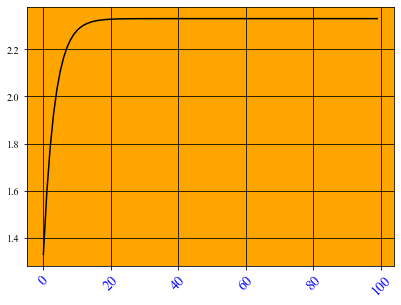

In [ ]:
fig = plt.figure()

ax = fig.add_subplot(111)

x = np.arange(100)
y = -np.exp(-0.3*x) + 2.33

ax.plot(x, y, 'k')

xax = ax.xaxis   # или xax = ax.get_xaxis()

xlocs = xax.get_ticklocs()
print ('Major X-ticks locations:', xlocs)
xlabels = xax.get_ticklabels()
print ('Major X-ticks labels:', xlabels)
xlines = xax.get_ticklines()
print ('Major X-ticks tick lines:', xlines)

# Линии вспомогательной сетки (главные деления) только по оси абсцисс
xax.grid(True)

for label in xlabels:
    # цвет подписи деленений оси OX
    label.set_color('blue')
    # поворот подписей деленений оси OX 
    label.set_rotation(45)
    # размер шрифта подписей делений оси OX 
    label.set_fontsize(14)

save('pic_8_1_1', fmt='png')
save('pic_8_1_1', fmt='pdf')
    
plt.show()

### 8.2 Главные и вспомогательные деления

В matplotlib деления на координатной оси могут быть главными (major ticks) или вспомогательными (minor ticks). По умолчанию наносятся главные деления, к ним привязывается нанесение вспомогательной сетки grid, за которую отвечает параметр axes.grid.which': u'major' из rcParams. Работа со вспомогательными делениями ничем не отличается от работы с главными делениями: используются те же методы, но явно указывается тип делений через определённый атрибут. Обычно этот атрибут называется which (принимает значения 'major'/'minor') или булевый атрибут minor.

Ниже представлен список некоторых методов Axis. Они применяются к экземплярам xaxis или yaxis. Так как при работе с атрибутами поддерживается идеология "set-get", то списке указаны методы только с приставкой "set_". Для получения значений атрибутов какой-либо характеристики, нужно в методе заменить приставку "set" на "get": set_scale -> get_scale; get_data_interval -> set_data_interval и так далее.

----------------------------------------------------------

Вспомогательный метод -> Описание

----------------------------------------------------------

+ **set_scale** -> определяет характер изменений значений на оси: линейный 'linear' (по умолчанию) или 'log' логарифмический;

+ **set_view_interval** -> экземпляр интервала области изменения отображений по оси axis;

+ **set_data_interval** -> экземпляр интервала области изменения данных по оси axis;

+ **set_gridlines** -> список линий сетки для Axis;

+ **set_label** -> подпись оси, экземпляр Text;

+ **set_ticklabels** -> подписи делений, список экземпляров Text. Тип делений определяет параметр minor=True/False;

+ **set_ticklines** -> конфигурация делений, список экземпляров Line2D. Тип делений определяет параметр minor=True/False;

+ **set_ticklocs** -> положение делений. Тип делений определяет параметр minor=True/False;

+ **set_major_locator** -> экземпляр matplotlib.ticker.Locator для главных (major) делений;

+ **set_major_formatter** -> экземпляр matplotlib.ticker.Formatter для главных делений;

+ **set_major_ticks** -> список экземпляров Tick для главных делений;

+ **set_minor_locator** -> экземпляр matplotlib.ticker.Locator для вспомгательных (minor) делений;

+ **set_minor_formatter** -> экземпляр matplotlib.ticker.Formatter для вспомогательных делений;

+ **set_minor_ticks** -> список экземпляров Tick для вспомогательных делений;

+ **grid** -> определяет будет ли отображаться линии сетки для главной или вспомогательных делений (параметр which='major'/'minor');

----------------------------------------------------------


Major X-ticks tick lines: <a list of 16 Line2D ticklines objects>
Major X-ticks location: [-20.   0.  20.  40.  60.  80. 100. 120.]
Major X-ticks labels: <a list of 8 Text major ticklabel objects>
Major X-ticks tick lines: <a list of 0 Line2D ticklines objects>
Minor X-ticks location: []
Minor X-ticks labels: <a list of 0 Text minor ticklabel objects>
----------------------------
Тип изменения оси: linear 

Область изменения отображения данных: [ -4.95 103.95] 

Область изменения отображения данных: [ 0. 99.] 

Линии сетки: <a list of 8 Line2D gridline objects> 

Подпись оси: Text(0.5, 0, '') 

Подписи делений: <a list of 8 Text major ticklabel objects> 

Линии делений: <a list of 16 Line2D ticklines objects> 

Расположение делений: [-20.   0.  20.  40.  60.  80. 100. 120.] 

locator главных делений: <matplotlib.ticker.AutoLocator object at 0x0000021FD6F19D88> 

formatter главных делений: <matplotlib.ticker.ScalarFormatter object at 0x0000021FD5540C48> 

Список главных делений оси:


l

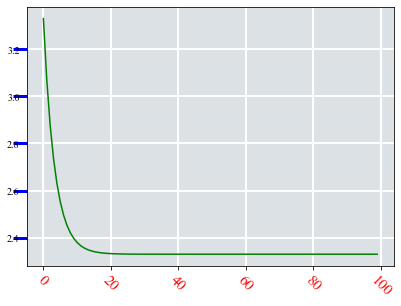

In [ ]:
fig = plt.figure()

ax = fig.add_subplot(111)
rect = ax.patch
rect.set_facecolor('lightslategray')
rect.set_alpha(0.25)

x = np.arange(100)
y = np.exp(-0.3*x) + 2.33

ax.plot(x, y, 'green')

xax = ax.xaxis   # экземпляр xaxis

print ('Major X-ticks tick lines:', xax.get_ticklines())
print ('Major X-ticks location:', xax.get_ticklocs())
print ('Major X-ticks labels:', xax.get_ticklabels())

print ('Major X-ticks tick lines:', xax.get_ticklines(minor=True))
print ('Minor X-ticks location:', xax.get_ticklocs(minor=True))
print ('Minor X-ticks labels:', xax.get_ticklabels(minor=True))

# вспомогательная сетка для главных делений 
ax.grid(True, which=u'major', color='w', linewidth=2., linestyle='solid')

# вспомогательная сетка для вспомогательных делений 
ax.grid(True, which=u'minor', color='b')

# Ось абсцисс
for label in ax.xaxis.get_ticklabels():
    # label - это экземпляр текста Text
    label.set_color('red')
    label.set_rotation(-45)
    label.set_fontsize(15)

# Ось ориднат
for line in ax.yaxis.get_ticklines():
    # line - это экземпляр плоской линии Line2D
    line.set_color('blue')   # задаём цвет линии деления
    line.set_markersize(14)   # задаём длину линии деления
    line.set_markeredgewidth(3)   # задаём толщину линии деления

print ('----------------------------')
print (u'Тип изменения оси:', xax.get_scale(), '\n')
print (u'Область изменения отображения данных:', xax.get_view_interval(), '\n')
print (u'Область изменения отображения данных:', xax.get_data_interval(), '\n')
print (u'Линии сетки:', xax.get_gridlines(), '\n')
print (u'Подпись оси:', xax.get_label(), '\n')
print (u'Подписи делений:', xax.get_ticklabels(), '\n')
print (u'Линии делений:', xax.get_ticklines(), '\n')
print (u'Расположение делений:', xax.get_ticklocs(), '\n')
print (u'locator главных делений:', xax.get_major_locator(), '\n')
print (u'formatter главных делений:', xax.get_major_formatter(), '\n')
print (u'Список главных делений оси:', *xax.get_major_ticks(), '\n', sep='\n')
print (u'locator вспомогательных делений:\n', xax.get_minor_locator(), '\n')
print (u'formatter вспомогательных делений:', xax.get_minor_formatter(), '\n')
print (u'Список вспомогательных делений оси:', xax.get_minor_ticks(), '\n')
print ('----------------------------')

save('pic_8_2', fmt='png')
save('pic_8_2', fmt='pdf')

plt.show()

### 8.3 Настройка координатной оси

Одну и ту же настройку координатных осей (тип, частота, подписи делений, их цвет, шрифт и размер, а также положение и многое другое) можно провести разными способами. Так как в экземпляре Axes всегда есть выход на экземпляры Axis (XAxis и YAxis), то и большинстов удобных для пользователя методов настройки координатной оси привязаны к экземплярам Axes. 

Одним из способов привести координатную ось в нужный пользователю вид заключается в применении методов "set-get" для объектов типа Axes:

+ **`ax.get_xticks()`** - получить список местоположения делений (по умолчанию главных) на оси абсцисс;

+ **`ax.set_xticklabels()`** - задать значения подписей для текущего местоположения делений (по умолчанию главных) на оси абсцисс;

+ **`ax.get_yticks()`** - получить список местоположения делений (по умолчанию главных) на оси ординат;

+ **`ax.set_yticklabels()`** - задать значения подписей для текущего местоположения делений (по умолчанию главных) на оси ординат.

Методы `ticklabels()` принимают множество параметров, с помощью которых, можно настроить внешний вид (цвет, поворот вокруг оси, шрифт, стиль шрифта и т.д.) текстовой подписи. Любая подпись - это экземпляр Text и работать с ним нужно соответствующими методами.

Xticks: [-6. -4. -2.  0.  2.  4.  6.]
Yticks: [2. 3. 4. 5. 6. 7. 8.]
Yticklabels: <class 'matplotlib.cbook.silent_list'>
Каждый label - это <class 'matplotlib.text.Text'>


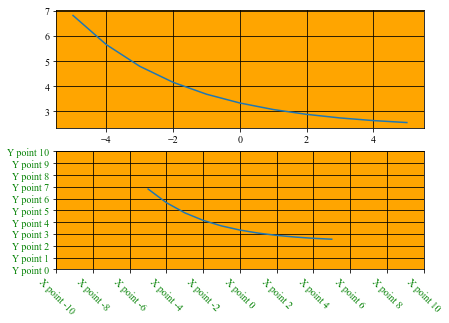

In [ ]:
x = np.arange(-5, 6)
y = np.exp(-0.3*x) + 2.33

fig = plt.figure()
ax1 = fig.add_subplot(211)
ax1.plot(x, y)
ax1.grid(True)

ax2 = fig.add_subplot(212)
ax2.plot(x, y)
ax2.grid(True)

xticks = ax2.get_xticks()
yticks = ax2.get_yticks()

xx = np.arange(-10, 11, 2)
yy = np.arange(0, 11)

print('Xticks:', xticks)
print('Yticks:', yticks)

xlabels = []
ylabels = []
for i in xx:
    xlabels.append('X point %d' % i)

for j in yy:
    ylabels.append('Y point %d' % j)
    
ax2.set_xticks(xx)
ax2.set_yticks(yy)
ax2.set_yticklabels(ylabels, color='green')
ax2.set_xticklabels(xlabels, color='green', rotation=315)

yticklabels = ax2.get_yticklabels()
print('Yticklabels: %s' % type(yticklabels))
print('Каждый label - это %s' % (type(yticklabels[0])))

save('pic_8_3_1', fmt='png')
save('pic_8_3_1', fmt='pdf')

plt.show()

Для удобства пользователей многие методы настройки, требующие работы непосредственно с экземплярами Ticks, были продублированы в виде заскриптованных методов для объектов Axes. Далее показаны основные приёмы с помощью которых можно работать с координатными осями.

Для облегчения доступа к настройкам делений, требующим работы непосредственно с экземплярами Ticks, в matplotlib был сделан метод `ax.tick_params`, который позволяет быстро и просто настраивать расположение и отображение делений координатных осей и их подписей. Ниже приводится список атрибутов данного метода:

1. **axis** : ['x' | 'y' | 'both'] - экземпляр Axis на котором находятся деления; по умолчанию 'both';

2. **reset** : [True | False] - если True, то значения всех параметров сбрасываются на значения по умолчанию. По умолчанию равен False;

3. **which** : ['major' | 'minor' | 'both'] - определяет принадлежность к типу делений. По умолчанию 'major';

4. **direction** : ['in' | 'out' | 'inout'] - определяет направление делений (внутрь, вовне или и снаружи и внутри);

5. **length** - длиная деления в точках (points);

6. **width** - ширина деления в точках (points);

7. **color** - цвет деления. Возможен любой цвет, приемлимый в matplotlib;

8. **pad** - расстояние в точках между делением и подписью к нему;

9. **labelsize** - размер шрифта подписи деления в виде строки (например, 'large') или числа;

10. **labelcolor** - цвет подписи деления. Возможен любой цвет, приемлимый в matplotlib;

11. **colors** - изменяет цвет деления и цвет подписи деления на одно значение. Возможен любой цвет, приемлимый в matplotlib;

12. **zorder** - zorder деления и подписи деления;

13. **bottom, top, left, right** : [bool | 'on' | 'off'] - каждый из параметров контролирует отображение делений на соответствующей оси;

14. **labelbottom, labeltop, labelleft, labelright** : [bool | 'on' | 'off'] - каждый из параметров контролирует отображение подписи делений на соответствующей оси.

Правда метод tick_params не имеет параметра rotation. Чтобы повернуть подписи делений, нужно воспользоваться иным способом, например указать этот параметр явно через метод `ax.set_xticklabels`.

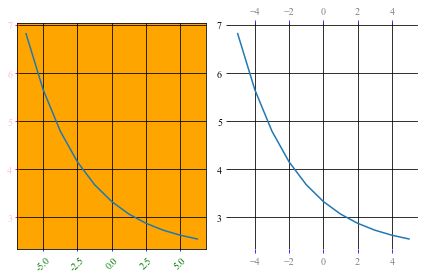

In [ ]:
x = np.arange(-5, 6)
y = np.exp(-0.3*x) + 2.33

fig = plt.figure()
ax1 = fig.add_subplot(121)
ax1.plot(x, y)
ax1.grid(True)

# Настройка оси главных делений для оси абсцисс 
ax1.tick_params(axis='x', which='major', direction='inout',
                bottom=True, top=False, left=True, right=False, 
                color='b', labelcolor='g',
                labelbottom=True, labeltop=False, labelleft=True, labelright=False)
# Настройка оси главных делений для оси ординат 
ax1.tick_params(axis='y', which='major', direction='inout',
                bottom=True, top=False, left=True, right=False, 
                color='r', labelcolor='pink',
                labelbottom=True, labeltop=False, labelleft=True, labelright=False)

# Метод tick_params не имеет параметра rotation. Поэтому чтобы повернуть подписи
# нужно сделать это явно через метод set_xticklabels
xticks = ax1.get_xticks()
ax1.set_xticklabels(xticks, rotation=45)

ax2 = fig.add_subplot(122, frameon=False)
ax2.plot(x, y)
ax2.grid(True)

ax2.tick_params(axis='x', which='major', direction='out',
                bottom=True, top=True, left=True, right=True, 
                color='blue', labelcolor='grey',
                labelbottom=True, labeltop=True, labelleft=True, labelright=True)
ax2.tick_params(axis='x', which='minor', direction='in',
                bottom=True, top=False, left=True, right=False, 
                color='r', labelcolor='pink',
                labelbottom=True, labeltop=False, labelleft=True, labelright=False)

plt.tight_layout()

save('pic_8_3_2', fmt='png')
save('pic_8_3_2', fmt='pdf')

plt.show()

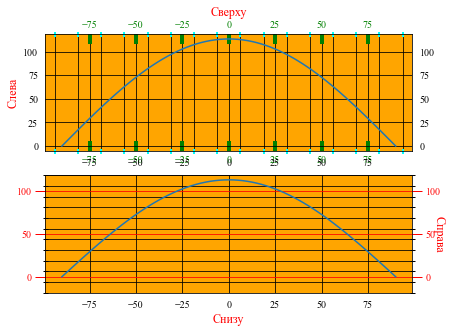

In [ ]:
x = np.arange(-90, 92.5 , 2.5)
y = 113.3*np.cos(x*np.pi/180.)
z = 113.3*np.sin(x*np.pi/180.)

fig = plt.figure()

ax = fig.add_subplot(211)
ax.plot(x, y)

ax.tick_params(axis='x', which='major', 
               labelleft='off', labelright='off', labeltop='on', labelbottom='on', 
               bottom=True, top=True,
               direction='in', length=10, width=4, colors='g')

old_major = ax.get_xticks()
N = 0.25
lag = (old_major[1] - old_major[0])*N
new_minor = np.arange(old_major[0] + lag, old_major[-1], 2*lag)
ax.set_xticks(new_minor, minor = True)

ax.tick_params(axis='x', which='minor', 
               labeltop='on', labelbottom='on', 
               bottom=True, top=True,
               direction='inout', length=5, width=2, colors='cyan')

ax.tick_params(axis='y', 
               labelleft='off', labelright='off',
               left=False, right=False)

ax.grid(True, which='major')
ax.grid(True, which='minor')

ax.yaxis.set_label_position('left')
ax.set_ylabel(u'Слева')
ax.xaxis.set_label_position('top')
ax.set_xlabel(u'Сверху')

# ************************************************
ax = fig.add_subplot(212)

ax.plot(x, y)
ax.tick_params(axis='both', reset=True)

ax.tick_params(axis='y', which='major', 
               labelleft='on', labelright='on', 
               left=True, right=True,
               direction='out', length=10, width=1., colors='r')

old_major = ax.get_yticks()
N = 0.25
lag = (old_major[1] - old_major[0])*N
new_minor = np.arange(old_major[0] + lag, old_major[-1], 2*lag)
ax.set_yticks(new_minor, minor = True)

ax.tick_params(axis='y', which='minor', 
               labelleft='on', labelright='on', 
               left=True, right=True,
               direction='inout', length=5, width=1., colors='k')

ax.tick_params(axis='x',
               labeltop='off', labelbottom='off', 
               bottom=False, top=False)

ax.yaxis.set_label_position('right')
ax.set_ylabel(u'Справа', rotation=270)

ax.xaxis.set_label_position('bottom')
ax.set_xlabel(u'Снизу')

ax.grid(True, axis='y', which='major', color='red')
ax.grid(True, axis='y', which='minor', color='k')

save('pic_8_3_3', fmt='png')
save('pic_8_3_3', fmt='pdf')

plt.show()

## 9. Деления координатной оси Ticks

Деления (ticks) неотделимы от координатной оси на которой они находятся. Однако свойства самих делений (цвет, длина, толщина и др.), и их подписей (кегль, поворот, цвет шрифта, шрифт и др.), а также связанные с ними линии вспомогательной сетки grid, удобно хранить в отдельном хранилище-контейнере Ticks, а не в контейнере Axis. Повторюсь, что эти вещи очень связаны и одно в отрыве от другого теряет смысл. Тем более, что для удобства пользователей разработчики сделали множество методов для работы с делениями из контейнеров более высокого уровня (Axes, Axis). 

### 9.1 Контейнер Ticks

Контейнер `matplotlib.axis.Tick` - это последний и самый низкоуровневый из Artists-контейнеров, самая маленькая "матрёшка". Он содержит экземпляры делений (ticks), линий вспомогательной сетки (grid lines) и подписей (labels) для верхних (upper ticks) и нижних делений (lower ticks). К каждому из них есть прямой доступ как к одному из атрибуту экземпляра Tick. Также контейнер существуют логические переменные с помощью которых можно определить с какой стороны будут нанесены подписи и деления: для оси ординат справа/слева, а для оси абсцисс - сверху/снизу в прямоугольной системе координат.

Для работы непросредственно с экземпляром Tick, необходимо "спуститься" к нему с более высоких контейнеров-уровней. 

> Axes - Axis(YAxis) - методы "set-get" -> `ax.yaxis.get_major_ticks()`

Для такого объекта определены следующие атрибуты:

------------------------------------------------------------------------

Атрибут Tick -> Описание

------------------------------------------------------------------------

+ **tick1line** - экземпляр Line2D;

+ **tick2line** - экземпляр Line2D;

+ **gridline** - экземпляр Line2D;

+ **label1** - экземпляр Text;

+ **label2** - экземпляр Text;

+ **gridline.set_visible** - логическая переменная, разрешающая рисовать tickline;

+ **label1.set_visible** - логическая переменная, разрешающая рисовать tick label;

+ **label2.set_visible** - логическая переменная, разрешающая рисовать tick label.

------------------------------------------------------------------------

Атрибуты с номером 1 - это стандартно отображаемые деления, которые располагаются слева и/или снизу.

Атрибуты с номером 2 - соответственно справа и/или снизу.


Major ticks on Y-axis <class 'matplotlib.axis.YTick'>
Major ticks on Y-axis <class 'matplotlib.axis.YTick'>
Major ticks on Y-axis <class 'matplotlib.axis.YTick'>
Major ticks on Y-axis <class 'matplotlib.axis.YTick'>
Major ticks on Y-axis <class 'matplotlib.axis.YTick'>
Major ticks on Y-axis <class 'matplotlib.axis.YTick'>
Major ticks on Y-axis <class 'matplotlib.axis.YTick'>
Major ticks on Y-axis <class 'matplotlib.axis.YTick'>
Major ticks on X-axis <class 'matplotlib.axis.XTick'>
Major ticks on X-axis <class 'matplotlib.axis.XTick'>
Major ticks on X-axis <class 'matplotlib.axis.XTick'>
Major ticks on X-axis <class 'matplotlib.axis.XTick'>
Major ticks on X-axis <class 'matplotlib.axis.XTick'>
Major ticks on X-axis <class 'matplotlib.axis.XTick'>
Major ticks on X-axis <class 'matplotlib.axis.XTick'>
Major ticks on X-axis <class 'matplotlib.axis.XTick'>
Major ticks on X-axis <class 'matplotlib.axis.XTick'>


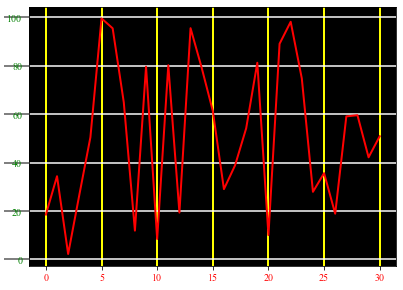

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

rect = ax.patch
rect.set_facecolor('k')

N = 31
x = np.arange(N)
y = 100*np.random.rand(N)

ax.plot(x, y, color='red', linewidth=2.0)

#formatter = mpl.ticker.FormatStrFormatter(u'%.2f руб.')
#ax.yaxis.set_major_formatter(formatter)

for tick in ax.yaxis.get_major_ticks():
    print ('Major ticks on Y-axis %s' % type(tick))
    tick.label1.set_visible = True
    tick.label1.set_color('green')
    tick.label2.set_visible = True
    tick.label2.set_color('blue')
    # серые деления на оси ОY слева
    tick.tick1line.set_color('grey')
    tick.tick1line.set_markeredgewidth(2)
    tick.tick1line.set_markersize(25)
    # линии вспомогательной сетки для оси OX
    tick.gridline.set_visible = True
    tick.gridline.set_color('white')
    tick.gridline.set_linewidth(1.5)
    
for tick in ax.xaxis.get_major_ticks():
    print ('Major ticks on X-axis %s' % type(tick))
    tick.label1.set_visible = True
    tick.label1.set_color('red')
    tick.label2.set_visible = True
    tick.label2.set_color('orange')
    # розовые деления на оси ОX сверху
    tick.tick2line.set_color('pink')
    tick.tick2line.set_markeredgewidth(2)
    tick.tick2line.set_markersize(25)
    # линии вспомогательной сетки для оси OY
    tick.gridline.set_visible = True
    tick.gridline.set_color('yellow')
    tick.gridline.set_linewidth(2.)

save('pic_9_1', fmt='png')
save('pic_9_1', fmt='pdf')
    
plt.show()

### 9.2 Locator и Formatter

Деления могут быть как главными (major ticks), так и вспомогательными (minor ticks). Работа с делениями в обоих случаях одинаковая.

Однако, если главные деления будут автоматически созданы при вызове графической команды (например `ax.plot()` или `ax.hist()`), и с ними, соответственно, можно работать c помощью `ax.xaxis.get_major_ticks()` или `ax.yaxis.get_major_ticks()`, то вспомогательные деления необходимо задавать вручную. Удобнее всего это делать с помощью методов Formatter и Locator.

Методы Locator и Formatter относятся к модулю `matplotlib.ticker`. Этот модуль содержит классы, позволяющие наиболее полно определять форматирование и местоположение делений. Это самый низкоуровневый способ форматирования делений на координатных осях. 

Контейнеры коодинатных осей XAxis и YAxis имеют специальные методы для работы с объектами типа Formatter: `.set_major/minor_locator()` и `.set_major/minor_formatter()`. Например:

+ `xax.set_major_locator()`;

+ `xax.set_major_formatter()`;

+ `yax.set_minor_locator()`;

+ `yax.set_minor_formatter()`.

В качестве входящих данных данным методам нужно передать какой-либо экземпляр класса из модуля `matplotlib.ticker`, например, `matplotlib.ticker.MultipleLocator`.

In [ ]:
majorLocator   = MultipleLocator(5)
majorFormatter = FormatStrFormatter('%d')

print(type(majorLocator))
print(type(majorFormatter))

<class 'matplotlib.ticker.MultipleLocator'>
<class 'matplotlib.ticker.FormatStrFormatter'>


Класс Locator является базовым классом для всех производных классов-локаторов, отвечающих за расположение делений. Локаторы работают с автомасштабированием в пределах области изменения данных, и исходя из этого определяют положение делений на оси. Одним из наиболее удобных является полуавтоматический локатор MultipleLocator. В качестве входящих данных он принимает целое число, например 10, и самостоятельно подбирает пределы изменений на оси и располагает деления в местах, кратных заданному числу. 

Другой пример - субкласс AutoMinorLocator(). Он позволяет автоматически определить положение вспомогательных делений. В качестве входящего параметра даётся целое число n - число промежутков, разделённых вспомогательными делениями, между двумя главными делениями. Это один их самых простых способов задать положение и значения вспомогательных делений. Форматирование подписей к таким делениям (их строковое представление), легче всего осуществить с помощью методов-форматеров. Подробнее о субклассах Locator смотри в электронных материалах.

Класс Formatter является базовым для всех производных классов-форматеров, отвечающих за форматирование делений. Форматеры в качестве входящих данных принимают строку формата, например "%d", которая применяется к подписи каждого деления. Разные субклассы предоставляют разный функционал. Так субкласс NullFormatter() позволяет скрыть все подписи на выбранной оси. Подробнее о субклассах Formatter смотри в электронных материалах.

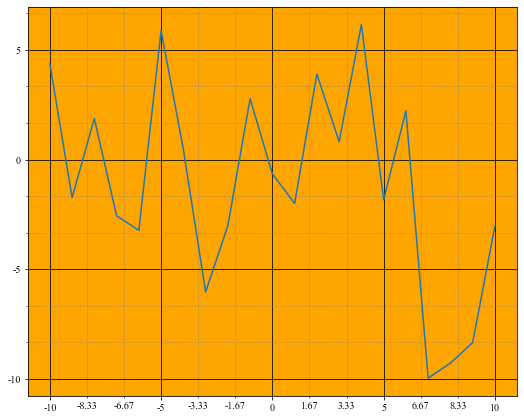

In [ ]:
majorLocator   = MultipleLocator(5)
# Автоматический подбор промежуточных делений. Количество созданных делений равно n-1
minorLocator   = AutoMinorLocator(n=3)   

majorFormatter = FormatStrFormatter('%d')
minorFormatter = FormatStrFormatter('%.2f')

N = 10
x = np.arange(-N, N+1, 1) 
y = (np.random.random(len(x))*2.-1)*N

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

ax.plot(x, y)

xax = ax.xaxis
yax = ax.yaxis

xax.set_major_locator(majorLocator)
xax.set_major_formatter(majorFormatter)
yax.set_major_locator(majorLocator)
yax.set_major_formatter(majorFormatter)

xax.set_minor_locator(minorLocator)
xax.set_minor_formatter(minorFormatter)
yax.set_minor_locator(minorLocator)
yax.set_minor_formatter(NullFormatter()) # скрываем подписи вспомогательных делений по оси OY

ax.grid(True, which='major', color='k', linestyle='solid')

ax.grid(True, which='minor', color='grey', linestyle='dashed', alpha=0.5)
#yax.grid(True, which='minor', color='grey', linestyle='dashed', alpha=0.5)

#for label in xax.get_ticklabels():
#    label.set_color('red')
#    label.set_rotation(30)
#    label.set_fontsize(12)

# для вспомогательных for the minor ticks, use no labels; default NullFormatter

save('pic_9_2_1', fmt='png')
save('pic_9_2_1', fmt='pdf')

plt.show()

<class 'matplotlib.ticker.FixedLocator'>


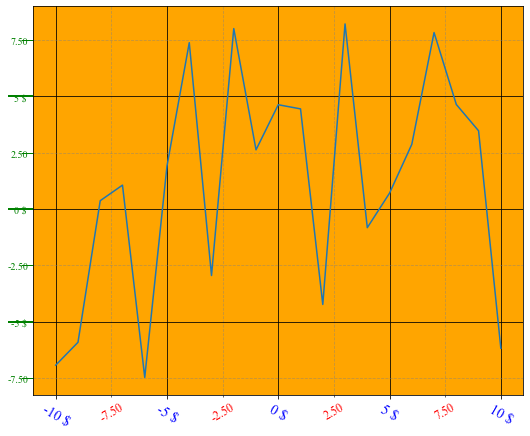

In [ ]:
majorLocator   = MultipleLocator(5)
majorFormatter = FormatStrFormatter('%d $')

# FixedLocator позволяет задать последовательность подписей. 
# Если множество подписей имеет пересечения с множеством других подписей, то 
# они будут перекрываться (случай пересечения главных и вспомогательных делений)
minorLocator   = FixedLocator(np.arange(-7.5, 12.5, 5.))
print(type(minorLocator))
minorFormatter = FormatStrFormatter('%.2f')

N = 10
x = np.arange(-N, N+1, 1) 
y = (np.random.random(len(x))*2.-1)*N

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

ax.plot(x, y)

xax = ax.xaxis
yax = ax.yaxis

xax.set_major_locator(majorLocator)
xax.set_major_formatter(majorFormatter)
yax.set_major_locator(majorLocator)
yax.set_major_formatter(majorFormatter)

xax.set_minor_locator(minorLocator)
xax.set_minor_formatter(minorFormatter)
yax.set_minor_locator(minorLocator)
yax.set_minor_formatter(minorFormatter)

ax.grid(True, which='major', color='k', linestyle='solid')

ax.grid(True, which='minor', color='grey', linestyle='dashed', alpha=0.5)
#yax.grid(True, which='minor', color='grey', linestyle='dashed', alpha=0.5)

for label in xax.get_ticklabels(which='minor'):
    label.set_color('red')
    label.set_rotation(30)
    label.set_fontsize(12)

for label in xax.get_ticklabels(which='major'):
    label.set_color('blue')
    label.set_rotation(-30)
    label.set_fontsize(14)
    
for tick in yax.get_major_ticks():
    tick.label1.set_visible = True
    tick.label1.set_color('green')
    tick.label2.set_visible = True
    tick.label2.set_color('blue')
    # серые деления на оси ОY слева
    tick.tick1line.set_color('green')
    tick.tick1line.set_markeredgewidth(2)
    tick.tick1line.set_markersize(25)    

    tick.tick2line.set_color('blue')
    tick.tick2line.set_markeredgewidth(2)
    tick.tick2line.set_markersize(25)    

for tick in yax.get_minor_ticks():
    tick.label1.set_visible = True
    tick.label1.set_color('green')
    tick.label2.set_visible = True
    tick.label2.set_color('blue')
    # серые деления на оси ОY слева
    tick.tick1line.set_color('green')
    tick.tick1line.set_markeredgewidth(1)
    tick.tick1line.set_markersize(12)    

    tick.tick2line.set_color('blue')
    tick.tick2line.set_markeredgewidth(1)
    tick.tick2line.set_markersize(12)

# для вспомогательных for the minor ticks, use no labels; default NullFormatter

save('pic_9_2_2', fmt='png')
save('pic_9_2_2', fmt='pdf')

plt.show()


Также некоторые элементы форматирования делений и их подписей вынесены в настройки rcParams :

+ **xtick.color**='k' - цвет делений по оси абсцисс;

+ **xtick.direction**='in' - направление деления [] по оси абсцисс;

+ **xtick.labelsize**='medium' - размер подписи деления на оси абсцисс;

+ **xtick.major.pad**=4.0 - расстояние от координатной оси для главных делений оси абсцисс;

+ **xtick.major.size**=4.0 - размер главного деления оси абсцисс;

+ **xtick.major.width**=0.5 - толщина главного деления оси абсцисс;

+ **xtick.minor.pad**=4.0 - расстояние от координатной оси для вспомогательных делений оси абсцисс;

+ **xtick.minor.size**=2.0 - размер вспомогательного деления;

+ **xtick.minor.width**=0.5 - толщина вспомогательного деления;

+ **ytick.color**='k' - цвет делений по оси ординат;

+ **ytick.direction**='in' - направление деления [] по оси ординат;

+ **ytick.labelsize**='medium' - размер подписи деления на оси абсцисс;

+ **ytick.major.pad**=4.0 - расстояние от координатной оси для главных делений оси ординат;

+ **ytick.major.size**=4.0 - размер главного деления оси ординат;

+ **ytick.major.width**=0.5 - толщина главного деления оси ординат;

+ **ytick.minor.pad**=4.0 - расстояние от координатной оси для вспомогательных делений оси ординат;

+ **ytick.minor.size**=2.0 - размер главного деления оси ординат;

+ **ytick.minor.width**=0.5 - толщина главного деления оси ординат.

## 10. Особенности координатных осей

**Деления (ticks)** неотделимы от координатной оси на которой они находятся. Однако свойства самих делений (цвет, длина, толщина и др.), и их подписей (кегль, поворот, цвет шрифта, шрифт и др.), а также связанные с ними линии вспомогательной сетки grid, удобно хранить в отдельном хранилище-контейнере Ticks, а не в контейнере Axis. Повторюсь, что эти вещи очень связаны и одно в отрыве от другого теряет смысл. Тем более, что для удобства пользователей разработчики сделали множество методов для работы с делениями из контейнеров более высокого уровня (Axes, Axis). 

### 10.1 Дополнительная координатная ось

Иногда требуется нанести на один рисунок две величины, имеющие общие единицы измерения по одной оси, но разные по другой. Например, это могут быть временные ряды сильно отличающихся по масштабу величин. Или ряды величин, имеющих разные единицы измерения. В таких случаях удобно нарисовать дополнительную координатную ось (обычно - ординат). 

Такую возможность обеспечивает метод **ax.twinx()** для оси OX и метод **ax.twiny()** для оси OY. В результате создаётся ещё одна область рисования, совпадающая по размерам с исходной. На каждой области рисуются соответствюущие значения, при этом с помощью пользовательской настройки подписей осей ординат можно добиться, чтобы вспомогательные сетки grid обеих областей совпадали.

Результат работы метода twinx <class 'matplotlib.axes._subplots.AxesSubplot'>


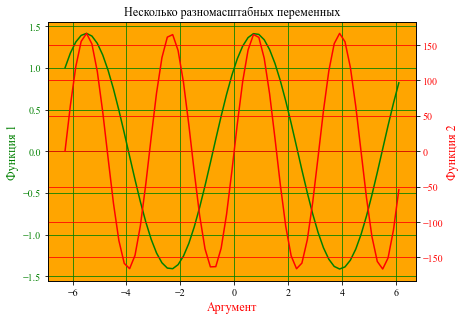

In [ ]:
x = np.arange(-2*np.pi, 2*np.pi, 0.2)
y = np.sin(x) * np.cos(x)
f = np.sin(x) + np.cos(x)

fig = plt.figure()
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx() # Создаём вторую область рисования ax2
print ('Результат работы метода twinx %s' % type(ax2))

ax1.plot(x, f, label = u'Сумма cos и sin', color='green')
ax1.set_xlabel(u'Аргумент')
ax1.set_ylabel(u'Функция 1', color='green')
ax1.grid(True, color='green')
ax1.tick_params(axis='y', which='major', labelcolor='green')

ax2.plot(x, y*333, label = u'Произведение cos и sin', color='red')
ax2.set_ylabel(u'Функция 2', color='red')
ax2.grid(True, color='red')
ax2.tick_params(axis='y', which='major', labelcolor='red')

ax1.set_title(u'Несколько разномасштабных переменных')

save('pic_10_1', fmt='png')
save('pic_10_1', fmt='pdf')

plt.show()

### 10.2 Работа с легендой дополнительной оси

Если график, где присутствует дополнительная координатная ось, выполнен в чёрно-белом варианте, понять какой график относится к левой шкале, а какой к правой невозможно. В таком случае необходимо использовать легенду для идентификации данных. При работе с легендой такого графика есть свои нюансы.

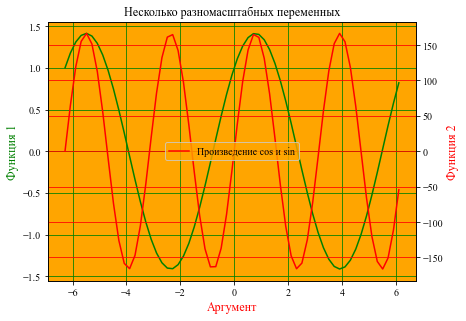

In [ ]:
x = np.arange(-2*np.pi, 2*np.pi, 0.2)
y = np.sin(x) * np.cos(x)
f = np.sin(x) + np.cos(x)

fig = plt.figure()
# Явно задаём область рисования в виде четырёхуголника
ax1 = fig.add_subplot(111) 
ax2 = ax1.twinx() # Создаём вторую шкалу ax2

ax1.plot(x, f, label = u'Сумма cos и sin', color='green')
ax1.set_xlabel(u'Аргумент')
ax1.set_ylabel(u'Функция 1', color='green')
ax1.grid(True, color='green')

ax2.plot(x, y*333, label = u'Произведение cos и sin', color='red')
ax2.set_ylabel(u'Функция 2', color='red')
ax2.grid(True, color='red')
#ax2.legend()

ax1.set_title(u'Несколько разномасштабных переменных')

# Легенда для всего рисунка fig
plt.legend()

save('pic_10_2_1', fmt='png')
save('pic_10_2_1', fmt='pdf')

plt.show()

Несмотря на то, что было указано нарисовать легенду ко всему рисунку, отобразилась легенда только для одной координатной оси из двух!

На самом деле обе подписи легенды отобразились верно, но более новая легенда перезатёрла предыдущую. Потери можно избежать, если указать другое место расположения. Чтобы каждая подпись была в своём месте, нужно воспользоваться методом `ax.legend()`, а не `plt.legend()`.

Расположение легенды задаётся параметром loc метода legend(), который принимает значения в виде цифр (1-9), начиная от верхнего левого угла и заканчивая нижним правым, и в виде условных обозначений. Значение loc='best' автоматически выберет место на рисунке, где легенда меньше всего будет "портить" график. Также можно убрать рамку вокруг легенды для визуального уменьшения места (frameon=False), занимаемого легендой, снижая тем самым геометрическое давление рисунка в целом.

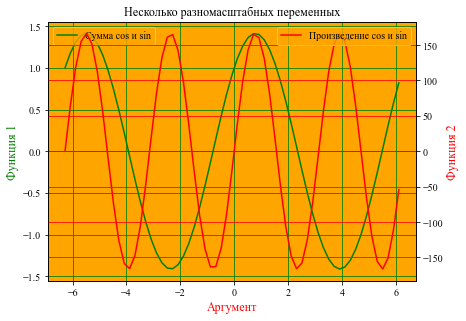

In [ ]:
x = np.arange(-2*np.pi, 2*np.pi, 0.2)
y = np.sin(x) * np.cos(x)
f = np.sin(x) + np.cos(x)

fig = plt.figure()
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx() # Создаём вторую шкалу ax2

ax1.plot(x, f, label = u'Сумма cos и sin', color='green')
ax1.set_xlabel(u'Аргумент')
ax1.set_ylabel(u'Функция 1', color='green')
ax1.grid(True, color='green')
ax1.legend(loc=2) 

ax2.plot(x, y*333, label = u'Произведение cos и sin', color='red')
ax2.set_ylabel(u'Функция 2', color='red')
ax2.grid(True, color='red')
ax2.legend(loc=1)

plt.title(u'Несколько разномасштабных переменных')

save('pic_10_2_2', fmt='png')
save('pic_10_2_2', fmt='pdf')

plt.show()

### 10.3 Единая легенда

Если есть необходимость объединить обе легенды, сделав её единой, то можно пойти на следующую хитрость:

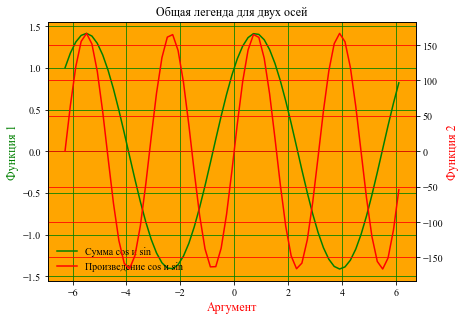

In [ ]:
x = np.arange(-2*np.pi, 2*np.pi, 0.2)
y = np.sin(x) * np.cos(x)
f = np.sin(x) + np.cos(x)

fig = plt.figure()
ax1 = fig.add_subplot(111)
line1 = ax1.plot(x, f, label = u'Сумма cos и sin', color='green')
ax1.set_xlabel(u'Аргумент')
ax1.set_ylabel(u'Функция 1', color='green')
ax1.grid(True, color='green')

ax2 = ax1.twinx() # Создаём вторую шкалу ax2
line2 = ax2.plot(x, y*333, label = u'Произведение cos и sin', color='red')
ax2.set_ylabel(u'Функция 2', color='red')
ax2.grid(True, color='red')

lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=3, frameon=False)

plt.title(u'Общая легенда для двух осей')

save('pic_10_3', fmt='png')
save('pic_10_3', fmt='pdf')

plt.show()

### 10.4 Графики с логарифмическими координатными осями

Иногда очень удобно использовать не стандартную равномерную шкалу на координатных осях, а логарифмическую. 

Сделать шкалу координатной оси логарифмической позволяют методы `plt.xscale('log')/plt.yscale('log')` или для областей рисования - `ax.set_xscale('log')/ax.set_yscale('log')`.

> Из определения натурального логарифма и экспоненты вытекает следующий факт: если ось ординат имеет логарифмическую шкалу, то график функции, которая равна экспоненте от аргумента, будет выглядеть как прямая линия.

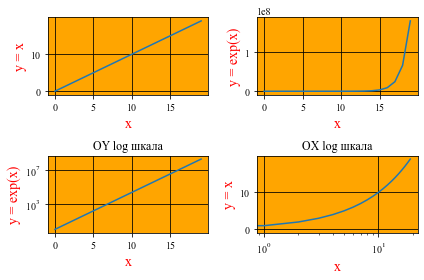

In [ ]:
x = np.arange(20)
y = np.exp(x)

fig = plt.figure()

# 1 x и y=x
ax = fig.add_subplot(221)
ax.plot(x, x)
ax.grid(True)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y = x', fontsize=14)

# 2 x и y=exp(x) 
ax = fig.add_subplot(222)
ax.plot(x, y)
ax.grid(True)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y = exp(x)', fontsize=14)

# 3 x и y=exp(x). OY с log шкалой
ax = fig.add_subplot(223)
ax.set_yscale('log')    # log здесь - натуральный логарифм!
# для работы с типом axis -> ax.set_yscale('log') 
ax.plot(x, y)
ax.grid(True)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y = exp(x)', fontsize=14)
ax.set_title(u'OY log шкала', loc='center')

# 4  x и y=x. OX с log шкалой
ax = fig.add_subplot(224)
ax.set_xscale('log')    # log здесь - натуральный логарифм!
ax.plot(x, x)
ax.grid(True)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y = x', fontsize=14)
ax.set_title(u'OX log шкала', loc='center')

# Автоматическое форматирование риснука
plt.tight_layout() 

save('pic_10_4_1', fmt='png')
save('pic_10_4_1', fmt='pdf')

plt.show()

Для того, чтобы выразить обе координатные оси в логарифмических шкалах, существует метод `plt.loglog()` или `ax.loglog()`.

## 11. Графики в полярной системе координат

По умолчанию двумерные графики имеют прямоугольную декартову систему координат. В некоторых задачах намного нагляднее отображать информацию на круге, а не в прямоугольнике. Например, при отображении розы ветров. Переход от прямоугольной формы основы рисунка к кругу позволяет нагляднее отобразить графики, заданные в полярной системе координат (polar plots).

### 11.1 Полярная система координат

Так как polar plots используют полярную систему координат, кратко вспомним что это такое и как она связана с декартовой (прямоугольной) системой координат.

В декартовой системе координат, которая используется по умолчанию, положение точки определяется двумя значениями: аргументом x и значением функции y. 

В полярной системе координат положение точки также определяется двумя значениями: радиусом r и углом phi. Угол обычно отсчитывают против часовой стрелке от "восточного" (3:00) направления.

Переход из полярной системы координат в прямоугольную выглядит так:

`x = r*cos(phi)`

`y = r*sin(phi)`

Переход из декартовой в полярную систему координат осуществляется [чуть сложнее](https://en.wikipedia.org/wiki/Polar_coordinate_system).

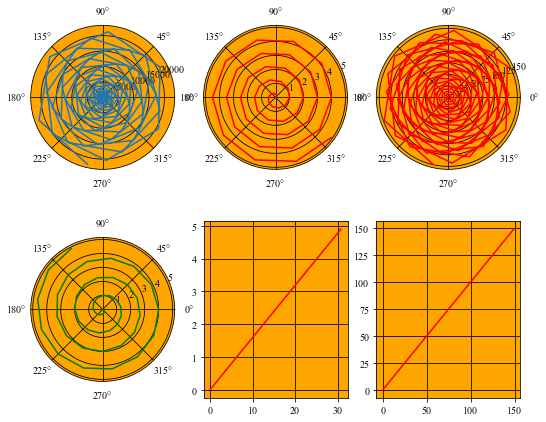

In [ ]:
fig = plt.figure(figsize=(8., 6.))
x = np.arange(150)
y = x**2 + 2.5

lag = 0.05*np.pi
r = np.arange(0.0, 5.0, 0.1)
phi = r*np.pi #np.arange(-2*np.pi, 2*np.pi + lag, lag)

# x и y
ax1 = fig.add_subplot(231, projection='polar')
ax1.plot(x, y)
ax1.grid(True)

ax2 = fig.add_subplot(232, projection='polar')
ax2.plot(phi*2., r, 'red')
ax2.grid(True)

ax3 = fig.add_subplot(233, projection='polar')
ax3.plot(x, x, 'r')
ax3.grid(True)

ax4 = fig.add_subplot(234, projection='polar')
ax4.plot(-1.5*phi, r, 'g')
ax4.grid(True)

ax5 = fig.add_subplot(235)
ax5.plot(phi*2., r, 'red')
ax5.grid(True)

ax6 = fig.add_subplot(236)
ax6.plot(x, x, 'r')
ax6.grid(True)

save('pic_11_1_1', fmt='png')
save('pic_11_1_1', fmt='pdf')

plt.show()

Вообще говоря matplotlib позволяет рисовать не только в полярной системе координат, но и в других. За это отвечает параметр projection, который в случае равенства значению 'polar' аналогичен значению параметра polar=True. В matplotlib поддерживаются следующие проекции: 'aitoff', 'hammer', 'lambert', 'mollweide', 'polar', 'rectilinear'. Чаще всего используются два последних варианта, остальные являются экзотическими для рутинных задач в научной графике.

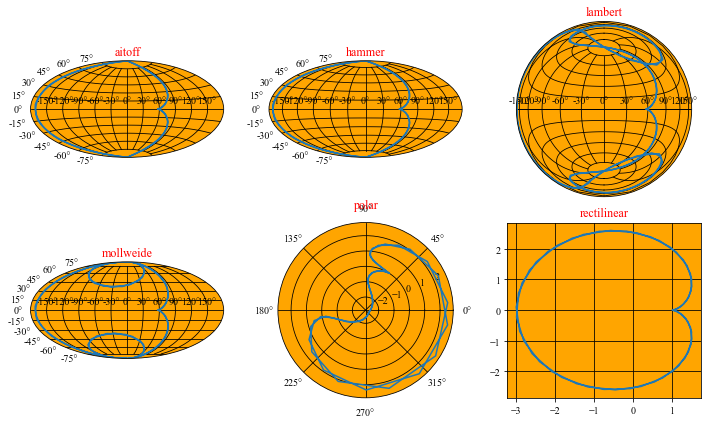

In [ ]:
a = 1.
x = np.arange(-2*np.pi, 2*np.pi, 0.2)
y = np.sin(x) * np.cos(x)
# Уравнение кардиойды
xz = a*(2*np.cos(x) - np.cos(2*x))
yz = a*(2*np.sin(x) - np.sin(2*x))

label = ['aitoff', 'hammer', 'lambert', 'mollweide', 'polar', 'rectilinear']

fig = plt.figure(figsize=(10,6))

for i in range(len(label)):

    ax = fig.add_subplot(231+i, projection=label[i])
    ax.plot(xz, yz)
    ax.set_title(label[i], color='r')
    ax.grid(True)

plt.tight_layout()

save('pic_11_1_2', fmt='png')
save('pic_11_1_2', fmt='pdf')

plt.show()

### 11.2 Роза ветров

С помощью polar plots можно построить особый вид графиков - "розу ветров". 

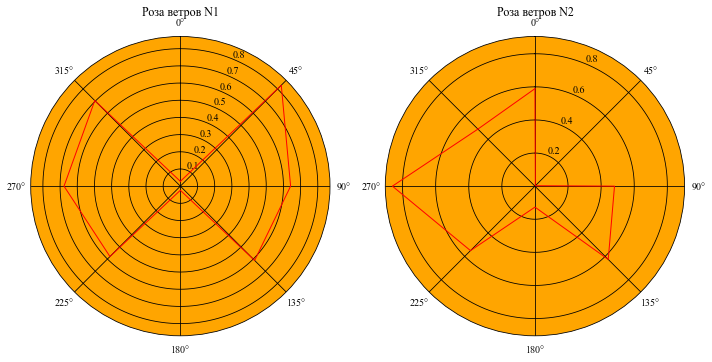

In [ ]:
from math import pi

lag = pi/4.
angles = np.arange(0, 2*pi , lag)

fig = plt.figure(figsize=(10,5)) # зададим явно размер полотна, чтобы графики не перекрывались

for i in range(1, 3):

    r = np.random.random(len(angles)) # для каждой розы значения будут разные

    ax = fig.add_subplot(120+i, projection='polar')
    ax.plot(angles, r, color='r', linewidth=1.)
    # Так как 0 и 2*pi - это одна и та же точка, то значение в ней должно быть одно
    # Однако, будет разрыв между последней точкой и нулевой.
    # Чтобы его убрать, искусственно соединим эти точки.

    # Замыкаем розу ветров (соединяем конец с началом)
    ax.plot((angles[-1],angles[0]),(r[-1],r[0]), color='r', linewidth=1.)

    # Изменяем направление обхода с "против часовой" на "по часовой"
    ax.set_theta_direction(-1)
    
    # Смещаем нулевую или полярную ось на 90 градусов против часовой стрелки, в положение "север"
    ax.set_theta_offset(pi/2.0)

    ax.set_title(u"Роза ветров N%d" % i, loc='center')

plt.tight_layout()

save('pic_11_2', fmt='png')
save('pic_11_2', fmt='pdf')

plt.show()   

### 11.3 Настройка графика в полярных координат

Полярный график по сути ничем не отличается от привычного прямоугольного графика. Соответственно, практически все пользовательские настройки осуществляются аналогично.

old r: [0.2, 0.4, 0.6000000000000001, 0.8, 1.0, 1.2000000000000002]
old phi: [0.         0.78539816 1.57079633 2.35619449 3.14159265 3.92699082
 4.71238898 5.49778714]


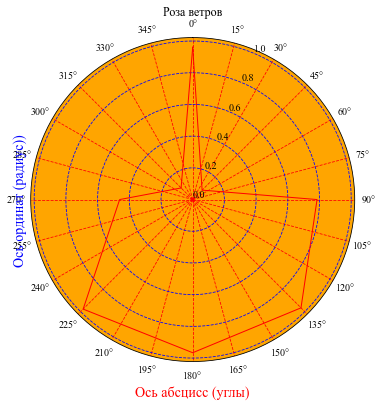

In [ ]:
lag = pi/4.
angles = np.arange(0, 2*pi , lag)

fig = plt.figure(figsize=(10,5)) # зададим явно размер полотна, чтобы графики не перекрывались

r = np.random.random(len(angles)) # для каждой розы значения будут разные

ax = fig.add_subplot(111, projection='polar')
ax.plot(angles, r, color='r', linewidth=1.)
# Так как 0 и 2*pi - это одна и та же точка, то значение в ней должно быть одно
# Однако, будет разрыв между последней точкой и нулевой.
# Чтобы его убрать, искусственно соединим эти точки.

# Замыкаем розу ветров (соединяем конец с началом)
ax.plot((angles[-1],angles[0]),(r[-1],r[0]), color='r', linewidth=1.)

# Изменяем направление обхода с "против часовой" на "по часовой"
ax.set_theta_direction(-1)

# Смещаем нулевую или полярную ось на 90 градусов против часовой стрелки, в положение "север"
ax.set_theta_offset(pi/2.0)

ax.set_title(u"Роза ветров", loc='center')

ax.set_xlabel(u'Ось абсцисс (углы)', fontsize=14, color='r')
ax.set_ylabel(u'Ось ординат (радиус))', fontsize=14, color='b')

old_rticks = ax.get_yticks()
old_phiticks = ax.get_xticks()

new_rticks = np.arange(0, 1.2, 0.2)
new_phiticks = np.arange(0, 2*np.pi, np.pi/12.)
ax.set_xticks(new_phiticks)
ax.set_yticks(new_rticks)

#ax.set_thetagrids(new_phiticks)

ax.grid(True, axis='y', color='blue', linestyle='--')
ax.grid(True, axis='x', color='red', linestyle='--')

print('old r:', old_rticks)
print('old phi:', old_phiticks)

save('pic_11_3_1', fmt='png')
save('pic_11_3_1', fmt='pdf')

plt.show()   

У полярной системы координат есть специальные функции, которые позволяют настраивать внешний вид рисунка.

Для радиуса R:

1. **`ax.set_rlabel_position(phi)`** - перемещает ось ординат (радиус) по кругу на угол phi (в ГРАДУСАХ) от положения нуля;

2. **`ax.set_rmax(R)`** - позволяет ограничить область изменения радиуса R на рисунке;

3. **`ax.set_rmin(R)`** - позволяет ограничить область изменения радиуса R на рисунке;

4. **`ax.set_rlim()`** - позволяет ограничить область изменения радиуса R на рисунке (BUGS -> см. Электронные ресурсы);

5. **`ax.set_rscale()`** - позволяет сделать шкалу радиусов логарифмической (BUGS -> см. Электронные ресурсы);

6. **`ax.set_rgrid()`** - позволяет настроить для оси радиуса вспомогательную сетку, положения делений, формат подписей к ним и т.д.

Для угла **phi** (в matplotlib он называется **theta**):

1. **`ax.set_theta_zero_location(loc)`** - перемещает положение нуля на определённое положение. Loc принимает значения 'N', 'NW', 'W', 'SW', 'S', 'SE', 'E' или 'NE'. По умолчанию положение нуля находится в положении "восток" или "3 часа";

2. **`ax.set_theta_offset(phi)`** - перемещает положение нуля на угол phi (в радианах) . По умолчанию положение нуля находится в положении "восток" или "3 часа";
   
3. **`ax.set_theta_direction(loc)`** - определяет направление обхода. Loc может быть либо -1 или по часовой стрелке и 1 или против часовой стрелки;

4. **`ax.set_thetagrids()`** - позволяет настроить для оси углов вспомогательную сетку, положения делений, формат подписей к ним и т.д.

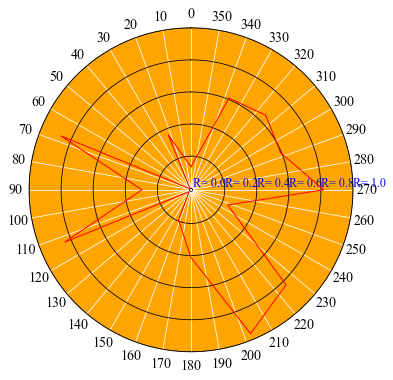

In [ ]:
lag = np.pi/8.
angles = np.arange(0, 2*np.pi , lag)

fig = plt.figure(figsize=(10,5)) # зададим явно размер полотна, чтобы графики не перекрывались

r = np.random.random(len(angles)) # для каждой розы значения будут разные

ax = fig.add_subplot(111, projection='polar')

ax.plot(angles, r, color='r', linewidth=1.)
ax.plot((angles[-1],angles[0]),(r[-1],r[0]), color='r', linewidth=1.)


# Изменяем направление обхода с "против часовой" на "по часовой"
ax.set_theta_direction(1)

# Помещаем положение нуля в положение "север"
ax.set_theta_zero_location('N')

# Перемещаем ось радиусов
ax.set_rlabel_position(270)

old_rticks = ax.get_yticks()
old_phiticks = ax.get_xticks()

# Ограничиваем радиус
#ax.set_rmin(0.0)
#ax.set_rmax(0.9)
ax.set_rlim(0.0, 0.9)

small_lag = 0.01
# метод set_rgrids требует строго положительного первого значения!
new_rticks = np.arange(0.0, 1.2, 0.2) + small_lag
new_phiticks = np.arange(0., 360., 10.)

ax.set_thetagrids(new_phiticks, labels=map(int, new_phiticks), fontsize=14, color='k')
ax.set_rgrids(new_rticks, fontsize=12, fmt='R= %.1f', color='b', rotation=90.)

ax.grid(True, axis='y', color='k', linestyle='-')
ax.grid(True, axis='x', color='w', linestyle='-')

save('pic_11_3_2', fmt='png')
save('pic_11_3_2', fmt='pdf')

plt.show()   

Настройка легенды у графика в полярных координат ничем не отличается от работы с легендой у графика в декартовых координатах.

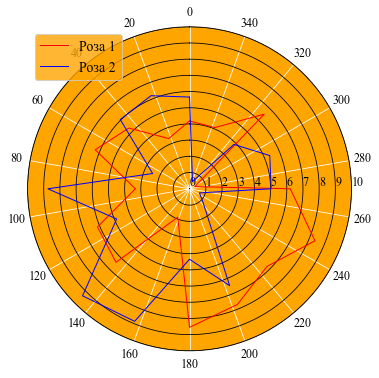

In [ ]:
lag = np.pi/8.
angles = np.arange(0, 2*np.pi , lag)

fig = plt.figure(figsize=(10,5)) # зададим явно размер полотна, чтобы графики не перекрывались

r = np.random.random(len(angles))*10.
r2 = np.random.random(len(angles))*10.
ax = fig.add_subplot(111, projection='polar')

ax.plot(angles, r, color='r', linewidth=1.)
ax.plot((angles[-1],angles[0]),(r[-1],r[0]), color='r', linewidth=1., label=u'Роза 1')

ax.plot(angles, r2, color='b', linewidth=1.)
ax.plot((angles[-1],angles[0]),(r2[-1],r2[0]), color='b', linewidth=1., label=u'Роза 2')


# Изменяем направление обхода с "против часовой" на "по часовой"
ax.set_theta_direction(1)

# Помещаем положение нуля в положение "север"
ax.set_theta_zero_location('N')

# Перемещаем ось радиусов
ax.set_rlabel_position(270)

old_rticks = ax.get_yticks()
old_phiticks = ax.get_xticks()

# Ограничиваем радиус
#ax.set_rmin(0.0)
#ax.set_rmax(0.9)
ax.set_rlim(0.0, 0.9)

# метод set_rgrids требует строго положительного первого значения!
small_lag = 0.01
new_rticks = np.arange(0, 11, 1) + small_lag
new_phiticks = np.arange(0., 360., 20.)

ax.set_thetagrids(new_phiticks, labels=map(int, new_phiticks), fontsize=12, color='k')
ax.set_rgrids(new_rticks, fontsize=12, fmt='%d', color='k')

ax.grid(True, axis='y', color='k', linestyle='-')
ax.grid(True, axis='x', color='w', linestyle='-')

ax.legend(ncol=1, loc=2, frameon=True, fontsize=14)

save('pic_11_3_3', fmt='png')
save('pic_11_3_3', fmt='pdf')

plt.show()

## 12. Легенда

Когда на рисунке изображено несколько графиков, возникает потребность в их идентификации. Определить, какая линия или диаграмма соответствует каким данным, помогает легенда.

Легенда - это ключ к пониманию сложного графика. Чтобы повысить читаемость рисунка, нужно стараться делать так, чтобы все использованные условные обозначения легко расшифровывались. Немаловажным аспектом этого является правильное размещение и представление легенды.

### 12.1 Легенда 

Создание легенды подразумевает два логических этапа. 

1. *Формирование подписей к условным обозначениям*;

2. *Отображение легенды на рисунке*.

Самый простой способ сформировать подписи к графическим элементам - использовать атрибут label в графических командах типа `plot()`, `scatter()` и др. Параметр label принимает текст в виде строки, который "привязывается" к породившему их графическому элементу (линия, маркер, диаграмма и т.д.). 

Отображение легенды осуществляется либо методом `plt.legend()` для всего рисунка,  либо `ax.legend()` для конкретной области рисования. Легенда цветовой палитры - цветовая шкала colorbar - рассматривается в следующей главе.

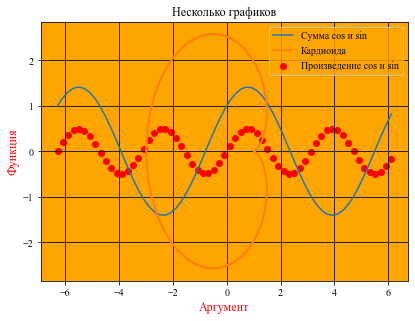

In [ ]:
a = 1
x = np.arange(-2*np.pi, 2*np.pi, 0.2)
y = np.sin(x) * np.cos(x)
f = np.sin(x) + np.cos(x)
xz = a*(2*np.cos(x) - np.cos(2*x))
yz = a*(2*np.sin(x) - np.sin(2*x))

# Способ 1 с помощью label
plt.plot(x, f, label = u'Сумма cos и sin')
plt.scatter(x, y, label = u'Произведение cos и sin', color='r')
plt.plot(xz, yz, label = u'Кардиоида')

plt.grid(True)
plt.xlabel(u'Аргумент')
plt.ylabel(u'Функция')
plt.title(u'Несколько графиков')

plt.legend()   # легенда для всего рисунка fig

save('pic_12_1_1', fmt='png')
save('pic_12_1_1', fmt='pdf')

plt.show()

При создании легенды методом `ax.legend()`, легенда будет отображаться на текущей области рисования `ax`.

<Figure size 432x288 with 0 Axes>

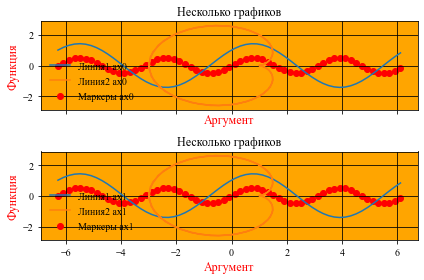

In [ ]:
a = 1
x = np.arange(-2*np.pi, 2*np.pi, 0.2)
y = np.sin(x) * np.cos(x)
f = np.sin(x) + np.cos(x)
xz = a*(2*np.cos(x) - np.cos(2*x))
yz = a*(2*np.sin(x) - np.sin(2*x))

fig = plt.figure()
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True)

for i,ax in enumerate(fig.axes):
    ax.plot(x, f, label = u'Линия1 ax%d' % i)
    ax.scatter(x, y, label = u'Маркеры ax%d' % i, color='r')
    ax.plot(xz, yz, label = u'Линия2 ax%d' % i)
    ax.grid(True)
    ax.set_xlabel(u'Аргумент')
    ax.set_ylabel(u'Функция')
    ax.set_title(u'Несколько графиков')
    ax.legend(loc='best', frameon=False)   # легенда для области рисования ax

plt.tight_layout()
    
save('pic_12_1_2', fmt='png')
save('pic_12_1_2', fmt='pdf')

plt.show()

Существует и другой способ создания (формирование подписей + отображение на рисунке) легенды.

Можно в самом методе `legend()` указать последовательность(список, кортеж), состоящую из подписей графических элементов. Здесь стоит сказать, что для создания корректной легенды этим методом, нужно знать последовательность появления графических объектов на рисунке. При этом стоит помнить о группировке типов графических объектов (линии к линиям, маркеры к маркерам, диаграммы к диаграммам и т.д.).

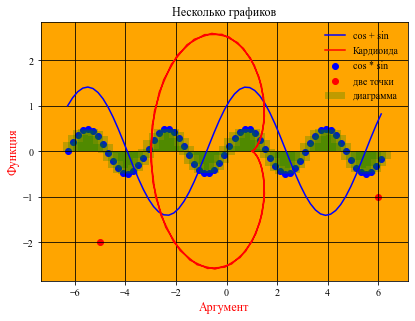

In [ ]:
rcParams['font.family'] = 'Times New Roman', 'Arial', 'Tahoma'
rcParams['font.fantasy'] = 'Times New Roman'

a = 1
x = np.arange(-2*np.pi, 2*np.pi, 0.2)
y = np.sin(x) * np.cos(x)
f = np.sin(x) + np.cos(x)
xz = a*(2*np.cos(x) - np.cos(2*x))
yz = a*(2*np.sin(x) - np.sin(2*x))

# Способ 2 с помощью label

plt.plot(x, f, 'b')
plt.scatter(x, y, color='b')
plt.bar(x, y, color='g', alpha=0.25)
plt.plot(xz, yz, 'r')
plt.scatter([-5.,6], [-2., -1], color='r')

plt.grid(True)
plt.xlabel(u'Аргумент')
plt.ylabel(u'Функция')
plt.title(u'Несколько графиков')

lab1 = u'cos + sin'
lab2 = u'cos * sin'
lab2_5 = u'диаграмма'
lab3 = u'Кардиоида'
lab4 = u'две точки'

plt.legend((lab1, lab3, lab2, lab4, lab2_5), frameon=False)

save('pic_12_1_3', fmt='png')
save('pic_12_1_3', fmt='pdf')

plt.show()

> Обратите внимание, что если легенда объединяет несколько типов графических элементов (`plot()`, `scatter()`, `bar()`), то они будут группироваться: сначала линии, потом маркеры, потом диаграммы. При использовании метода прямой передачи подписей для создания легенды следует быть особенно внимательным, так как иначе подписи могут быть приписаны не к тем графическим элементам.

Расположение легенды определяется параметром loc, который принимает значения в виде цифр (1-9), начиная от верхнего левого угла и заканчивая нижним правым, и в виде условных обозначений. Значение loc='best' автоматически выберет место на рисунке, где легенда меньше всего будет "портить" график. Также можно убрать рамку вокруг легенды для уменьшения места (frameon=False), занимаемого легендой, снижая тем самым геометрическое давление рисунка в целом.

### 12.2 Легенда на отдельной области рисования

Для мультиоконных рисунков или графиков с несколькими областями рисования, общая легенда может быть размещена как на одной из существующих областей рисования (см. главу "Особенности координатных осей"), так и на отдельной области рисования.

Обратите внимание, что новая область рисования для размещения легенды должна быть вписана в существующий рисунок figure. Это значит, что на рисунке необходимо выделить дополнительное место для легенды, помимо существующих на рисунке областей рисования типа subplots или axes ("мультиокна"). Изменить размеры объединённой области рисования для subplots и axes можно с помощью параметров rcParams:

+ `rcParams['figure.subplot.left'] = 0.125`

+ `rcParams['figure.subplot.right'] = 0.9`

+ `rcParams['figure.subplot.bottom'] = 0.125`

+ `rcParams['figure.subplot.top'] = 0.9`

+ `rcParams['figure.subplot.hspace'] = 0.2`

+ `rcParams['figure.subplot.wspace'] = 0.2`

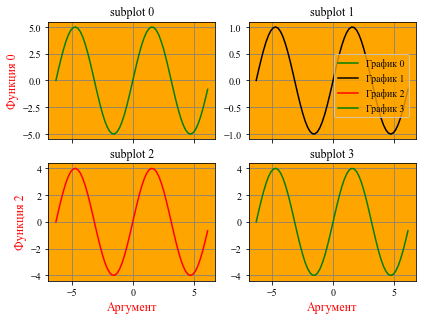

In [ ]:
x = np.arange(-2*np.pi, 2*np.pi, 0.2)

fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True)

# Обрати внимание!
rborder = 0.75
rcParams['figure.subplot.right'] = rborder
rcParams['figure.subplot.hspace'] = 0.15
rcParams['figure.subplot.wspace'] = 0.15

lns = []
for i, ax in enumerate(fig.axes):
    
    y = np.sin(x)*randint(1, 5)
    line = ax.plot(x, y, label = u'График %d' % i, color=choice(['r','b','k','g']))
    if i > 1:
        ax.set_xlabel(u'Аргумент')
    if i%2 == 0:
        ax.set_ylabel(u'Функция %d' % i)
    ax.grid(True, color='grey')
    ax.set_title(u'subplot %d' % i)
    lns = lns + line

ax2 = fig.add_axes([rborder, 0.6, 1.-rborder, 0.15], frameon=False)
labs = [l.get_label() for l in lns]
ax2.legend(lns, labs, loc=3, frameon=True)

# Скрываем координатные оси
ax2.set_axis_off()

save('pic_12_2_1', fmt='png')
save('pic_12_2_1', fmt='pdf')

plt.show()

В случае, скажем, столбчатых диаграмм (метод `bar()`), схема работы с легендой аналогичная.

Обратите внимание, что методы типа bar возвращают не графический примитив (плоская линия в случае метода `ax.plot()`), а контейнер, то есть "ящик", в котором хранятся графические примитивы. Поэтому нельзя использовать простое сложение объектов, как было показано в примере с линиями. Как вариант можно использовать метод списков `append()`.

0 Тип данных bar <class 'matplotlib.container.BarContainer'> <BarContainer object of 63 artists>
1 Тип данных bar <class 'matplotlib.container.BarContainer'> <BarContainer object of 63 artists>
2 Тип данных bar <class 'matplotlib.container.BarContainer'> <BarContainer object of 63 artists>
3 Тип данных bar <class 'matplotlib.container.BarContainer'> <BarContainer object of 63 artists>


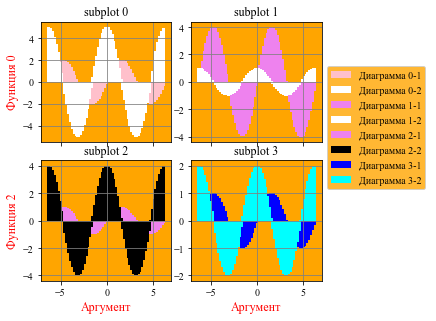

In [ ]:
x = np.arange(-2*np.pi, 2*np.pi, 0.2)

fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True)

# Обрати внимание!
rborder = 0.75
rcParams['figure.subplot.right'] = rborder
rcParams['figure.subplot.hspace'] = 0.15
rcParams['figure.subplot.wspace'] = 0.15

lns = []
for i, ax in enumerate(fig.axes):
    
    y = np.sin(x)*randint(1, 5)
    z = np.cos(x)*randint(1, 5)
    
    bar1 = ax.bar(x, y, width=0.4, label = u'Диаграмма %d-1' % i, color=choice(['r','b','pink','violet']))
    
    print ('%d Тип данных bar' % i, type(bar1), bar1)
    bar2 = ax.bar(x, z, width=0.4, label = u'Диаграмма %d-2' % i, color=choice(['k','g','w','cyan']))

    if i > 1:
        ax.set_xlabel(u'Аргумент')
    if i%2 == 0:
        ax.set_ylabel(u'Функция %d' % i)
    ax.grid(True, color='grey')
    ax.set_title(u'subplot %d' % i)

    # Сравни с предыдущим примером
    lns.append(bar1)
    lns.append(bar2)
    
ax2 = fig.add_axes([rborder, 0.35, 1.-rborder, 0.5], frameon=False)

labs = [l.get_label() for l in lns]
ax2.legend(lns, labs, loc=3, frameon=True)

# Скрываем координатные оси области рисования ax2
ax2.set_axis_off()

save('pic_12_2_2', fmt='png')
save('pic_12_2_2', fmt='pdf')

plt.show()

## 13. Цветовая шкала

**Цветовая шкала colorbar** - это аналог легенды для отображения трёхмерных полей, заданных обычно в виде матрицы или двумерного массива. Цветовая шкала является неотъемлемой частью рисунков, создаваемых с помощью методов ax.contour(), ax.contourf(), ax.imshow(), ax.pcolor(), ax.scatter().

Каждая цветовая шкала является по сути ещё одной областью рисования Axes. Это значит, что она имеет такие же методы и атрибуты, как и обычные экземпляры типа Axes или AxesSubplot. Имеются у неё и свои особенности.

### 13.1 Цветовая шкала `colorbar`

Цветовая шкала, которая связывает цвет и числовые значения, отображаемые на рисунке тем или иным графическим методом, является самостоятельным элементом на рисунке. Цветовая шкала может быть создана при условии, что на рисунке существует "mappable-object". К таким объектам относятся результаты выполнения графических команд `cs=ax.pcolor()`, `cs=ax.contourf()`, `cs=ax.imshow()` и др. 

Если условие на наличие "mappable" объекта на рисунке выполнено, то при использовании метода `plt.colorbar()` или `fig.colorbar()` на рисунке будет отображена цветовая шкала. 

Цветовая шкала может располагаться непросредственно на графике (привязывается к конкретной области рисования ax через атрибут "cax"), так и рядом с ним (привязывается через атрибут "ax"). И то и другое отрисовывается на текущей области рисования, однако в первом случае она именуется для цветовой шкалы как просто область рисования axes, а вторая - как родительская область рисования (parent axes). Обычно удобнее располагать цветовую шкалу вне графика или диаграммы, отдавая часть текущей области рисования под цветовую шкалу (см. атрибут fraction). Хотя это и не обязательно, лучше напрямую "привязать" цветовую шкалу к конкретной области рисования ax через атрибут colorbar "ax". По умолчанию, без указания данного атрибута, реализуется именно такой вариант для текущей области рисования, а если её нет, то создаётся новая. Если же необходимо отобразить цветовую шкалу на самом графике, то нужно воспользоваться атрибутом "cax". Оба атрибута принимают экземпляры Axes или AxesSubplot.

Метод `fig.colorbar()` имеет следующие параметры, определяющие внешний вид шкалы:

+ **ticks** [None | list of ticks | Locator object]- задаёт положение делений на шкале в виде последовательности или массива;

+ **extend** ['neither' | 'both' | 'min' | 'max'] - позволяет задать на концах шкалы значения "больше чем" и/или "меньше чем" в виде цветных треугольников. Цвета треугольников задаются методами cmap.set_over('цвет') и cmap.set_under('цвет') для текущей цветовой палитры cmap;

+ **extendfrac** [ None | 'auto' | length | lengths] - определяет размер треугольного интервала цветовой шкалы (будет показано на рисунке, если атрибут "extend" определён "положительно"). По умолчанию он определяется как 0.05 длины шкалы. Если 'auto', то длина треугольника равна длине остальных интервалов (при условии, если атрибут spacing='uniform') или пропорциональна доле данных, попадающих в данный интервал (если spacing='proportional'). Если задано число, то оно определяет длину обоих треугольников и для минимума и для максимума в виде доли длины цветовой шкалы. Можно задать два значения в виде списка - отдельно для минимума, отдельно для максимума;

+ **spacing** ['uniform' | 'proportional'] - uniform задаёт одинаковую длину для каждого отрезка шкалы; proportional определяет длину делений пропорционально долям данных, попадающих в градации шкалы;

+ **format** [ None | format string | Formatter object ] - задаёт формат для подписей значений цветовой шкалы;

+ **drawedges** [ False | True ] - если True, между интервалами будут нарисованы линии;

Также есть параметры, которые определяют размеры, положение colorbar на области рисования шкалы:

+ **orientation** ['vertical' | 'horizontal'] - определяет ориентацию цветовой шкалы (вертикальное или горизонтальное);

+ **fraction**=0.15 - доля площади родительской области рисования axes, на которой будет нарисована colorbar;

+ **pad** [0.05 для вертикального, 0.15 для горизонтального положения] - расстояние в долях от размеров исходной области рисования axes между цветовой шкалой и новым изображением области рисования;

+ **shrink**=1.0 - доля, на которую цветовая шкала будет сжата;

+ **aspect**=20 - соотношение во сколько раз длинная сторона шкалы больше короткой;

Обычно ссылку на результат метода `fig.colorbar()` передают в какую-либо переменную, например cbar. Это удобно для последующей настройки цветовой шкалы.

[0.05068754 1.46552964 2.88037173 4.29521383 5.71005593 7.12489803
 8.53974013 9.95458222]
Тип CS: <class 'matplotlib.collections.PolyCollection'>
Тип CBAR: <class 'matplotlib.colorbar.Colorbar'>


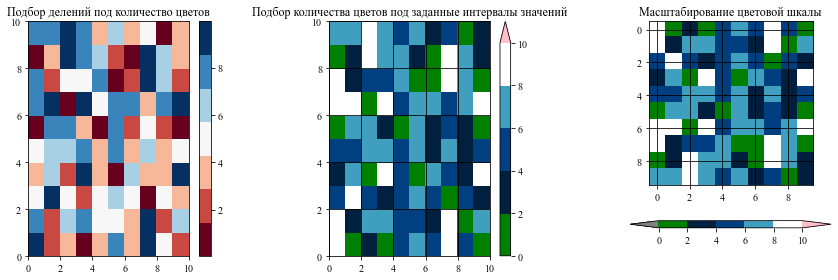

In [ ]:
a = np.random.random(100)*10.
a = a.reshape(10,10)

fig = plt.figure(figsize=(12,4))

N = 7
bounds = np.linspace(np.min(a), np.max(a), N+1)
print(bounds)
cmap = mpl.cm.get_cmap('RdBu', N) 

ax = fig.add_subplot(131)
cs = ax.pcolor(a, cmap=cmap) # вызываем метод pcolor. Вводим пользовательскую раскраску через cmap
print(u'Тип CS: %s' % type(cs))
cbar = fig.colorbar(cs, ax=ax) # рисуем шкалу colorbar для изображения cs. В качестве черточек шкалы указываем bounds. 
print(u'Тип CBAR: %s' % type(cbar))
# ticks=bounds
ax.set_title(u'Подбор делений под количество цветов')

# ---------------------------------------------------

ax2 = fig.add_subplot(132)
bounds = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0]
cmap = mpl.cm.get_cmap('ocean', len(bounds)-1)
cmap.set_over('red')
cmap.set_under('grey')
cs = ax2.pcolor(a, cmap=cmap, vmin=bounds[0], vmax=bounds[-1]) # Ставим границы для шкалы vmin и vmax.
cbar = fig.colorbar(cs, ax=ax2, ticks=bounds, extend='max', extendfrac=0.1)
ax2.set_title(u'Подбор количества цветов под заданные интервалы значений')
ax2.grid(True)
cmap.set_over('pink')

# ---------------------------------------------------

ax3 = fig.add_subplot(133)
cs = ax3.imshow(a, cmap=cmap,  vmin=bounds[0], vmax=bounds[-1]) # В методе pcolor/pcolormesh/imshow присваиваем пользовательские границы цветов norm
cbar = fig.colorbar(cs, ax=ax3, ticks=bounds, extend='both', extendfrac='auto',
                    orientation='horizontal')
ax3.set_title(u'Масштабирование цветовой шкалы')
ax3.grid(True)

plt.tight_layout()

save('pic_13_1', fmt='png')
save('pic_13_1', fmt='pdf')

plt.show()

### 13.2 Подпись цветовой шкалы

Подпись к шкале осуществляется методом `cbar.set_label()`. Однако, мы помним, что цветовая шкала - это особая область рисования, а значит ей доступны и другие методы для создания подписей.

Положение делений на цветовой шкале subplot 1
[0.04740098 1.45269928 2.85799758 4.26329588 5.66859417 7.07389247
 8.47919077 9.88448907]


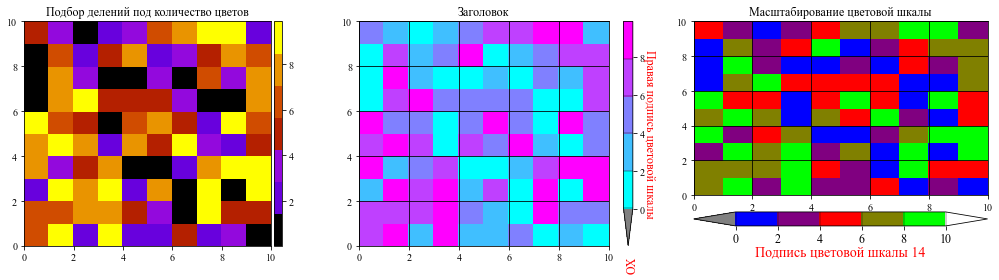

In [ ]:
a = np.random.random(100)*10.
a = a.reshape(10,10)

fig = plt.figure(figsize=(14,4))

N = 7
bounds = np.linspace(np.min(a), np.max(a), N+1)
print(u'Положение делений на цветовой шкале subplot 1')
print(bounds)
cmap = mpl.cm.get_cmap('gnuplot', N) 

ax = fig.add_subplot(131)

# вызываем метод pcolor. Вводим пользовательскую раскраску через cmap
cs = ax.pcolor(a, cmap=cmap, vmin=bounds[0], vmax=bounds[-1])
cbar = fig.colorbar(cs, ax=ax, pad=0.01, aspect=30) # pad=0.01 приближает шкалу близко к графику
ax.set_title(u'Подбор делений под количество цветов')
# ---------------------------------------------------

bounds = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0]

ax2 = fig.add_subplot(132)
formatter2 = MultipleLocator(2)
cmap = mpl.cm.get_cmap('cool', len(bounds)-1)
cmap.set_over('red')
cmap.set_under('grey')
cs = ax2.pcolor(a, cmap=cmap) # Ставим границы для шкалы vmin и vmax.
cbar = fig.colorbar(cs, ax=ax2, ticks=formatter2, fraction=0.1, drawedges=True,
                    extend='min', extendfrac='auto')
# методы ax.set_xlabel() и ax.set_ylabel()
cbar.ax.set_ylabel(u'Правая подпись цветовой шкалы', rotation=270, labelpad=10)
cbar.ax.set_xlabel(u'OX', labelpad=10, rotation=90, position=(1.,0.))
ax2.set_title(u'Заголовок')
ax2.grid(True)


ax3 = fig.add_subplot(133)
cmap = mpl.cm.get_cmap('brg', len(bounds)-1)
cmap.set_over('white')
cmap.set_under('grey')
cs = ax3.pcolor(a, cmap=cmap,  vmin=bounds[0], vmax=bounds[-1]) # В методе pcolor/pcolormesh/imshow присваиваем пользовательские границы цветов norm
cbar = fig.colorbar(cs, ax=ax3, ticks=bounds, extend='both', extendfrac='auto', pad=0.075,
                    orientation='horizontal', drawedges=True, aspect=15)

ax3.set_title(u'Масштабирование цветовой шкалы')
cbar.set_label(u'Подпись цветовой шкалы 14', fontsize=14, labelpad=0)
cbar.ax.tick_params(labelsize=12)

ax3.grid(True)

plt.tight_layout()

save('pic_13_2', fmt='png')
save('pic_13_2', fmt='pdf')

plt.show()

### 13.3 Положение цветовой шкалы на области рисования

Метод `fig.colorbar()` принимает три необязательных параметра:

+ **`mapable`** - собственно объект, с которым связана цветовая шкала;

+ **`ax`** - родительская область рисования (экземпляр Axes или AxesSubplot), из пространства которой будет выделяться место для расположения цветовой шкалы. Шкала будет создана вне графика-диаграммы.

+ **`cax`** - область рисования в которой будет нарисована цветовая шкала. Шкала будет создана "на графике".

Собственно, третий параметр "cax" позволяет рисовать цветовую шкалу в любом месте соответствующей области рисования. Стоит отметить, что cax в качестве входящих данных берёт экземпляр axes. Чтобы расположить цветовую шкалу в заданной области рисунка, необходимо знать границы соответствующей области рисования ax. Иначе цветовая шкала скорее всего перекроет область, где отображается график или диаграмма. Границы текущей области рисования ax можно узнать при выводе на экран экземпляра axes (print ax). Для автоматизации можно использовать следующий приём:

> `bbox = ax.get_position()`;

> `rect = bbox.bounds`

Здесь rect - это кортеж границ соответсвтующей области рисования ax ([левая граница, нижняя граница, ширина, высота]). Отступив от неё какое-то фиксированное расстояние (в долях от всей ширины-высоты), можно автоматизированно рисовать в нужном месте цветовую шкалу colorbar. Такой метод прямого размещения плохо работает с методом `plt.tight_layout()`, но при тонкой настройке он вряд ли потребуется.

Положение делений на цветовой шкале subplot 1
[0.34030854 1.7194319  3.09855527 4.47767863 5.856802   7.23592536
 8.61504873 9.99417209]
Область рисования ax имеет следующие границы
AxesSubplot(0.1,0.05;0.302326x0.9)
Rect: [0.4476744186046512, 0.99, 0.30232558139534893, 0.025]


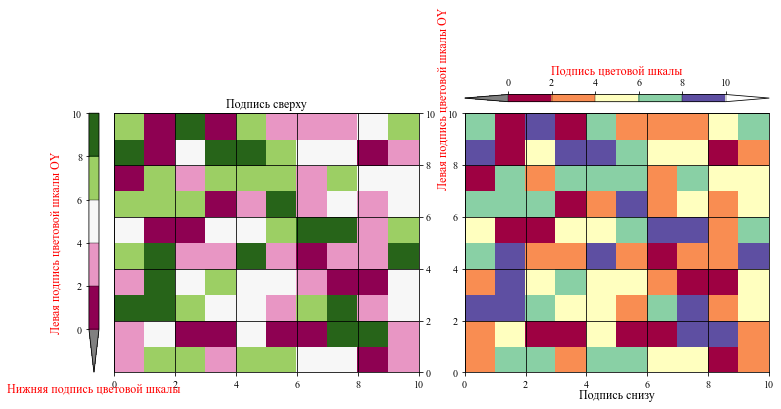

In [ ]:
a = np.random.random(100)*10.
a = a.reshape(10,10)

fig = plt.figure(1,(14,4))

N = 7
bounds = np.linspace(np.min(a), np.max(a), N+1)
print(u'Положение делений на цветовой шкале subplot 1')
print(bounds)
cmap = mpl.cm.get_cmap('gnuplot', N) 

# ---------------------------------------------------

ax2 = fig.add_subplot(121)
print(u'Область рисования ax имеет следующие границы')
print(ax2)
bbox = ax2.get_position()
rect = list(bbox.bounds)
#rect[0] = rect[0]
rect[0] = rect[0] - 0.025
rect[2] = 0.01
cax = fig.add_axes(rect) 

bounds = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0]
cmap = mpl.cm.get_cmap('PiYG', len(bounds)-1)
cmap.set_over('red')
cmap.set_under('grey')
cs = ax2.pcolor(a, cmap=cmap, vmin=bounds[0], vmax=bounds[-1]) # Ставим границы для шкалы vmin и vmax.
cbar = fig.colorbar(cs, cax=cax, ax=ax2, ticks=bounds, drawedges=True,
                    extend='min', extendfrac='auto')
cbar.ax.set_ylabel(u'Левая подпись цветовой шкалы OY', rotation=90, labelpad=10)
cbar.ax.set_xlabel(u'Нижняя подпись цветовой шкалы', labelpad=10)

ax2.yaxis.set_ticks_position('right')
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.xaxis.set_label_position('bottom')
ax2.set_title(u'Подпись сверху')
ax2.grid(True)

cmap = mpl.cm.get_cmap('Spectral', len(bounds)-1)
cmap.set_over('white')
cmap.set_under('grey')

# ---------------------------------------------------

ax3 = fig.add_subplot(122)
bbox = ax3.get_position()
rect = list(bbox.bounds)
rect[1] = rect[1] + rect[3] + 0.04
rect[3] = 0.025
print('Rect:', rect)
cax = fig.add_axes(rect)
cs = ax3.pcolor(a, cmap=cmap,  vmin=bounds[0], vmax=bounds[-1]) # В методе pcolor/pcolormesh/imshow присваиваем пользовательские границы цветов norm
cbar = fig.colorbar(cs, ax=ax3, cax=cax, ticks=bounds, extend='both', extendfrac='auto',
                    orientation='horizontal', drawedges=True)

ax3.xaxis.set_label_position('bottom')
ax3.set_title(u'Подпись снизу', position=(0.5, -0.125))
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.set_ylabel(u'Левая подпись цветовой шкалы OY', rotation=90, labelpad=15)
cbar.ax.set_xlabel(u'Подпись цветовой шкалы')

ax3.grid(True)

save('pic_13_3', fmt='png')
save('pic_13_3', fmt='pdf')

plt.show()

### 13.4 Деления цветовой шкалы

Как и для других axes объектов с цветовой шкалой можно работать через методы "set-get". Так как для работы с делениями colorbar доступны методы, аналогичные для axes и axis, то можно управлять положением делений и их подписями на шкале разными методами. 

> Здесь `cbar=fig.colorbar(cs, cax=cax, ax=ax)`

Например, так:

+ `cbar.ax.set_ylabel()`

+ `cbar.ax.set_yticklabels()`

+ `cbar.ax.set_yticks()`

Или воспользоваться методами xaxis/yaxis:

+ `cbar.ax.yaxis.set_ticks_position()`

+ `cbar.ax.yaxis.set_label_position()`

+ `cbar.ax.xaxis.set_ticks_position()`

+ `cbar.ax.xaxis.set_label_position()`

С помощью локатеров и форматтеров:

+ `cbar.ax.xaxis.set_major_locator()`

+ `cbar.ax.xaxis.set_major_formatter()`

+ `cbar.ax.xaxis.set_minor_locator()`

+ `cbar.ax.xaxis.set_minor_formatter()`

+ `cbar.ax.xaxis.set_major_locator()`

+ `cbar.ax.xaxis.set_major_formatter()`

+ `cbar.ax.xaxis.set_minor_locator()`

+ `cbar.ax.xaxis.set_minor_formatter()`

AxesSubplot(0.1,0.05;0.302326x0.9)
Subplot 1 bounds: [ 0.          1.42857143  2.85714286  4.28571429  5.71428571  7.14285714
  8.57142857 10.        ]
new_yticks [ 0.07142857  1.5         2.92857143  4.35714286  5.78571429  7.21428571
  8.64285714 10.07142857] 8


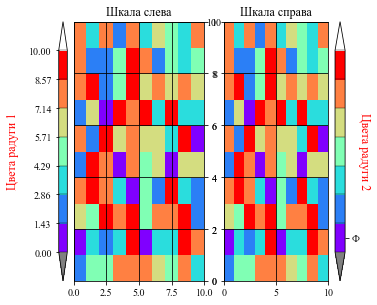

In [ ]:
a = np.random.random(100)*10.
a = a.reshape(10,10)

fig = plt.figure()

# ------------------------------------------------------

ax2 = fig.add_subplot(121)
print( ax2)
bbox = ax2.get_position()
rect = list(bbox.bounds)
rect[0] = rect[0] - 0.035
rect[2] = 0.02
cax = fig.add_axes(rect) 

N = 7
bounds = np.linspace(0., 10., N+1)
print( 'Subplot 1 bounds:', bounds)

cmap = mpl.cm.get_cmap('rainbow', len(bounds)-1)
cmap.set_over('white')
cmap.set_under('grey')

cs = ax2.pcolor(a, cmap=cmap, vmin=bounds[0], vmax=bounds[-1]) # Ставим границы для шкалы vmin и vmax.
cbar = fig.colorbar(cs, cax=cax, ax=ax2, ticks=bounds, drawedges=True,
                    extend='both', extendfrac='auto')
cbar.ax.set_ylabel(u'Цвета радуги 1', rotation=90, labelpad=10)
ax2.yaxis.set_ticks_position('right')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

ax2.set_title(u'Шкала слева')
ax2.grid(True)

# ---------------------------------------------

ax1 = fig.add_subplot(122)

bounds = np.linspace(0., 10., N+1)
cmap = mpl.cm.get_cmap('rainbow', len(bounds)-1)
cmap.set_over('white')
cmap.set_under('grey')

cs = ax1.pcolor(a, cmap=cmap, vmin=bounds[0], vmax=bounds[-1]) # Ставим границы для шкалы vmin и vmax.
cbar = fig.colorbar(cs, ax=ax1, ticks=bounds, drawedges=True,
                    extend='both', extendfrac='auto')
cbar.ax.set_ylabel(u'Цвета радуги 2', rotation=270, labelpad=10)
cbar_yticks = cbar.ax.get_yticks()
new_yticks = cbar_yticks + (1./((len(bounds)-1)*2))
print ('new_yticks', new_yticks, len(new_yticks))

cbar.set_ticks(10.*new_yticks)
cbar.set_ticklabels([u'Ф', u'С', u'Г', u'З', u'Ж', u'О', u'К', u'Б']) 

ax1.set_title(u'Шкала справа')
ax1.grid(True)

save('pic_13_4', fmt='png')
save('pic_13_4', fmt='pdf')

plt.show()

### 13.5 Особенности в отображении цветовых шкал разными методами

Методы `pcolor`/`pcolormesh`, `imshow` и `contour`/`contourf` немного по-разному отображают цветовую шкалу. В методах `pcolor` и `imshow` по умолчанию отображается "плавная" шкала, переход от цвета к цвету в них постепенный, а в методах изолиний `contour`/`contourf`, наоборот, шкала дискретная с резким изменением цвета при переходе от одного интервала к другому.

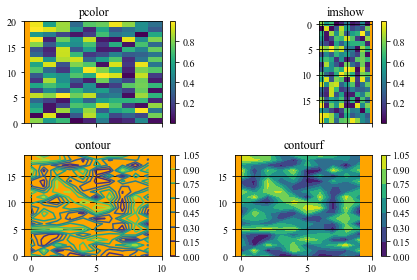

In [ ]:
def m_draw(i):
    '''
    В зависимости от целого i выбирается метод рисования 2D
    '''
    if(i == 0):
        md = ax.pcolor
    elif(i == 1):
        md = ax.imshow
    elif(i == 2):
        md = ax.contour
    elif(i == 3):
        md = ax.contourf
    else:
        md = ax.pcolor

    return md

dat = np.random.random(200).reshape(20,10) # создаём матрицу значений

fig, subs = plt.subplots(nrows=2, ncols=2, sharex=True)
titles = ['pcolor', 'imshow', 'contour', 'contourf']

for i, ax in enumerate(fig.axes):
    new_method = m_draw(i)
    cs = new_method(dat)
    fig.colorbar(cs, ax=ax)
    ax.set_title(titles[i])

plt.tight_layout()

save('pic_13_5', fmt='png')
save('pic_13_5', fmt='pdf')

plt.show()

### 13.6 Цветовая шкала в методе `pcolor()`

Покажем как можно задать количество цветов для шкалы, определить сами цвета и отобразить значения, которые выходят за установленные рамки для метода `pcolor` или `pcolormesh`.

xticks:  [ 0.  2.  4.  6.  8. 10.]
yticks:  [ 0.  2.  4.  6.  8. 10.]
cmap.N=  5


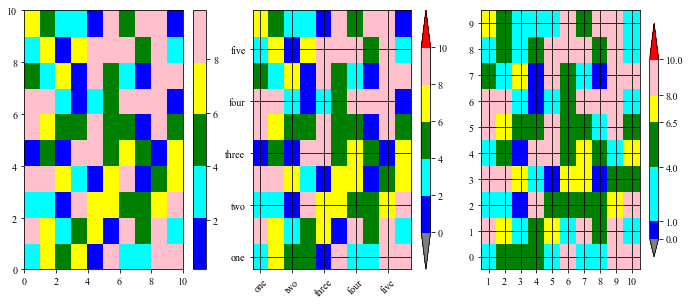

In [ ]:
a = np.random.random(100)
a = a*10.0
a = a.reshape(10,10)

fig = plt.figure(1,(14,4))


ax = fig.add_subplot(131)

bounds = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0] # список числовых границ. Длина N. Обратите внимание шаг регулярный.
cpool = ['blue','cyan','green','yellow','pink'] # список цветов, которые будут отображены между заданными границами bounds. Длина N-1
cmap = mpl.colors.ListedColormap(cpool, 'indexed') # Задаём дискретную шкалу цветов из списка cpool
cs = ax.pcolor(a, cmap=cmap) # вызываем метод pcolor. Вводим пользовательскую раскраску через cmap
cbar = fig.colorbar(cs, ticks=bounds) # рисуем шкалу colorbar для изображения cs. В качестве черточек шкалы указываем bounds. 

# ---------------------------------------------------

ax2 = fig.add_subplot(132)

bounds = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0] 
cpool = ['blue','cyan','green','yellow','pink'] 
cmap = mpl.colors.ListedColormap(cpool, 'indexed')

cmap.set_over('red') # задаём цвет для значений, выходящих за рамки границы bounds[-1] (сверху шкалы)
cmap.set_under('grey') # задаём цвет для значений, выходящих за рамки границы bounds[0] (снизу шкалы)

cs = ax2.pcolor(a, cmap=cmap, vmin=bounds[0], vmax=bounds[-1]) # Ставим границы для шкалы vmin и vmax.
cbar = fig.colorbar(cs, ticks=bounds, 
                    extend='both', extendfrac='auto') # Добавим треугольные индикаторы, которые отражают превышение 
#                                                       заданных vmin и vmax 
kx = ax2.get_xticks() # Передаём в kx значения черточек по оси OX xticks
print( 'xticks: ',kx)
xlabel = ['one','two','three','four','five','six'] # список подписей
ax2.set_xticks(kx+0.5) # Смещаем xticks, чтобы они были по центру "пикселей" метода pcolor
ax2.set_xticklabels(xlabel, rotation=45) # Подписываем пользовательскими значениями черточки оси OX и поворачиваем их на 45 градусов
ax2.set_xlim(bounds[0],bounds[-1]) # Ставим ограничения на область изменения оси OX (иначе будут белые полосы по краям)

# Аналогично для оси OY
ky = ax2.get_yticks()
print( 'yticks: ',ky)
ax2.set_yticks(ky+0.5)
ax2.set_ylim(bounds[0],bounds[-1])
ax2.set_yticklabels(xlabel)

# Рисуем вспомогательную сетку основных черточек xticks-yticks
ax2.grid(True)

'''
Область 3
'''

ax3 = fig.add_subplot(133)

bounds = [0.0, 1.0, 4.0, 6.5, 8.0, 10.0] # Обратите внимание шаг НЕрегулярный.
cpool = ['blue','cyan','green','yellow','pink'] # список цветов, которые будут отображены между заданными границами bounds. Длина N-1
cmap = mpl.colors.ListedColormap(cpool, 'indexed')
cmap.set_over('red')
cmap.set_under('grey') 
norm = mpl.colors.BoundaryNorm(bounds, cmap.N) # Ставим границы для цветовых отрезков шкалы
# cmap.N показывает число цветов-отрезков(прямоугольных)
print ('cmap.N= ',cmap.N)

cs = ax3.pcolor(a, cmap=cmap, norm=norm) # В методе pcolor/pcolormesh/imshow присваиваем пользовательские границы цветов norm
cbar = fig.colorbar(cs, ticks=bounds, 
                    extend='both', extendfrac='auto',
                    spacing ='proportional', shrink = 0.9) # Т.к. список bounds имеет неравномерный шаг, то ставим 
# spacing='proportional', а не 'uniform', то есть цветовые отрезки будут пропорциональны заданым bounds, а не одинаковыми.
# shrink позволяет пропорционально изменить шкалу от исходной величины: 0.9 уменьшит шкалу, а 1.2 - увеличит.

# В качестве подписей можно использовать любые значения. Пусть по оси OX это будут значения от 1 до 10
kx = np.arange(0,10) # 0 <=    kx  <= 9
xlabel = kx + 1      # 1 <= xlabel <= 10
ax3.set_xticks(kx+0.5)
ax3.set_xticklabels(xlabel)

# А по оси OY будут значения от 0 до 9, как более принято в Python =)
ax3.set_yticks(kx+0.5)
ax3.set_yticklabels(kx)
ax3.grid(True)

save('pic_13_6', fmt='png')
save('pic_13_6', fmt='pdf')

plt.show()

### 13.7 Цветовая шкала для метода `scatter()`

Нерегулярно расположённые в пространстве данные можно изобразить маркерами с помощью метода `scatter()` с добавлением цвета и/или размера в качестве третьей координаты. Значения поля нужно указать в качестве массива или списка параметру цвета маркеров "c" и/или параметру размера "s". Тип цветовой палитры задаётся параметром cmap (см. главу "Цвет").

Min y 0.0
Max y 21.3


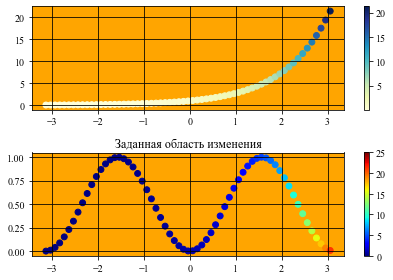

In [ ]:
fig = plt.figure()

x = np.arange(-np.pi, np.pi, 0.1)
y = np.exp(x)
z = np.sin(x)**2

ax1 = fig.add_subplot(211)
cmap = plt.cm.get_cmap('YlGnBu')
sc = ax1.scatter(x, y, c=y, s=35, cmap=cmap)
plt.colorbar(sc, ax=ax1)
ax1.grid(True)

ax2 = fig.add_subplot(212)
cmap = plt.cm.get_cmap('jet')
sc = ax2.scatter(x, z, c=y, vmin=0., vmax=25., s=35, cmap=cmap)
fig.colorbar(sc, ax=ax2)
ax2.grid(True)
ax2.set_title(u'Заданная область изменения')
print ('Min y %.1f' % np.min(y))
print ('Max y %.1f' % np.max(y))

plt.tight_layout()

save('pic_13_7_1', fmt='png')
save('pic_13_7_1', fmt='pdf')

plt.show()

Min y 0.0
Max y 1.0


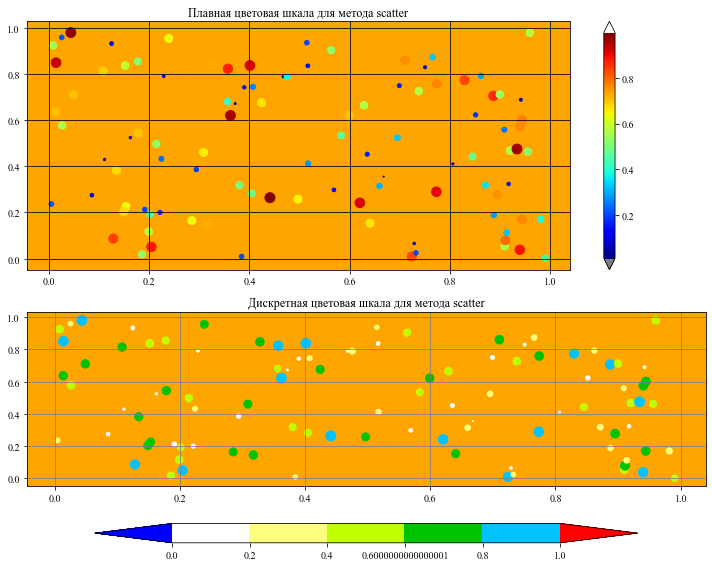

In [ ]:
fig = plt.figure(1, (10, 8))

N = 100
x, y = np.random.rand(2, N)
z = np.random.rand(N)

ax1 = fig.add_subplot(211)
cmap = plt.cm.get_cmap('jet')
cmap.set_over('w')
cmap.set_under('grey')

sc = ax1.scatter(x, y, c=z, s=z*100, cmap=cmap)
cbar = fig.colorbar(sc, ax=ax1, extend='both')
ax1.grid(True)
ax1.set_title(u'Плавная цветовая шкала для метода scatter')

ax2 = fig.add_subplot(212)

#cpool = ['cyan', 'green', 'yellow', 'orange', 'red']
cpool = ['#ffffff', '#ffff7f', '#c0ff00', '#00c300', '#00c3ff']
cmap = mpl.colors.ListedColormap(cpool, 'indexed')

cmap.set_over('r')
cmap.set_under('b')

ticks = np.linspace(0., 1., cmap.N + 1)
norm = mpl.colors.BoundaryNorm(ticks, cmap.N) 

sc = ax2.scatter(x, y, c=z, s=100*z, cmap=cmap, norm=norm)
cbar = fig.colorbar(sc, ax=ax2, ticks=ticks, norm=norm, extend='both',
                    extendfrac='auto', shrink=0.8,
                    orientation='horizontal')
cbar.set_ticks(ticks)
cbar.set_ticklabels(ticks)

ax2.set_title(u'Дискретная цветовая шкала для метода scatter')
ax2.grid(True, color='grey')
print ('Min y %.1f' % np.min(y))
print ('Max y %.1f' % np.max(y))

plt.tight_layout()

save('pic_13_7_2', fmt='png')
save('pic_13_7_2', fmt='pdf')

plt.show()

# Задание

Используя набор данных <a href='https://www.kaggle.com/unsdsn/world-happiness?select=2017.csv'>World Happiness Report 2017</a> визуализировать:
1. Топ-5 стран с наивысшими рейтингами по каждому континенту, расположив их на одном мультиокне;
2. График зависимости уровня свободы от уровня счастья, указав на графике отклонения при помощи box whisker chart;
3. Облако точек зависимости уровня "счастья" от уровня ВВП страны;
4. Распределение по столбцу Family для различных значений уровня "счастья";
5. Добавить в набор данных столбец с указанием экономического мира страны ("первый мир", "второй мир" и "третий мир") и визуализировать топ-5 стран с наивысшим рейтингом "счастья" для каждого из миров.
